# Testing file 

The purpose of this Jupyter Note Book file is to simply test all the functions that we propose in this project. 

## Testing opening.py

### Test the effective work

We recall that this file is made to open the specific type of excel file mentionned in README. Let's first try to import Test_1_pollen.xlsx. 

In [1]:
from opening import gen_data, extract

import pandas as pd
import numpy as np
import pathlib as Path

Let's see what type of Data Frame we obtain. Normally, it should contain : 
- 1st line : a series of numbers representing the layer depth
- Other lines : the 1st cell shoule be a name, the other ones numbers

In [2]:
data_1 =  extract("./excel/Test_1_pollen.xlsx")
print("The type of data_1 is : ", type(data_1))

The excel file treated by pandas is : 
                        0    1    2    3    4    5    6    7    8    9    10
0                      NaN    1    4    5    7    9   11   13   15   17   18
1                  _ABIES,    1    1    0    0    5    2    0    0    0    0
2                 _CEDRUS,    0    2    0    0    0    2    4    0    1    0
3              _JUNIPERUS,    1    4    1    4    5    4    0   10    2    4
4                  _PICEA,    1    1    0    1    0    0    0    0    0    0
5                  _PINUS,  118  190  152  239  198  255  167  169  149  208
6   _EPHEDRA DISTACHYA t.,    0    0    0    0    0    0    0    0    1    0
7    _EPHEDRA FRAGILIS t.,    0    1    0    0    2    0    0    0    0    0
8                  _ALNUS,    4    5    4    2    7    6    4   11    4    2
9                  _SALIX,    0    1    1    0    0    0    2    1    3    1
10               _TAMARIX,    0    1    1    0    0    1    0    0    0    0
11                _BETULA,    6    3 

In fact, we find the wanted structure as a pandas Data Frame. 

We can now extract correctly the data into : 
- a Numpy array : for layer depth
- a dictionnary : for pollen quantities


In [3]:
gen_data(data_1)

For the data Test_1, we obtain the following depth array :  [ 1.  4.  5.  7.  9. 11. 13. 15. 17. 18.]
It contains 10 layers.

The taxa studied in Test_1 are the following : ['_ABIES,' '_CEDRUS,' '_JUNIPERUS,' '_PICEA,' '_PINUS,'
 '_EPHEDRA DISTACHYA t.,' '_EPHEDRA FRAGILIS t.,' '_ALNUS,' '_SALIX,'
 '_TAMARIX,' '_BETULA,' '_OSTRYA,']

We obtain the following dictionnary for Test_1 data :  {'_ABIES,': array([1., 1., 0., 0., 5., 2., 0., 0., 0., 0.]), '_CEDRUS,': array([0., 2., 0., 0., 0., 2., 4., 0., 1., 0.]), '_JUNIPERUS,': array([ 1.,  4.,  1.,  4.,  5.,  4.,  0., 10.,  2.,  4.]), '_PICEA,': array([1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]), '_PINUS,': array([118., 190., 152., 239., 198., 255., 167., 169., 149., 208.]), '_EPHEDRA DISTACHYA t.,': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), '_EPHEDRA FRAGILIS t.,': array([0., 1., 0., 0., 2., 0., 0., 0., 0., 0.]), '_ALNUS,': array([ 4.,  5.,  4.,  2.,  7.,  6.,  4., 11.,  4.,  2.]), '_SALIX,': array([0., 1., 1., 0., 0., 0., 2., 1., 3., 

({'_ABIES,': array([1., 1., 0., 0., 5., 2., 0., 0., 0., 0.]),
  '_CEDRUS,': array([0., 2., 0., 0., 0., 2., 4., 0., 1., 0.]),
  '_JUNIPERUS,': array([ 1.,  4.,  1.,  4.,  5.,  4.,  0., 10.,  2.,  4.]),
  '_PICEA,': array([1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]),
  '_PINUS,': array([118., 190., 152., 239., 198., 255., 167., 169., 149., 208.]),
  '_EPHEDRA DISTACHYA t.,': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
  '_EPHEDRA FRAGILIS t.,': array([0., 1., 0., 0., 2., 0., 0., 0., 0., 0.]),
  '_ALNUS,': array([ 4.,  5.,  4.,  2.,  7.,  6.,  4., 11.,  4.,  2.]),
  '_SALIX,': array([0., 1., 1., 0., 0., 0., 2., 1., 3., 1.]),
  '_TAMARIX,': array([0., 1., 1., 0., 0., 1., 0., 0., 0., 0.]),
  '_BETULA,': array([6., 3., 5., 4., 2., 4., 1., 5., 2., 3.])},
 array([ 1.,  4.,  5.,  7.,  9., 11., 13., 15., 17., 18.]))

As wanted, we obtain the equivalent of our Excel file into a ordered dictionnary. To each taxa-key, we have a numpy array of the number of pollen found for each layer. 

### Test of the errors 

In each function, we integrated purposely raising errors to prevent some forms of wrong arguments and to avert 

- If we do not have an Excel file : 

In [4]:
data_1_error_txt = extract("./excel/Test_1_error.txt")

AssertionError: The extension do not seem to be the one of an Excel file

- If we have an Excel file but not structured as wanted : 

In [ ]:
data_1_error_xlsx = extract("./excel/Test_1_error.xlsx")

The excel file treated by pandas is : 
      0     1         2       3     4
0  This  file  contains  wrong   data
1     1     2         3       4     5
2     6     7         8       9    10
3    11    12        13      14    15



The extraction is correct but the data is not structured as wanted, so : 

In [ ]:
gen_data(data_1_error_xlsx)

ValueError: could not convert string to float: 'file'

In [ ]:
gen_data("./excel/Test_1_error.xlsx")

AssertionError: ./excel/Test_1_error.xlsx is not a Data Frame. Check gen_data argument.

## Testing pollinic.py

Now we want to test the good implementation of the pollinic diagrams. 

### Test the effective 

To proceed, we will first use a simple core where we found 2 taxa and composed of only 4 layers. 

In [5]:
from pollinic import percentage, single_pollinic_diag, general_pollinic_diag

import configparser

config = configparser.ConfigParser()
config.read("configuration.txt")

['configuration.txt']

We first can set up the configuration that we have defined 

In [6]:
PAGE_WIDTH = config.getfloat('page_settings', 'PAGE_WIDTH')
PAGE_HEIGHT = config.getfloat('page_settings', 'PAGE_HEIGHT')

MAX_GRAPH_WIDTH = config.getfloat('graph_settings', 'MAX_GRAPH_WIDTH')
MIN_GRAPH_WIDTH = config.getfloat('graph_settings', 'MIN_GRAPH_WIDTH')
MARGIN = config.getfloat('graph_settings', 'MARGIN')

configuration = np.array([PAGE_WIDTH, PAGE_HEIGHT, MAX_GRAPH_WIDTH, MIN_GRAPH_WIDTH, MARGIN])

In [7]:
data_simple = {'Taxa_1' : [1, 4, 5, 2],  'Taxa_2' : [6, 2, 5, 1]}
depth_simple = np.array([1, 3, 6, 8])

Let's first test the function percentage : we will check the good argument in the list. 

In [8]:
percent_data_simple = percentage(data_simple, depth_simple)
print(percent_data_simple)

{'Taxa_1': array([14.28571429, 66.66666667, 50.        , 66.66666667]), 'Taxa_2': array([85.71428571, 33.33333333, 50.        , 33.33333333])}


Let's check that the sum over each layer is correctly equal to 1. 

In [9]:
for i in range(len(percent_data_simple['Taxa_1'])): 
    total = 0 
    for key in data_simple:
        total += data_simple[key][i] 
    print(f"For the layer {i}, we have a total value of {total}")

For the layer 0, we have a total value of 7
For the layer 1, we have a total value of 6
For the layer 2, we have a total value of 10
For the layer 3, we have a total value of 3


Now let's test the function pollinic_diag. We want to make sure that the data is : 
- readable 
- correct
- coherent in the printing, meaning that space is not occupied randomly and excessively

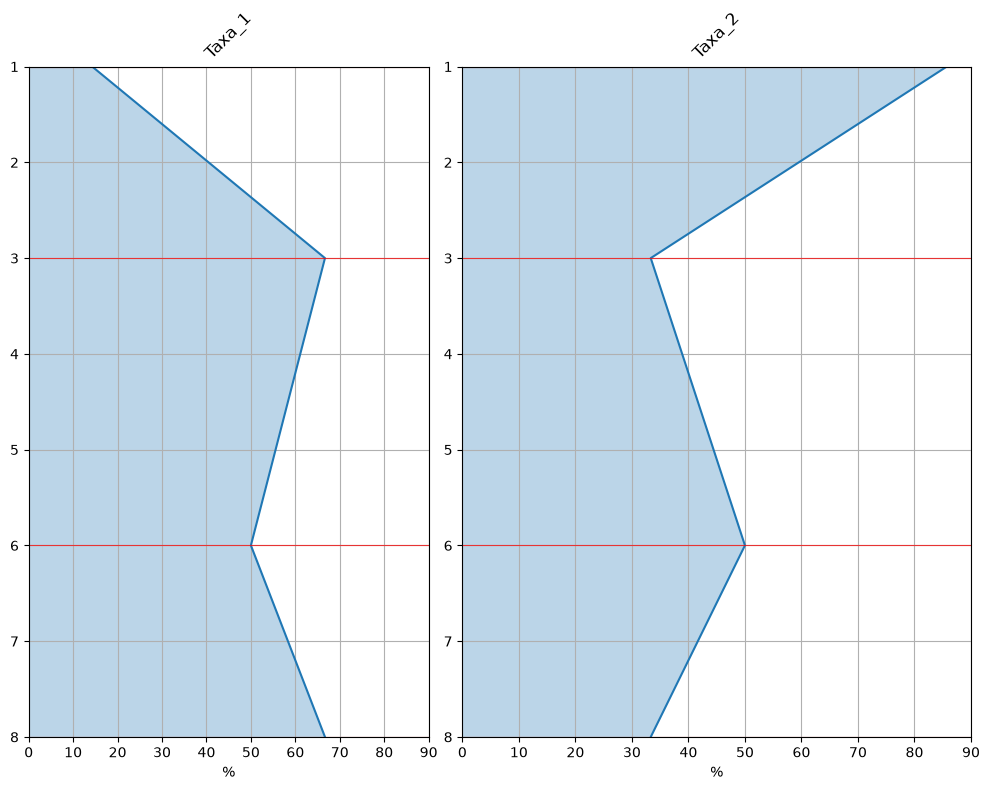

In [10]:
general_pollinic_diag(percent_data_simple, depth_simple, configuration)

Let's try to display more data. 
To do so, we will generate randomly a test dictionnary of 20 taxa of 30 layers :

In [11]:
data_complex = {}
for i in range(20): 
    table = np.random.randint(0, 400, size = 30).astype(float)
    data_complex[f'Taxa_{i}'] = table

depth_complex = np.random.choice(np.arange(1, 101), size = 30, replace=False)
depth_complex = np.sort(depth_complex)

print(data_complex)
print()
print(depth_complex)

{'Taxa_0': array([257., 399.,  24., 143., 369., 137., 271., 113., 240., 370., 175.,
       171., 395., 239.,  23., 125., 250., 247., 161., 158.,  91., 290.,
        20., 325.,  84., 206., 153., 141.,  99., 162.]), 'Taxa_1': array([328., 324., 316., 392., 232.,  25., 226., 200., 300., 162.,  85.,
       391.,   6., 112., 358.,  84., 186., 228., 214., 165., 227.,  81.,
       363., 392., 294.,  54.,  81., 189., 104.,   1.]), 'Taxa_2': array([333., 325., 187., 316., 195.,  13., 169., 122., 188., 238., 138.,
       277., 380., 397., 169., 227., 235., 264., 233., 392.,  41., 140.,
       165., 183., 263.,  39., 390., 292., 200., 292.]), 'Taxa_3': array([308., 111., 208., 363., 184.,  60.,  51., 238., 390., 187., 336.,
       344., 280.,  90., 337.,  65.,  26., 123., 254., 250., 118., 282.,
       296., 222., 292., 194., 335.,  10., 230., 115.]), 'Taxa_4': array([295., 214., 254., 260., 112., 372., 115., 106.,  71., 192.,  53.,
        42., 383.,  74.,  30., 342., 397.,   8.,  12.,  67., 313

Testing the printing : 

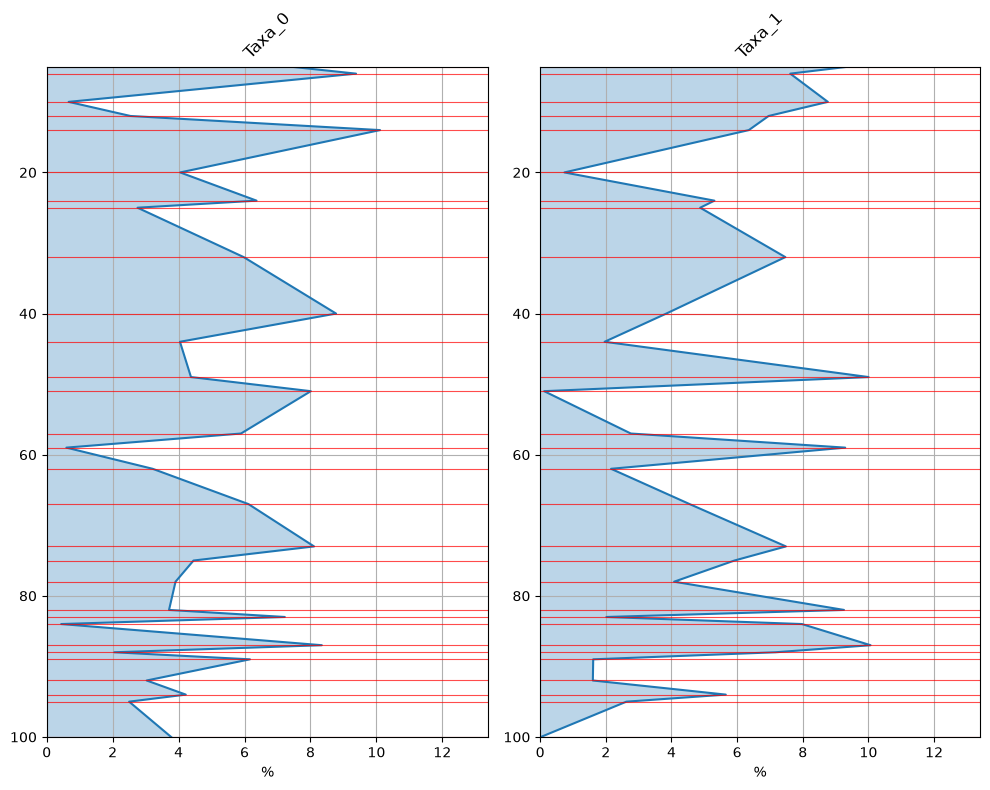

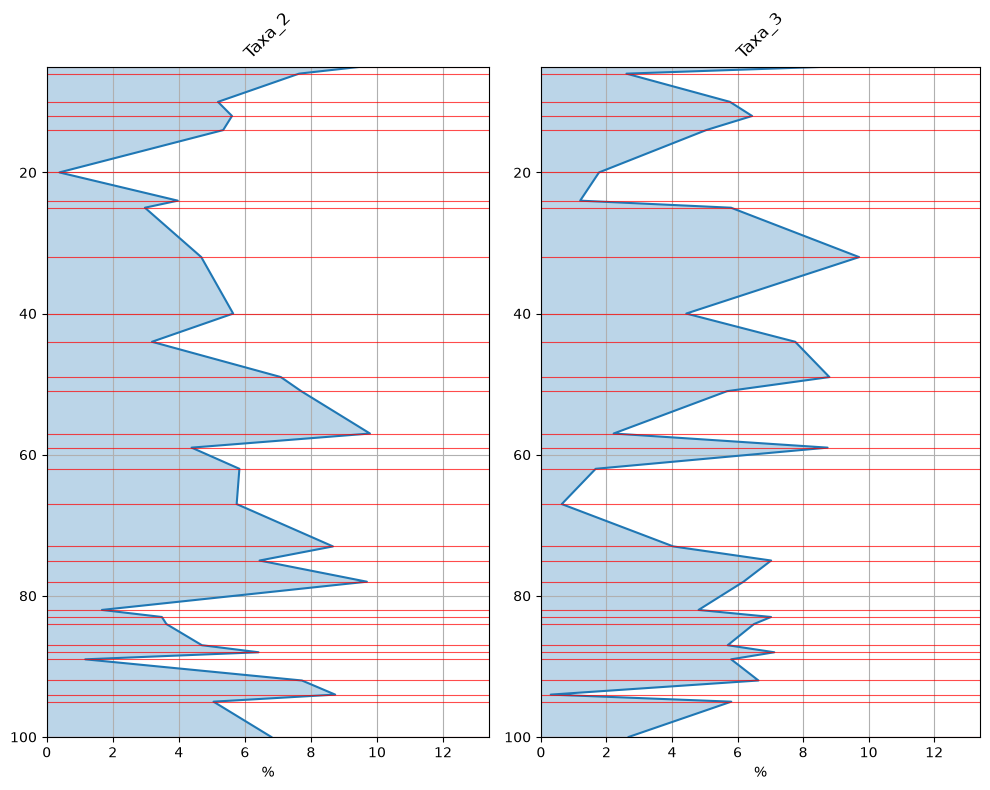

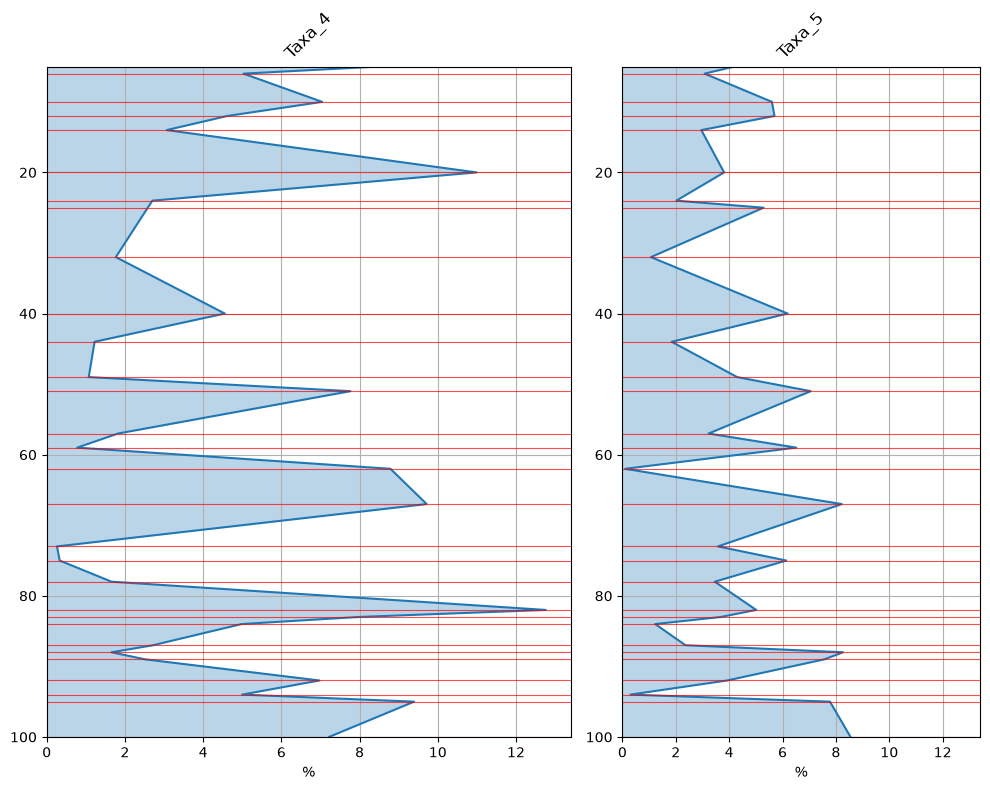

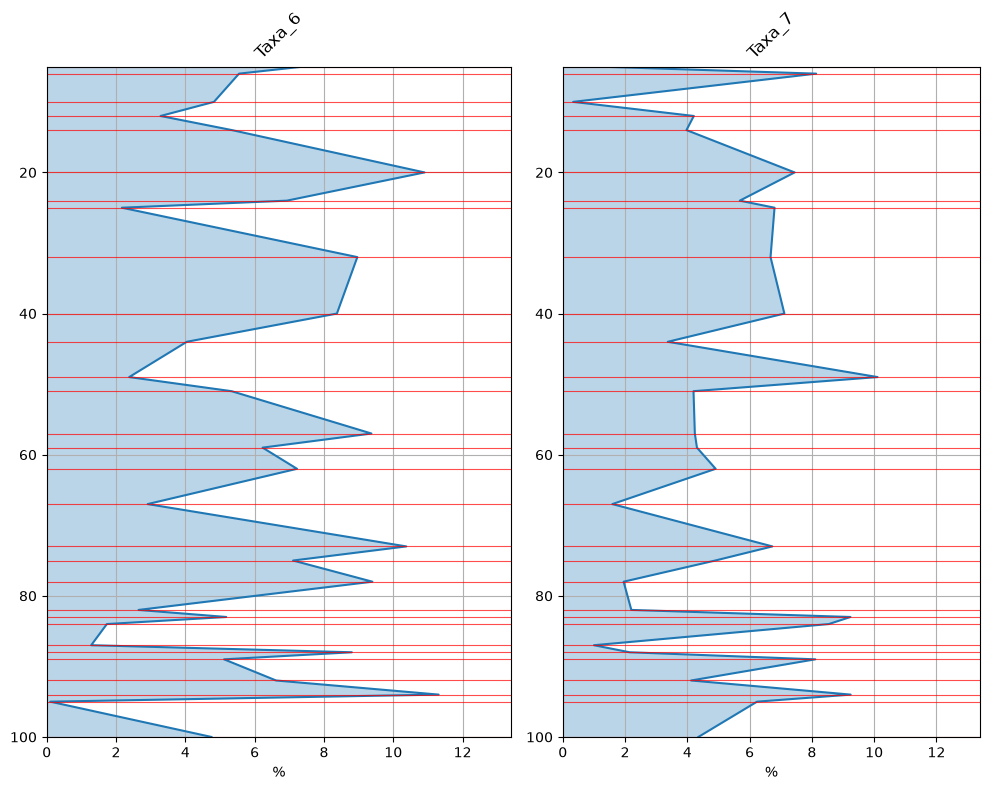

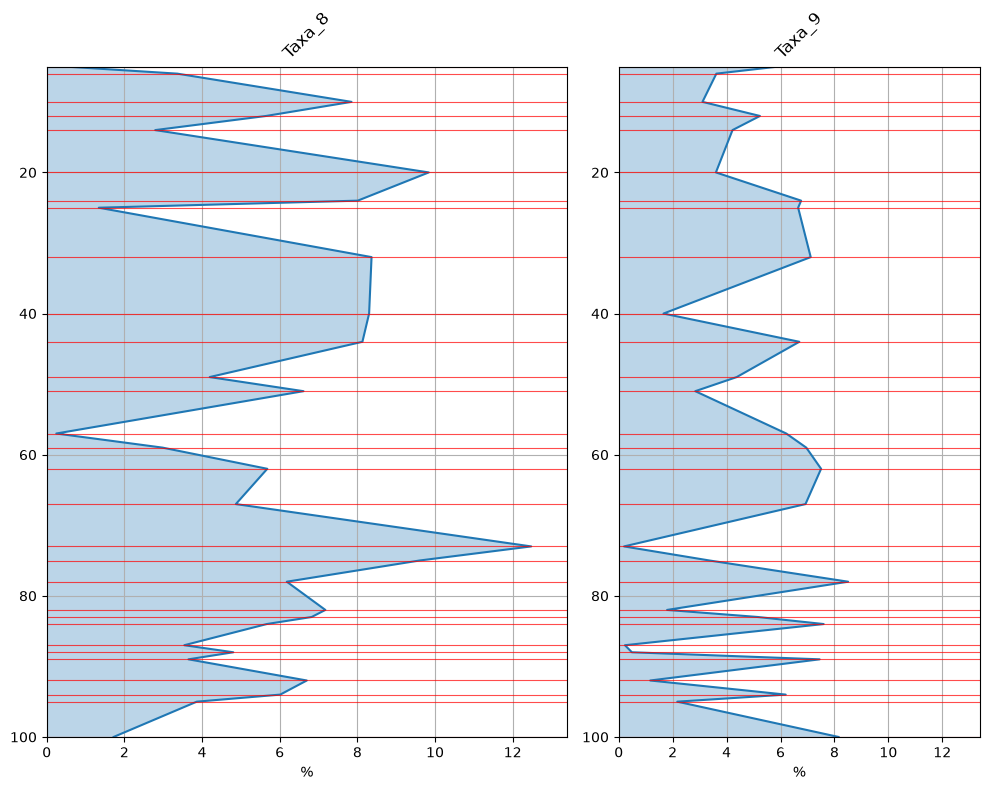

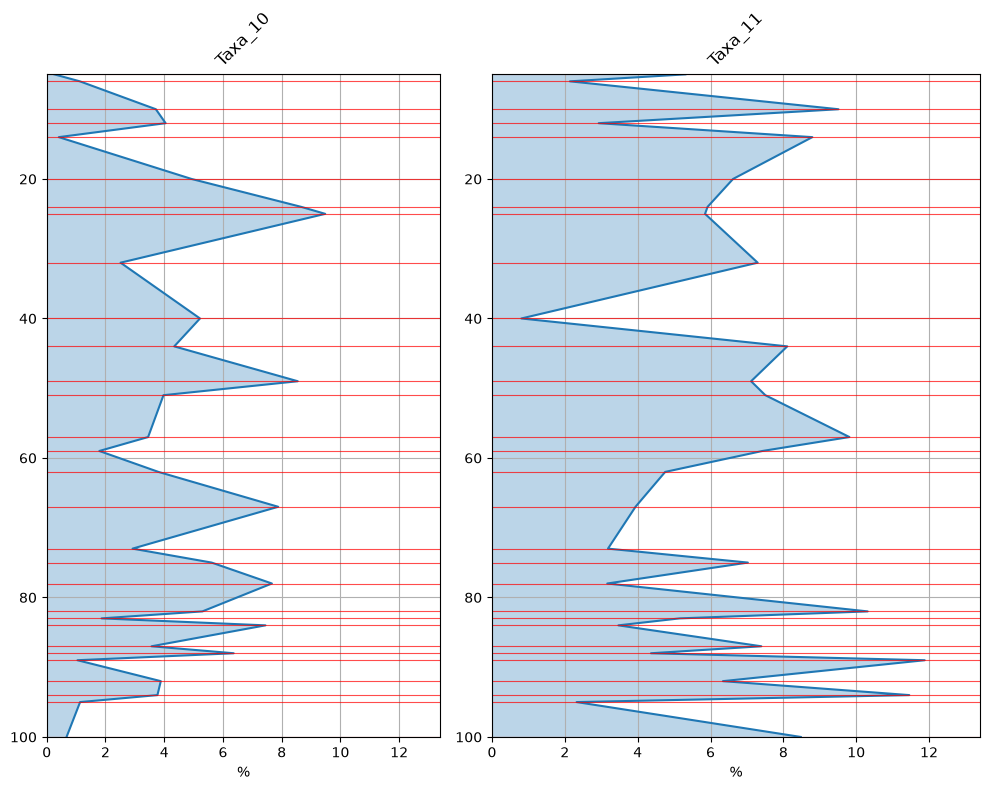

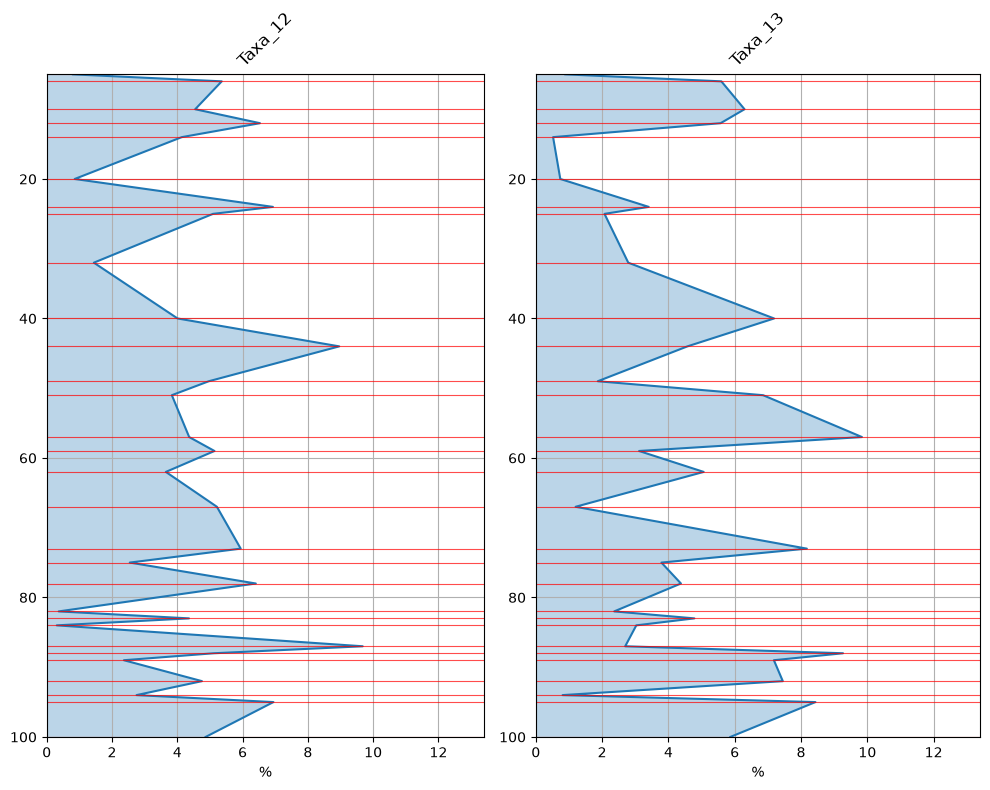

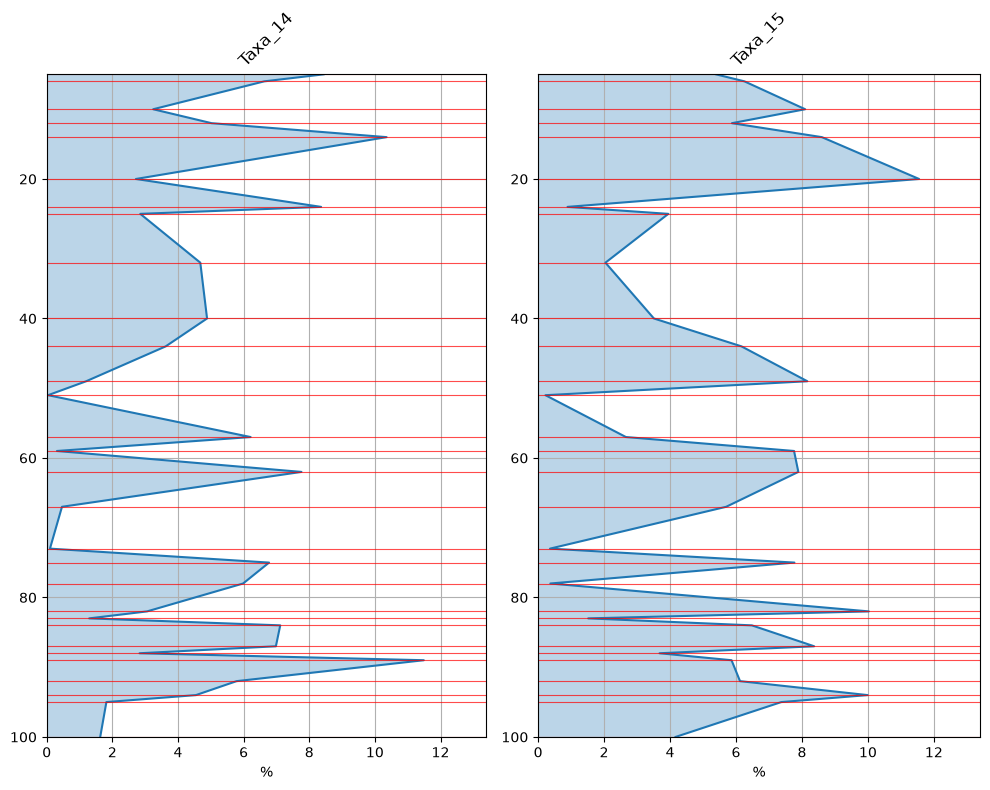

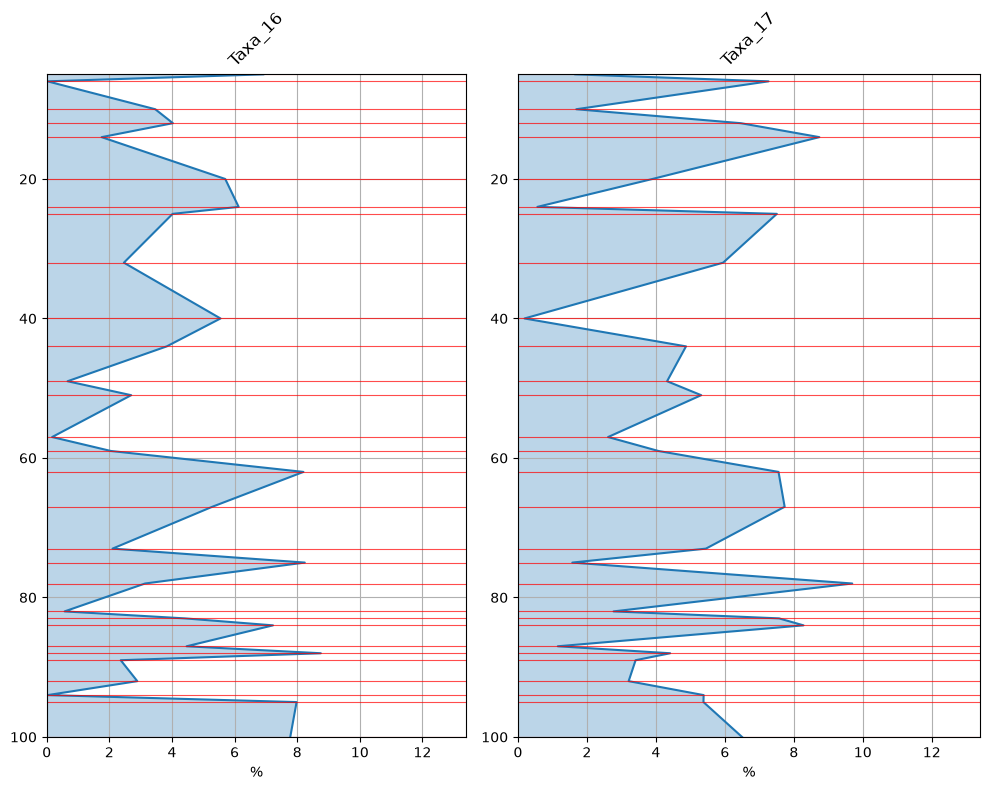

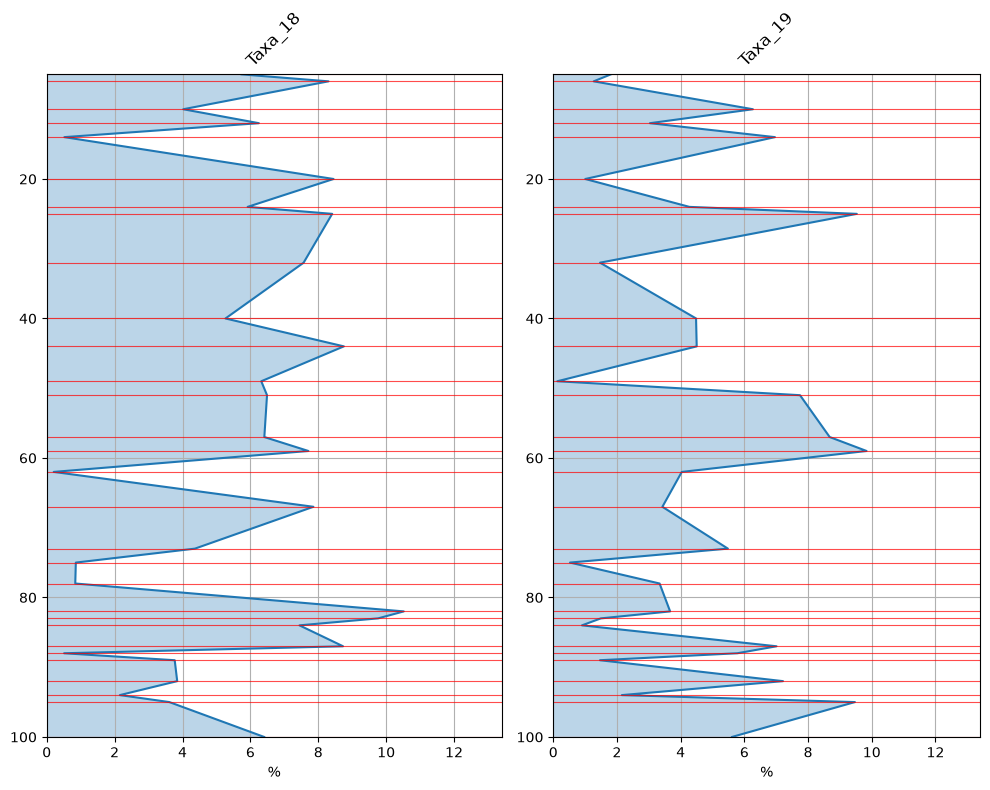

In [12]:
percent_data_complex = percentage(data_complex, depth_complex)
general_pollinic_diag(percent_data_complex, depth_complex, configuration)

The excel file treated by pandas is : 
                         0    1    2    3    4    5     6     7     8     9   \
0              Sample depth  1.0  4.0  5.0  7.0  9.0  11.0  13.0  15.0  17.0   
1                   _ABIES,  1.0  1.0  NaN  NaN  5.0   2.0   NaN   NaN   NaN   
2                  _CEDRUS,  NaN  2.0  NaN  NaN  NaN   2.0   4.0   NaN   1.0   
3               _JUNIPERUS,  1.0  4.0  1.0  4.0  5.0   4.0   NaN  10.0   2.0   
4                   _PICEA,  1.0  1.0  NaN  1.0  NaN   NaN   NaN   NaN   NaN   
..                      ...  ...  ...  ...  ...  ...   ...   ...   ...   ...   
75   _CYPERACEAE/JUNCACEAE,  NaN  1.0  NaN  1.0  NaN   6.0   NaN   NaN   1.0   
76            _FILIPENDULA,  NaN  NaN  NaN  NaN  NaN   2.0   NaN   NaN   NaN   
77  _POLYGONUM BISTORTA t.,  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   NaN   
78             _THALICTRUM,  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   NaN   
79             _ALCHEMILLA,  NaN  NaN  NaN  NaN  NaN   NaN   NaN   NaN   NaN   



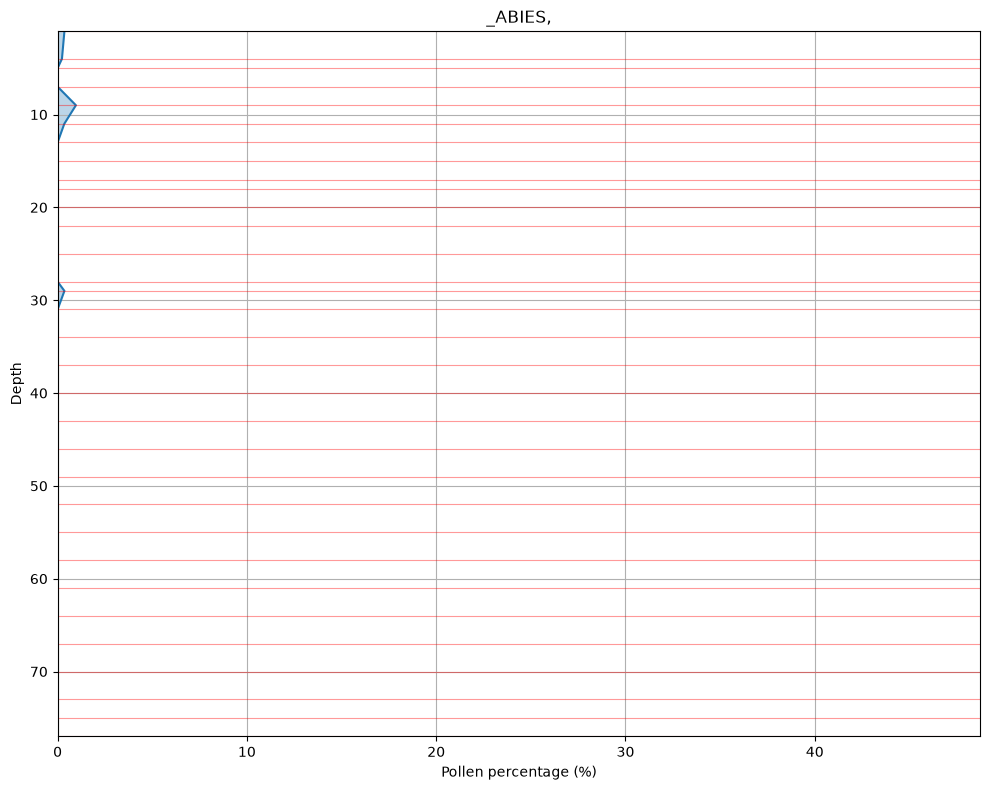

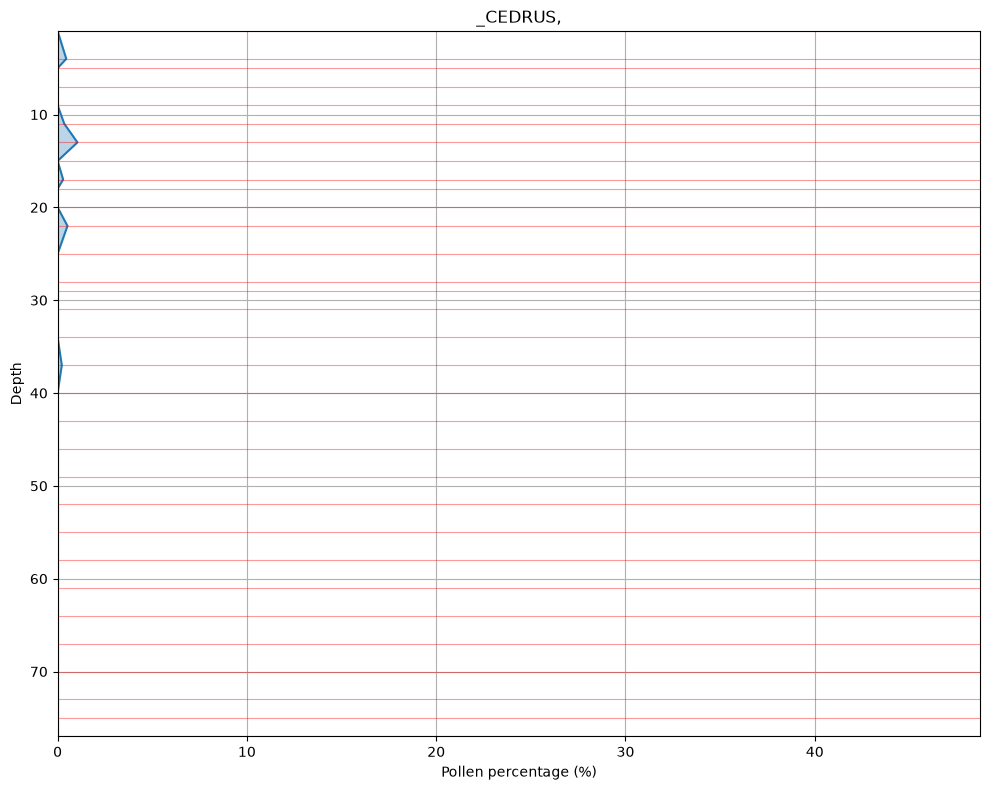

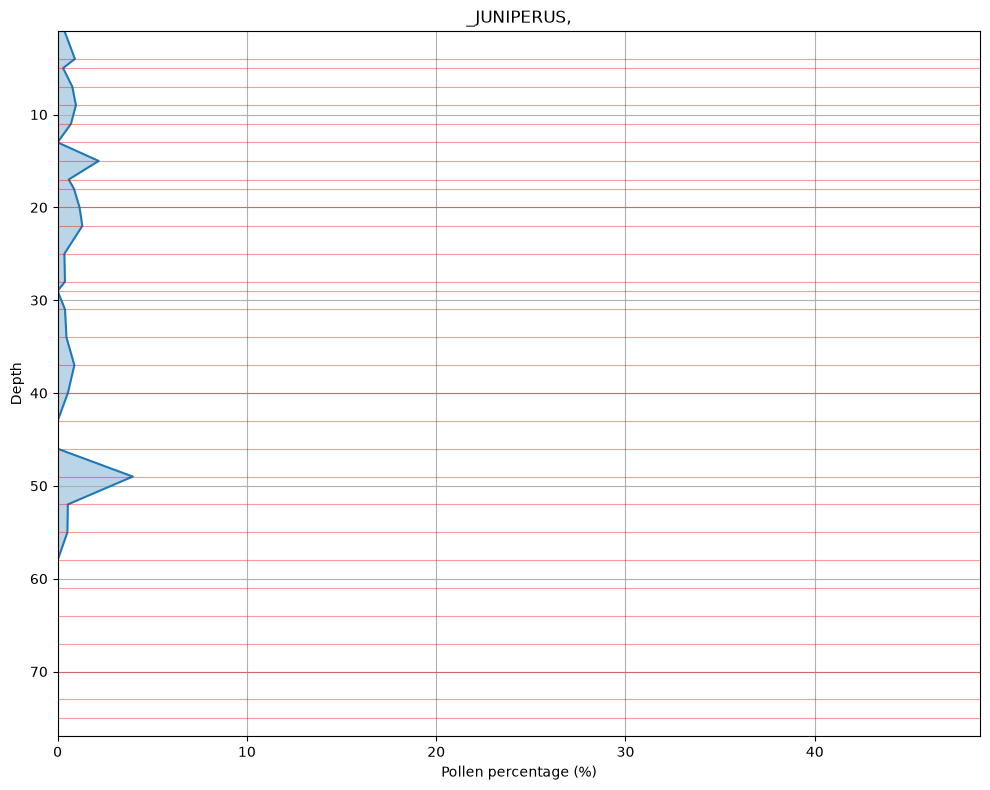

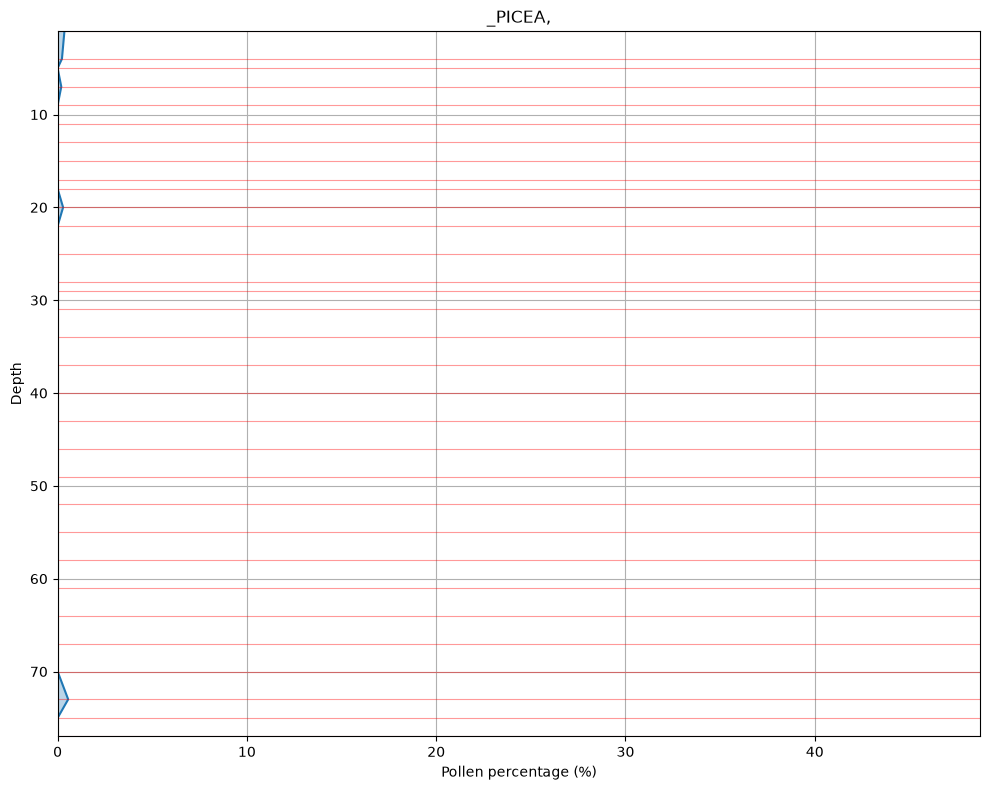

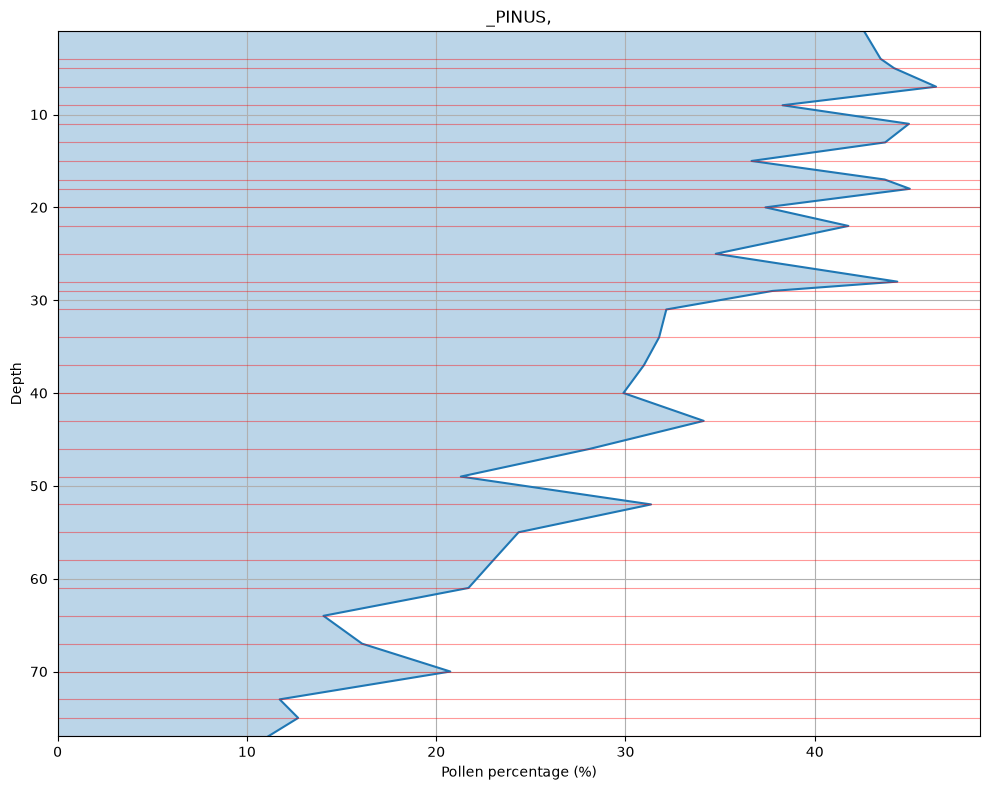

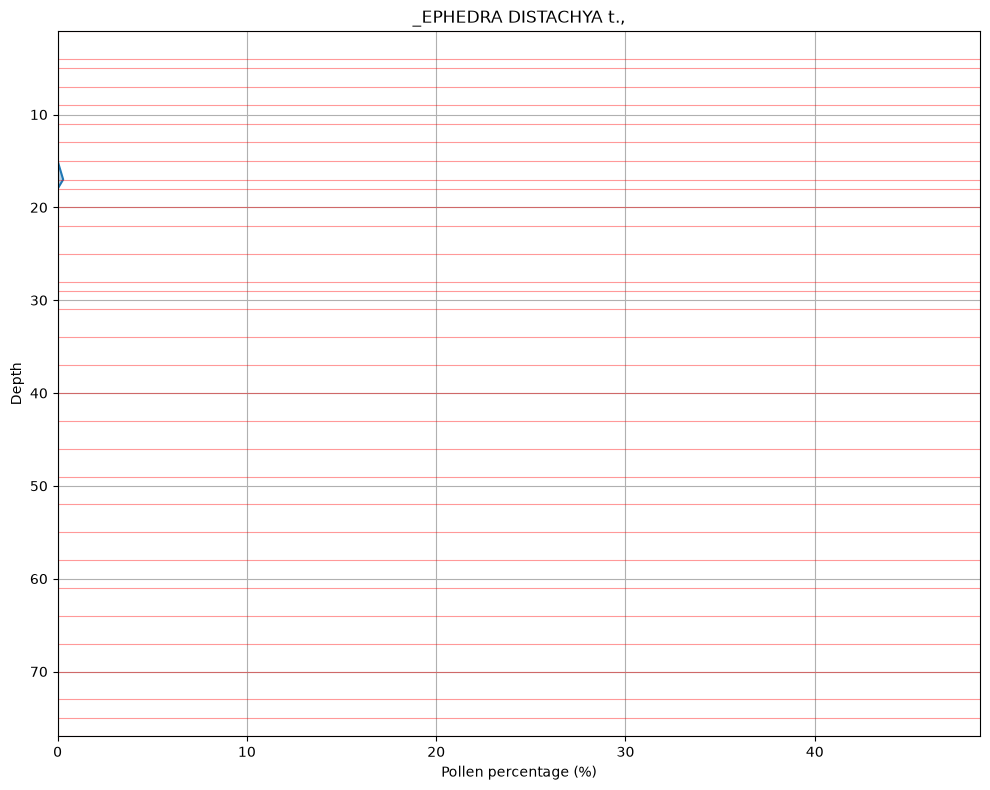

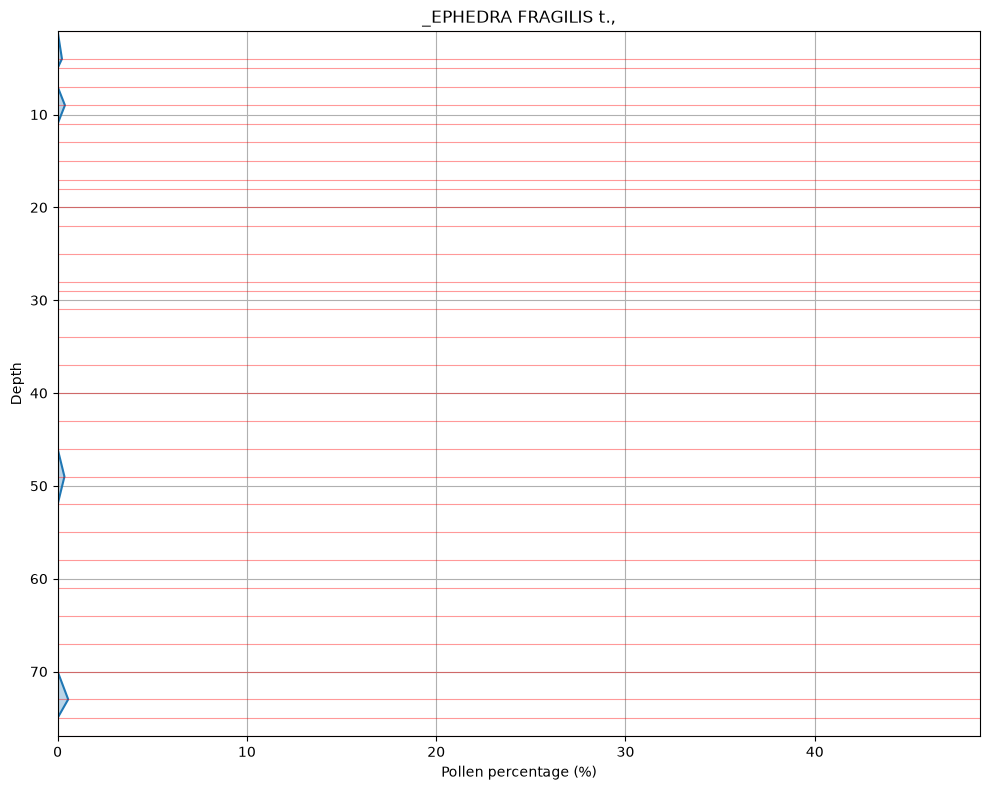

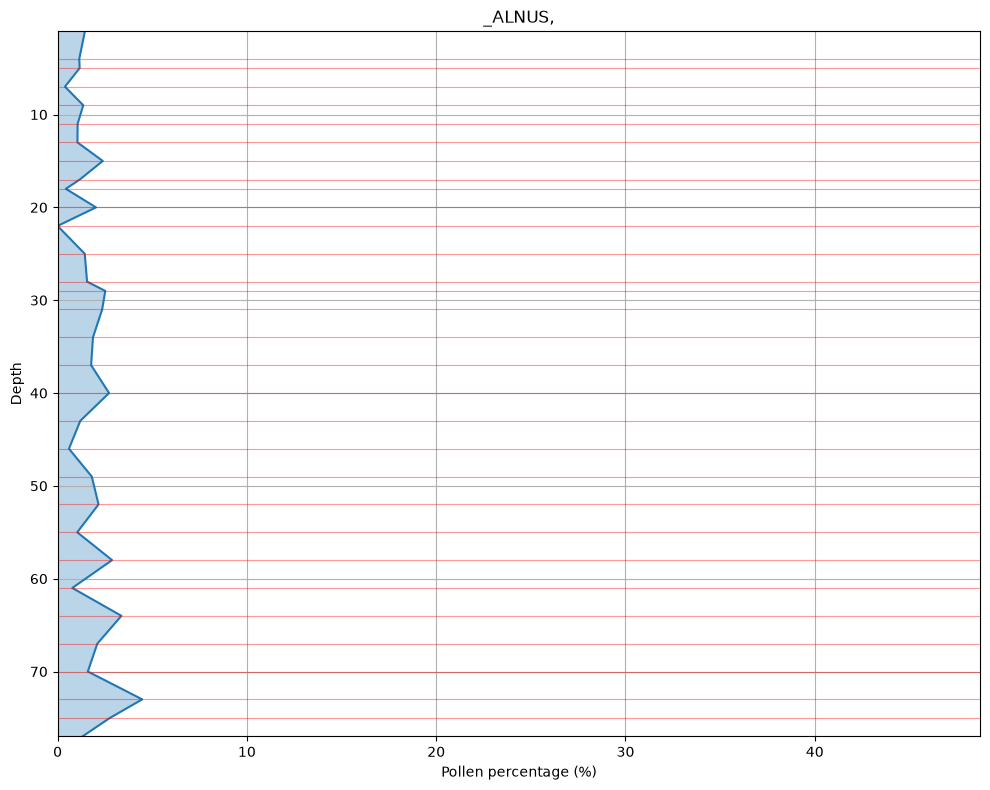

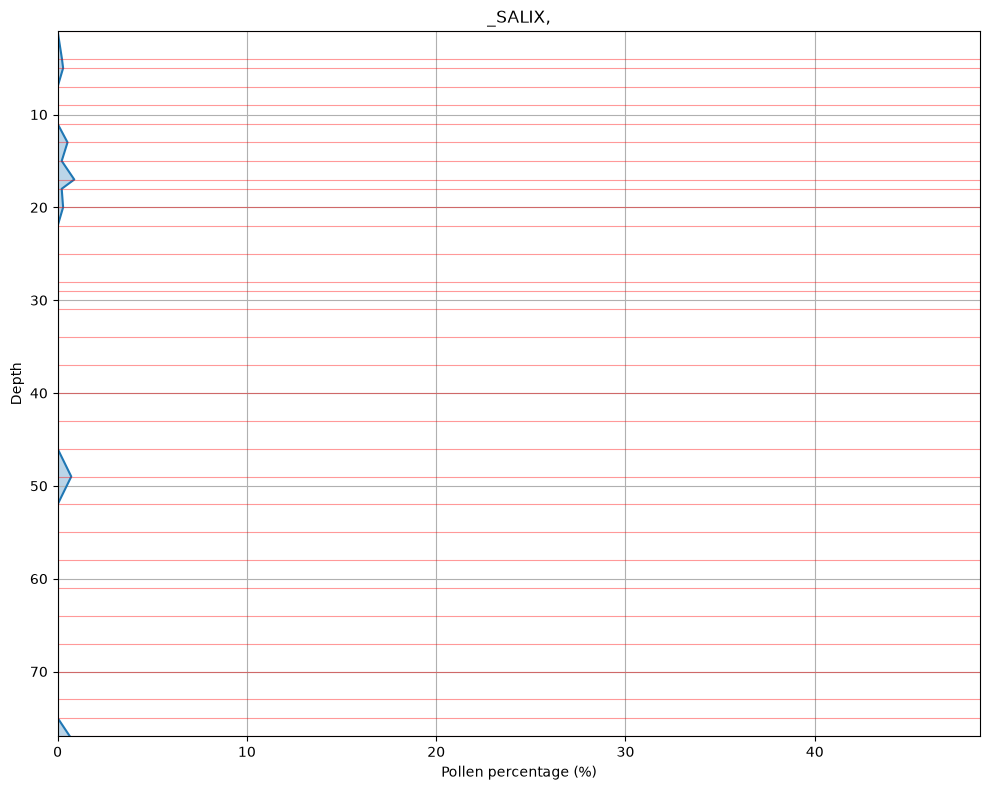

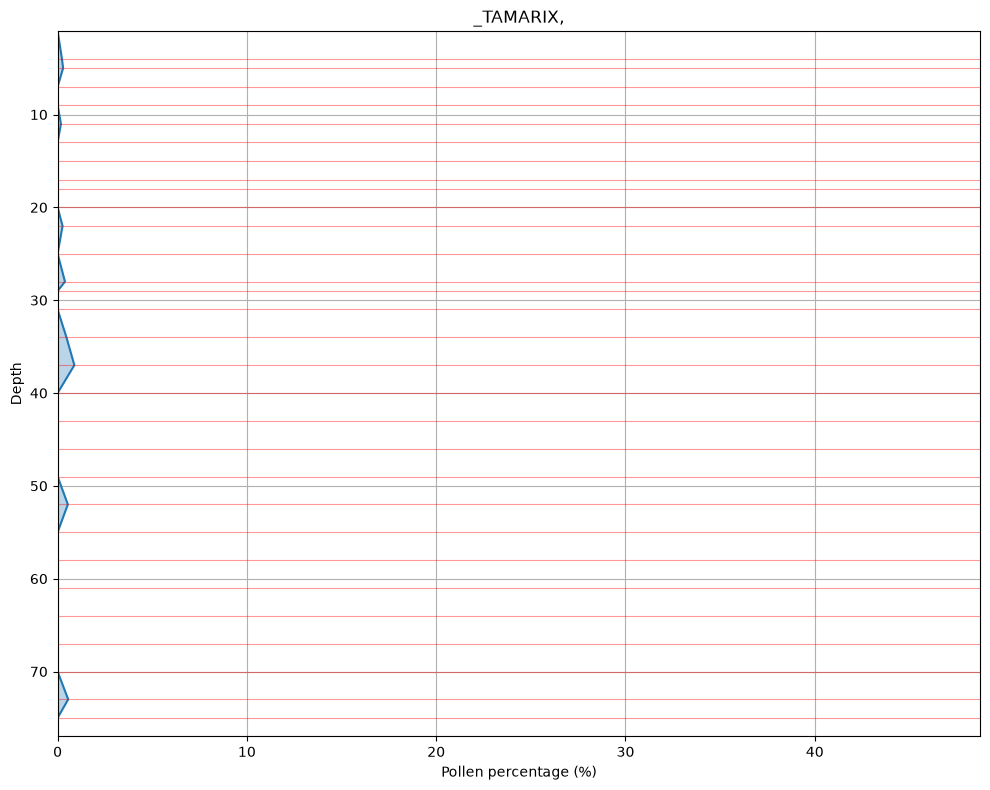

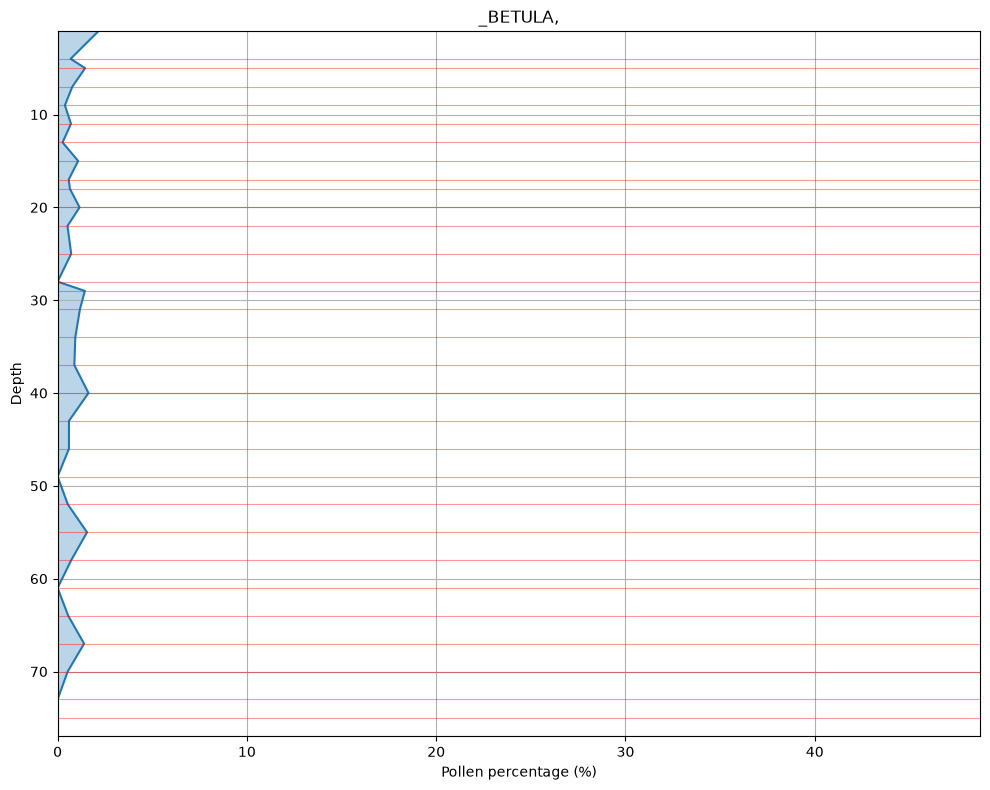

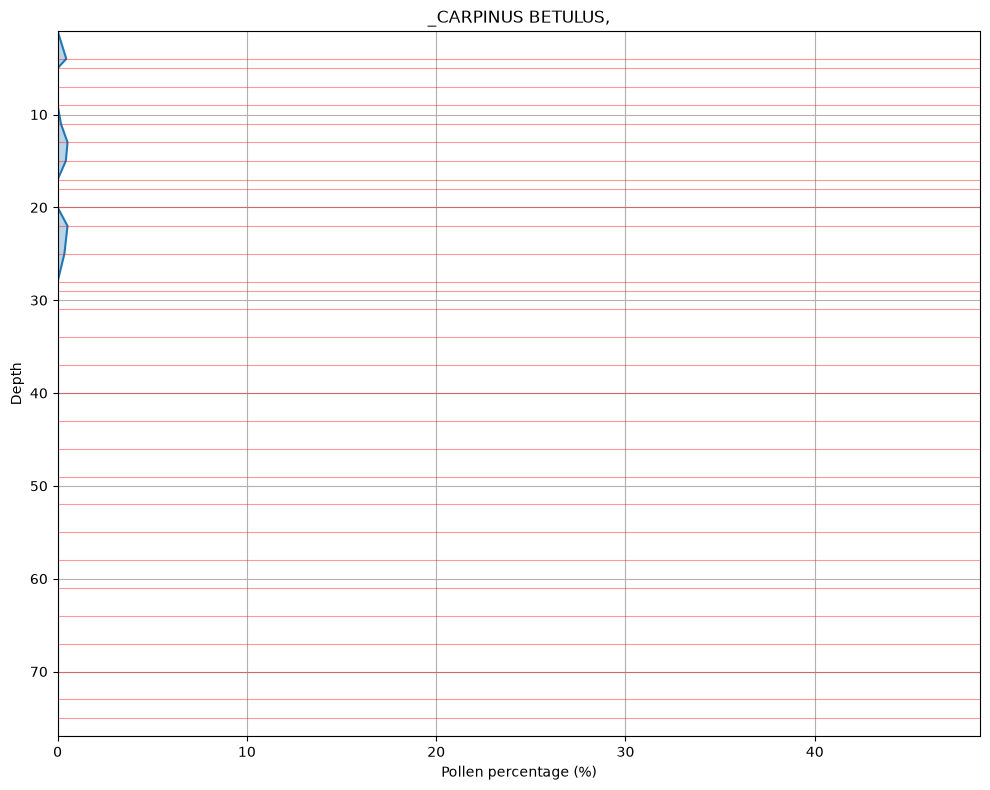

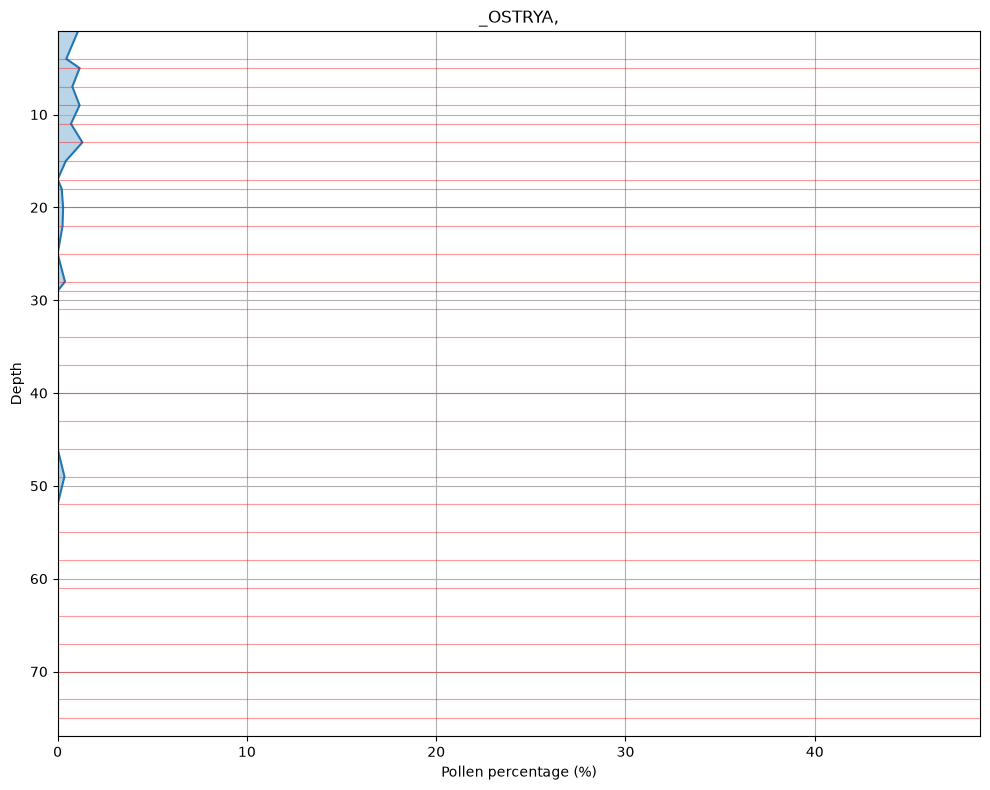

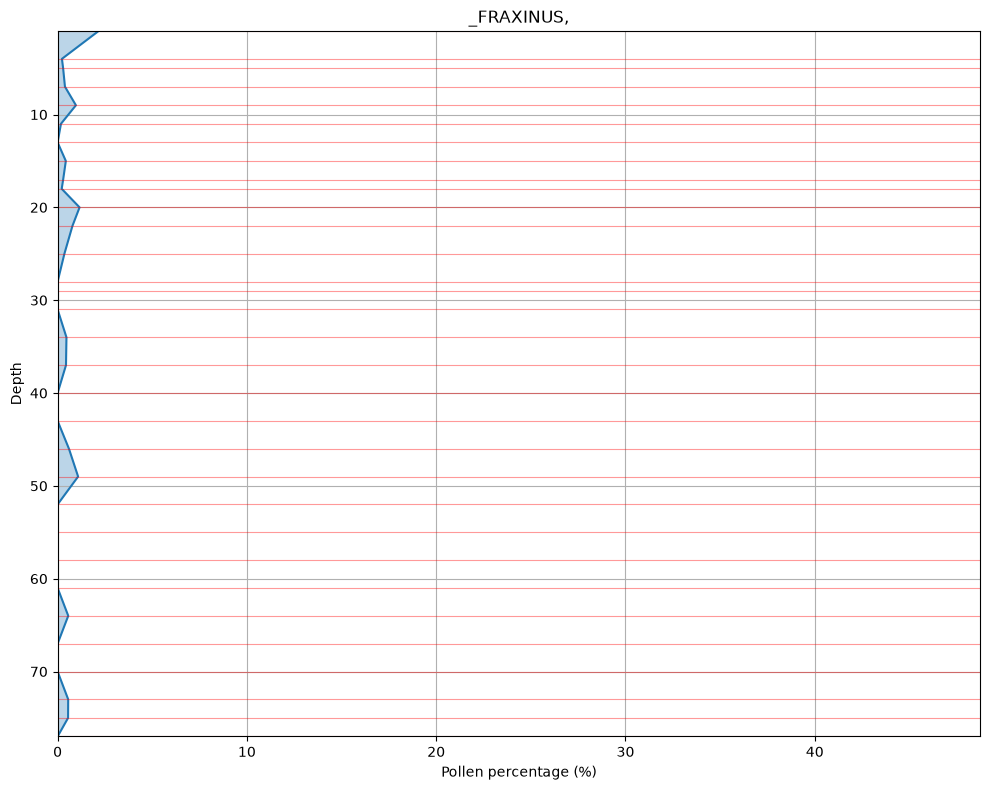

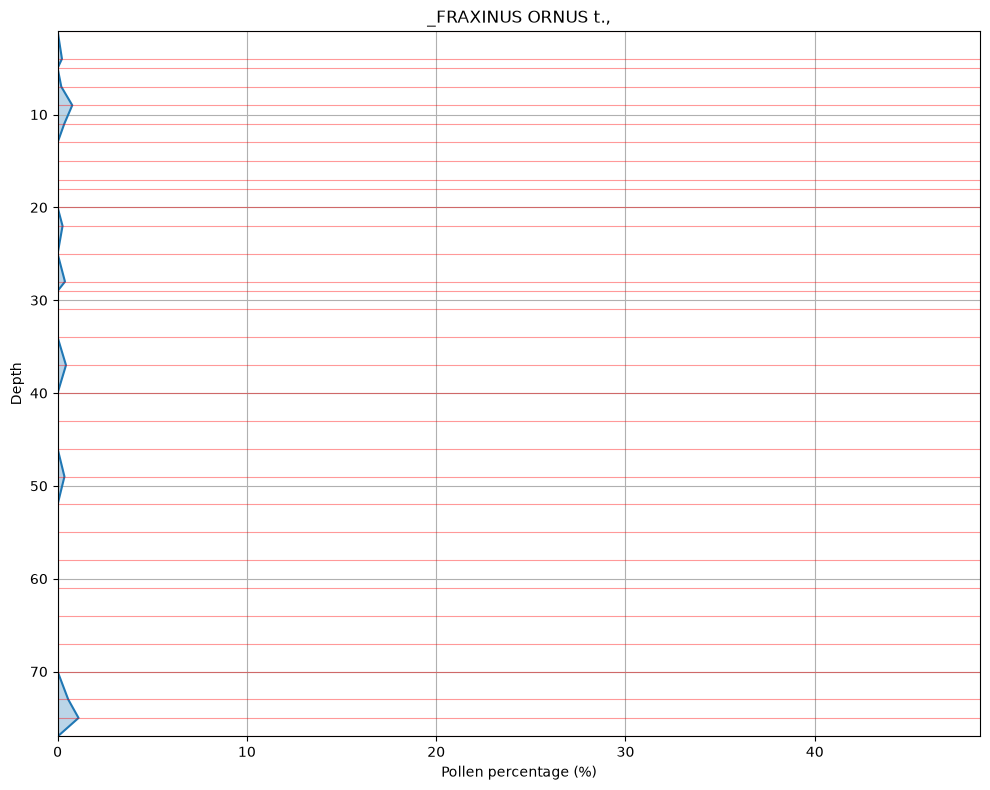

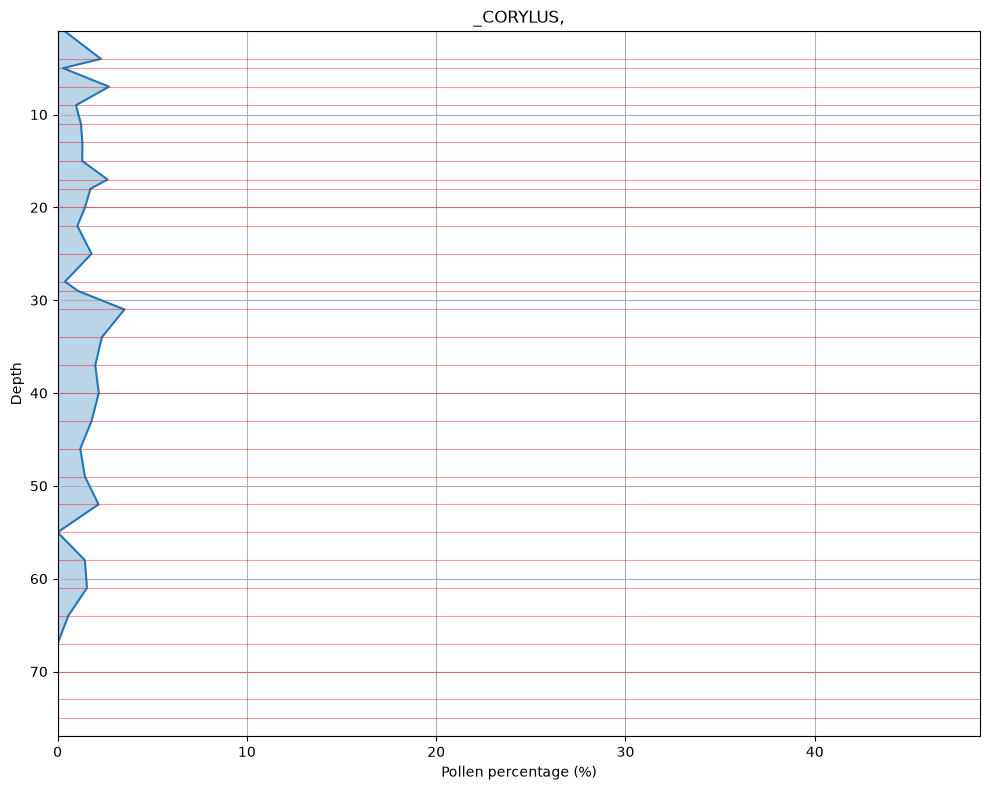

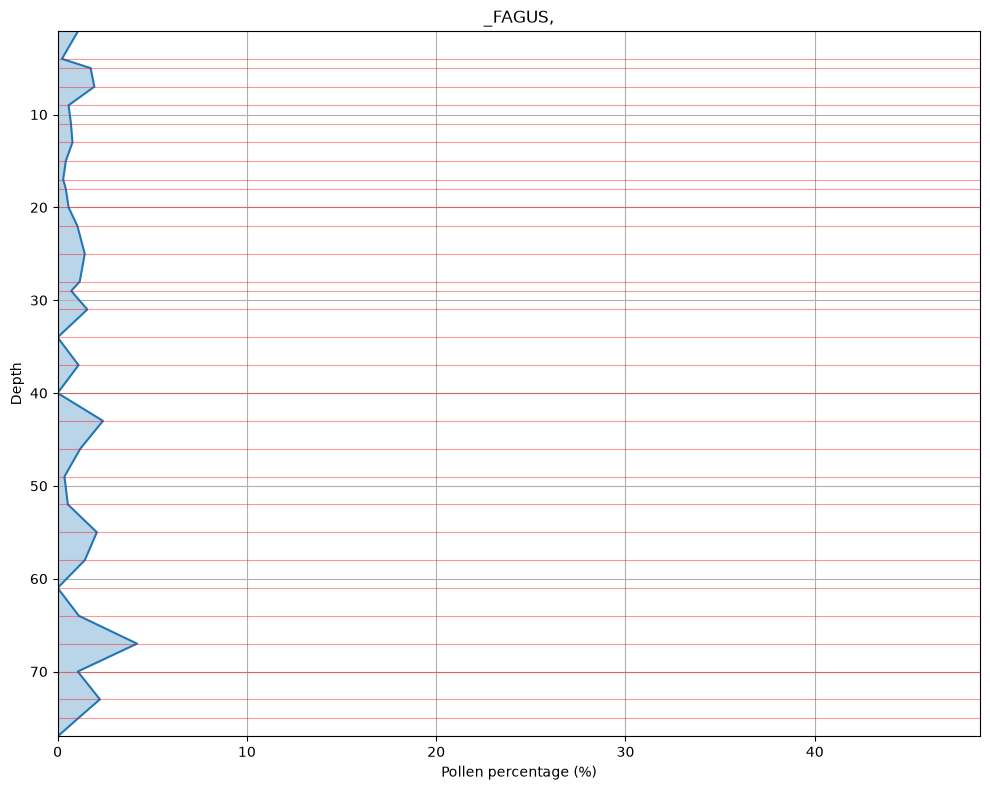

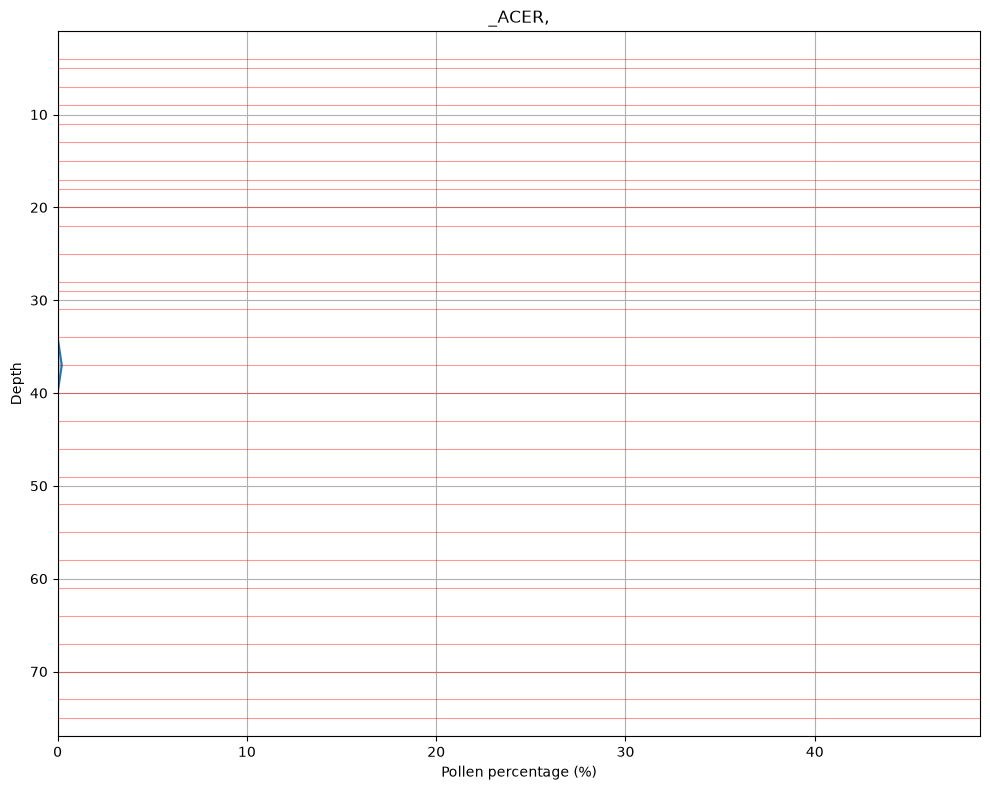

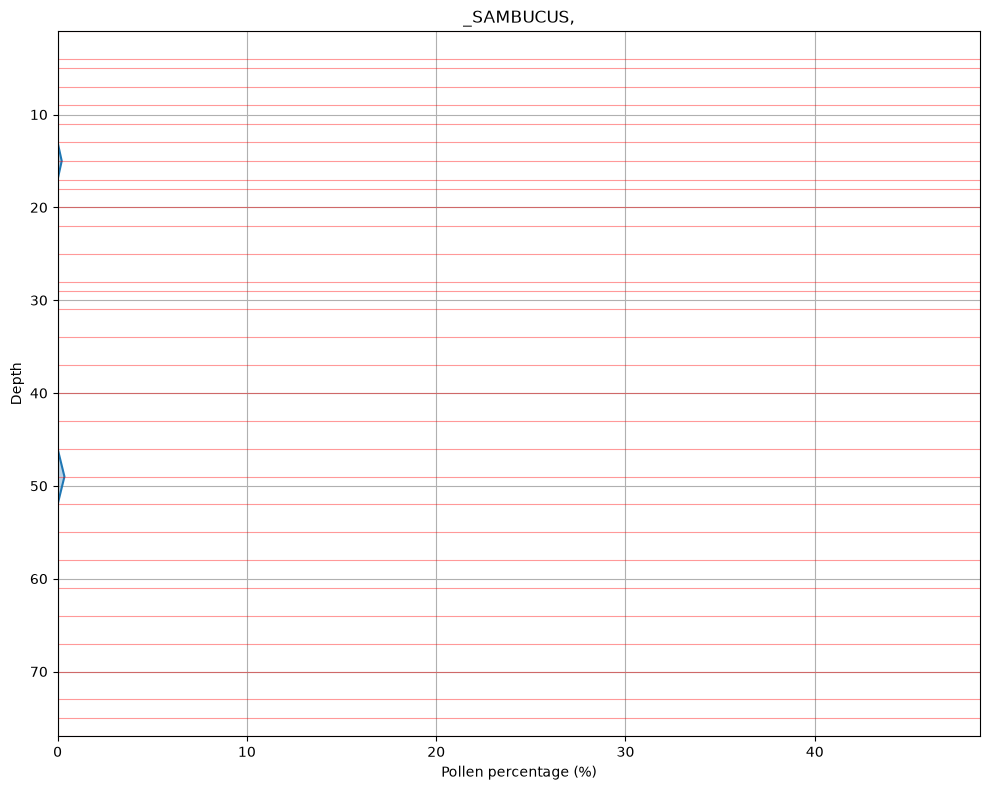

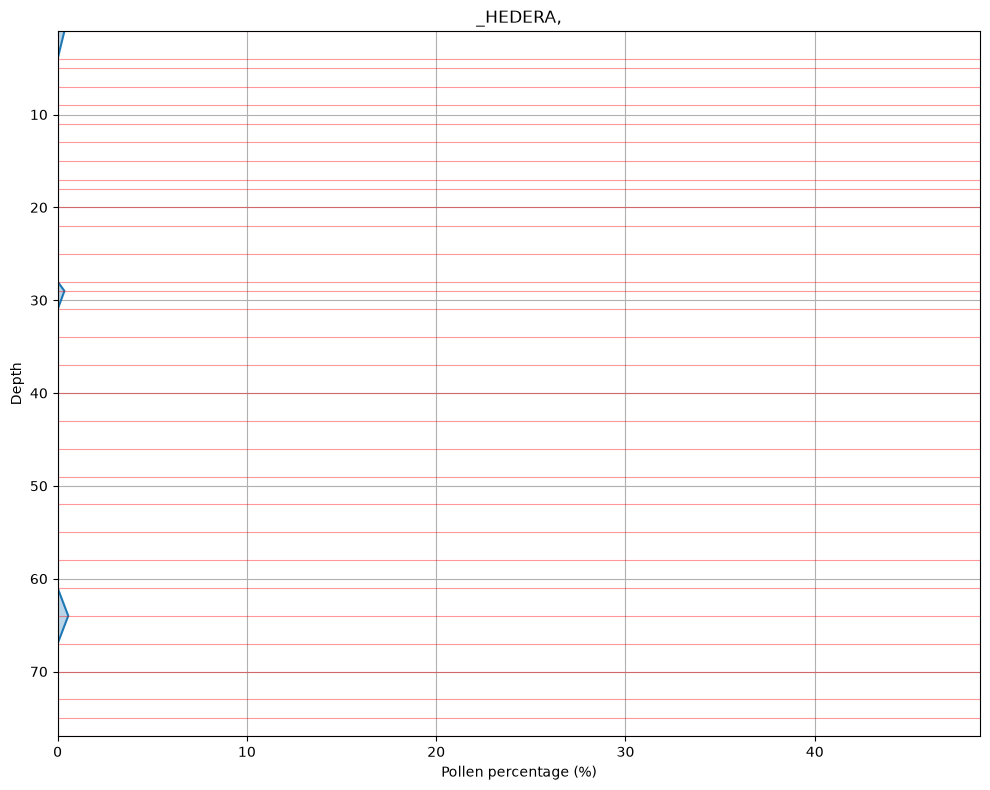

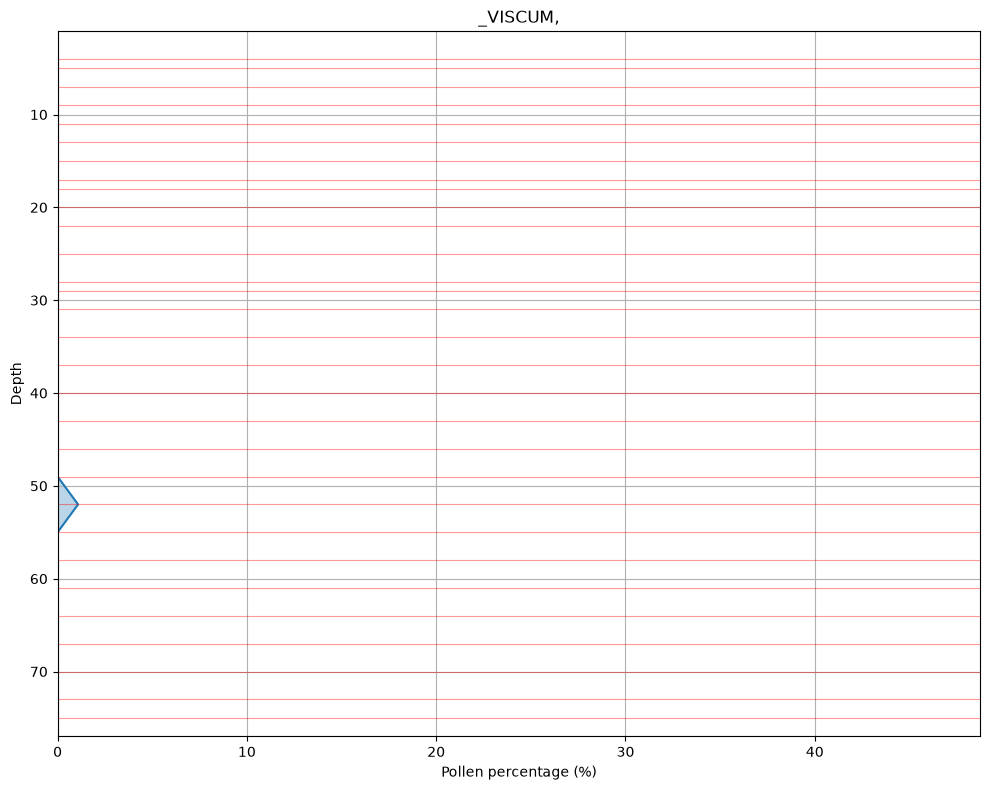

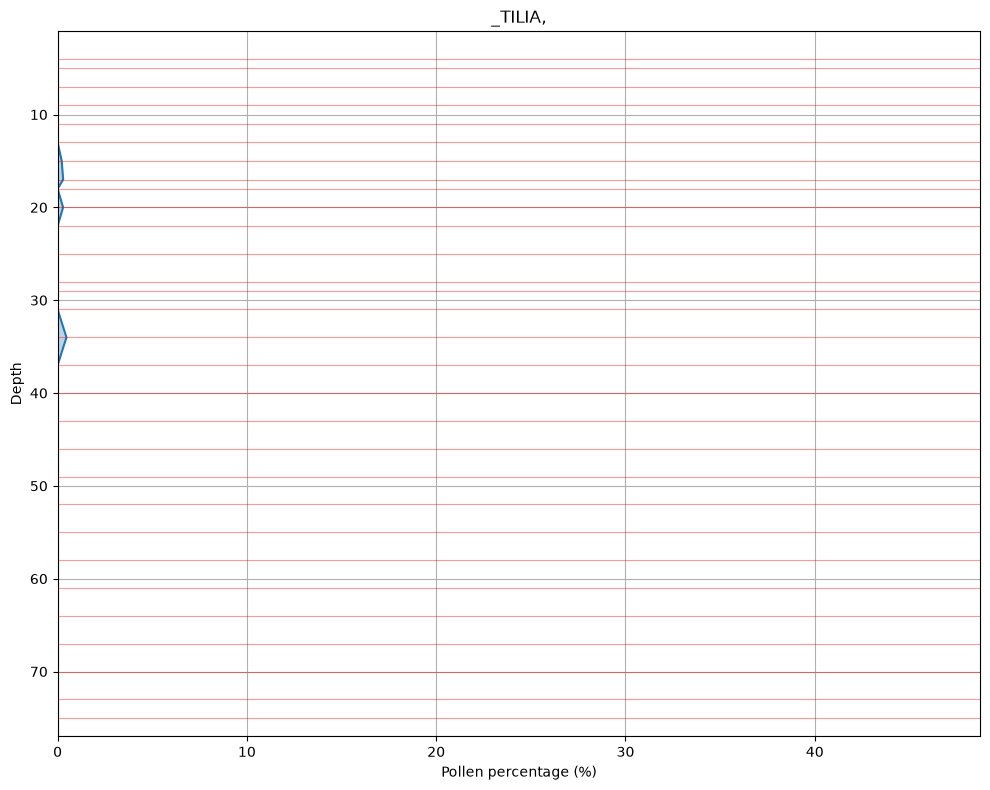

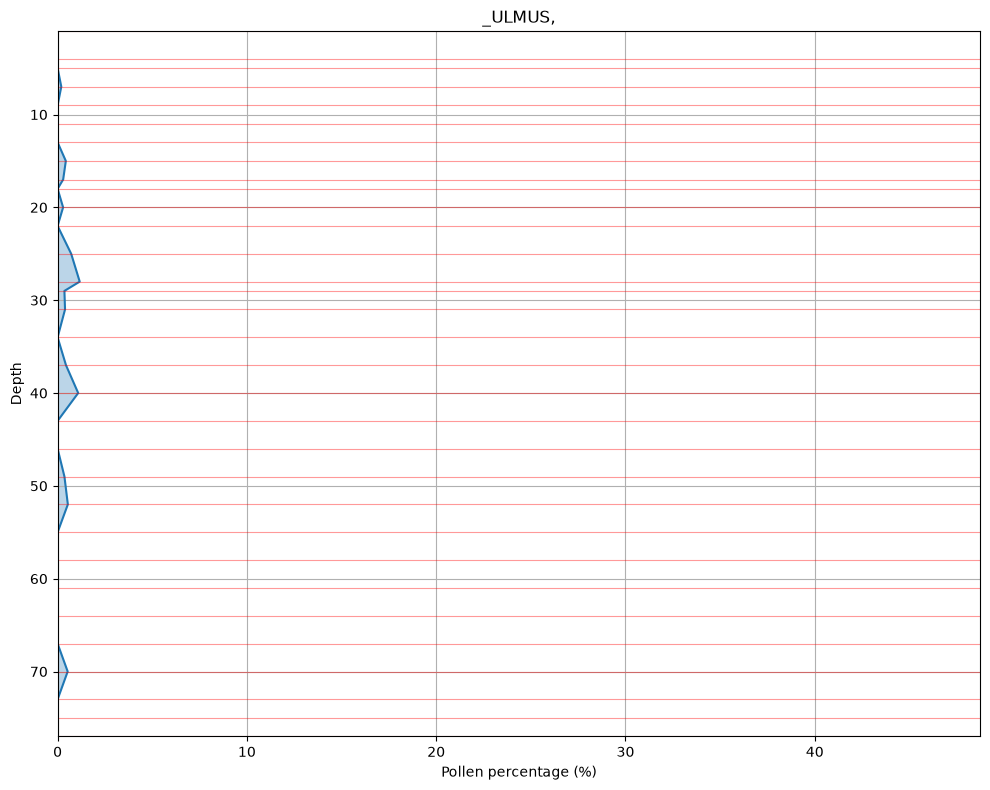

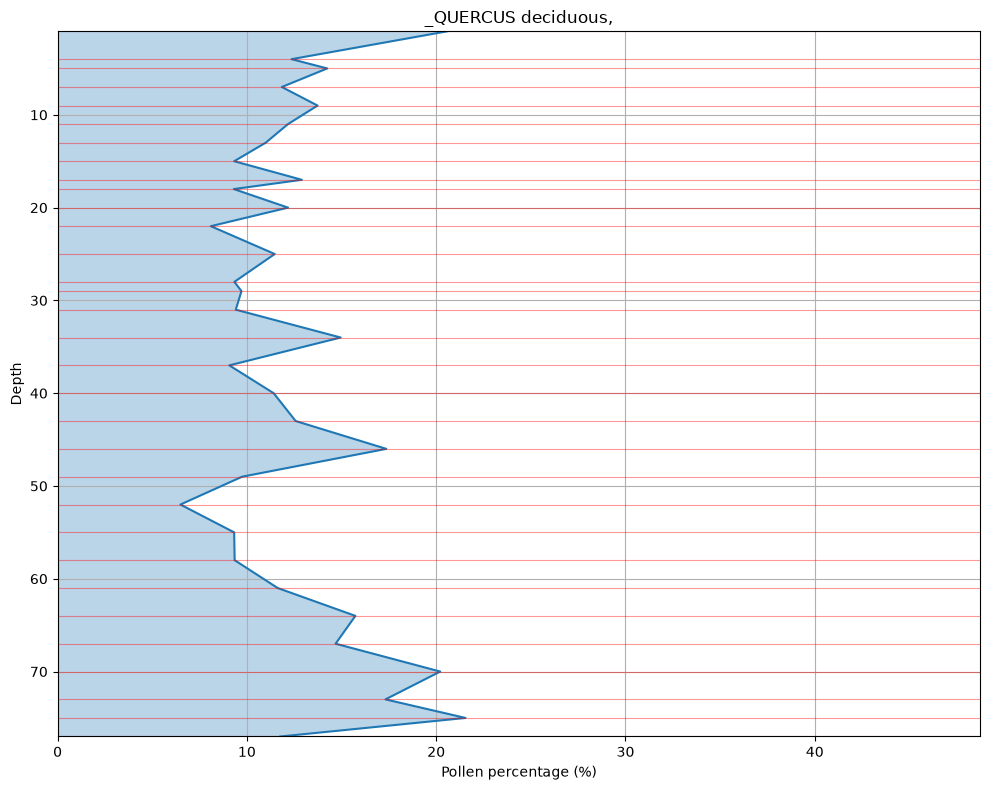

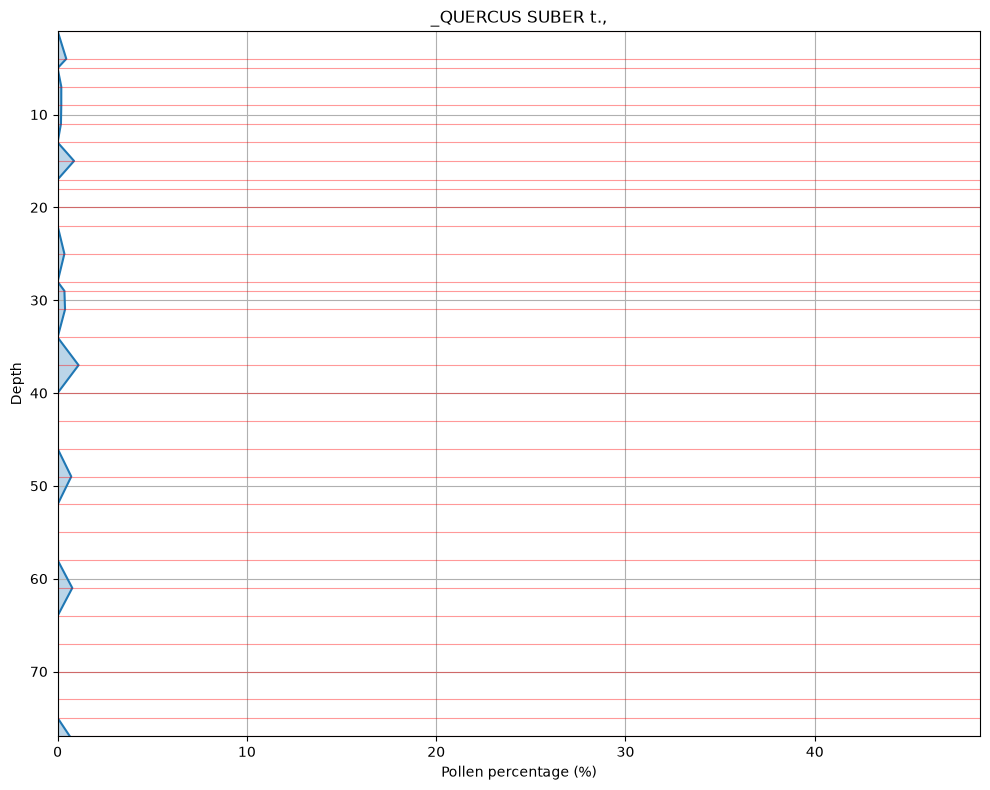

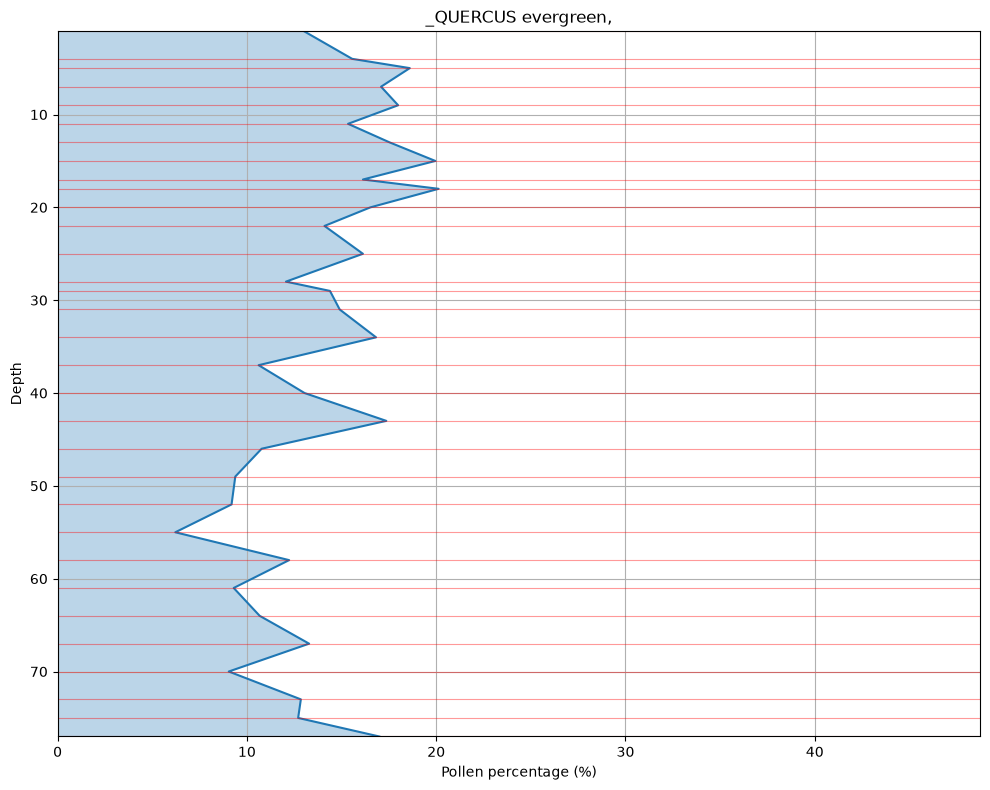

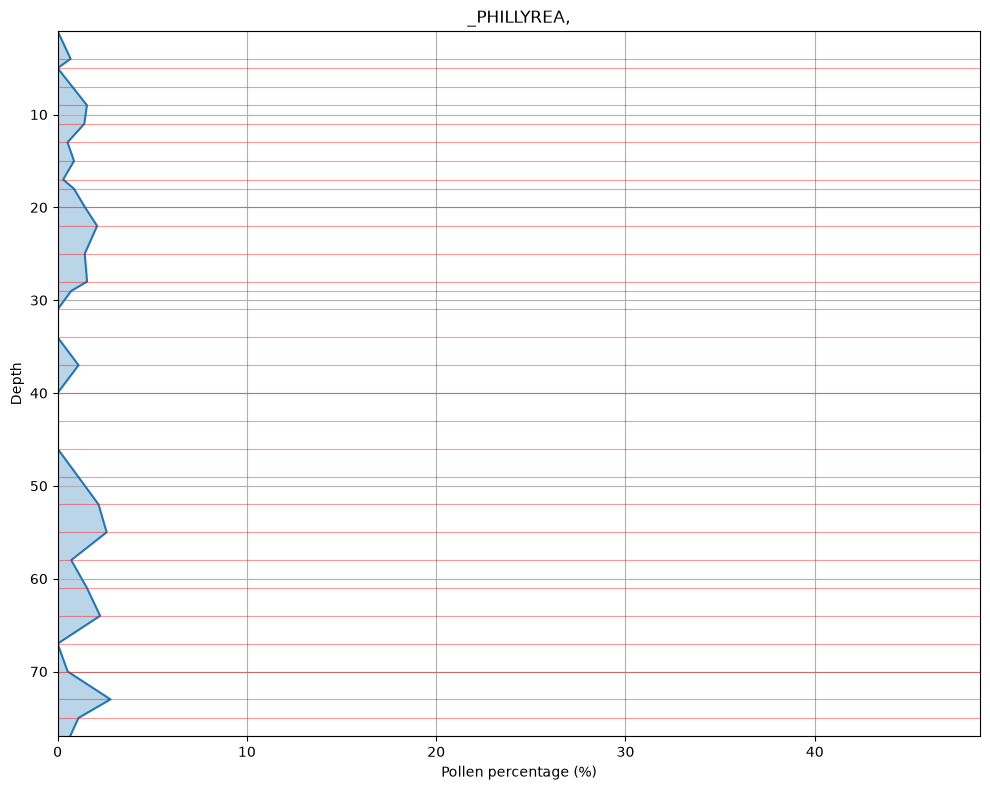

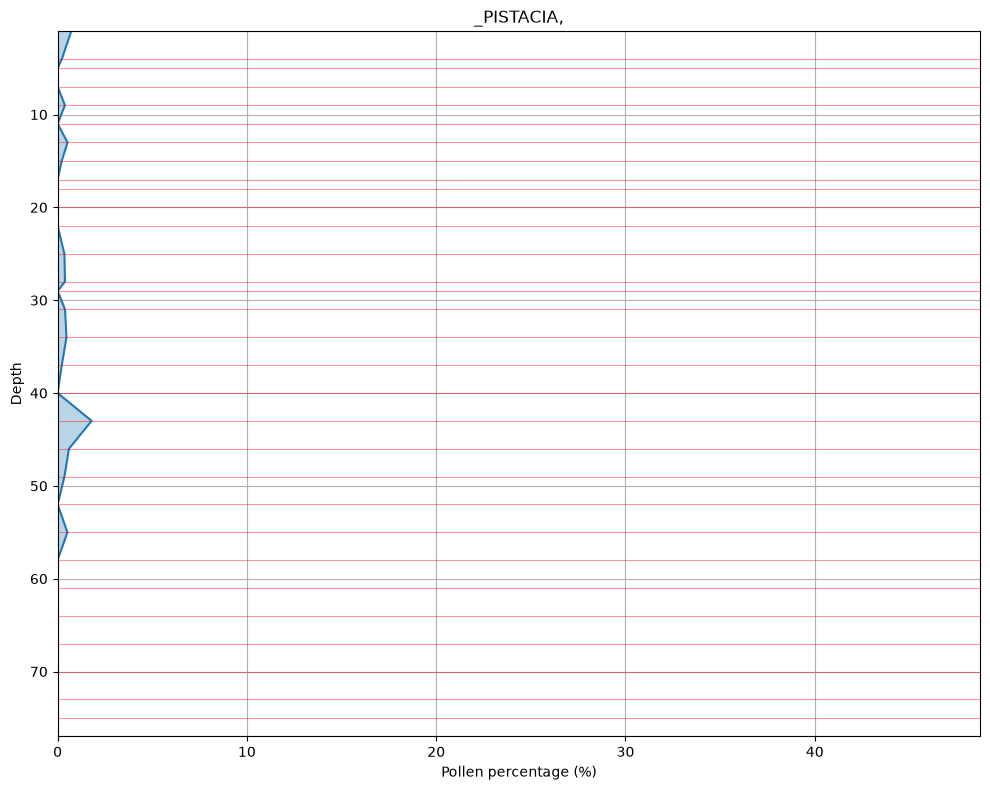

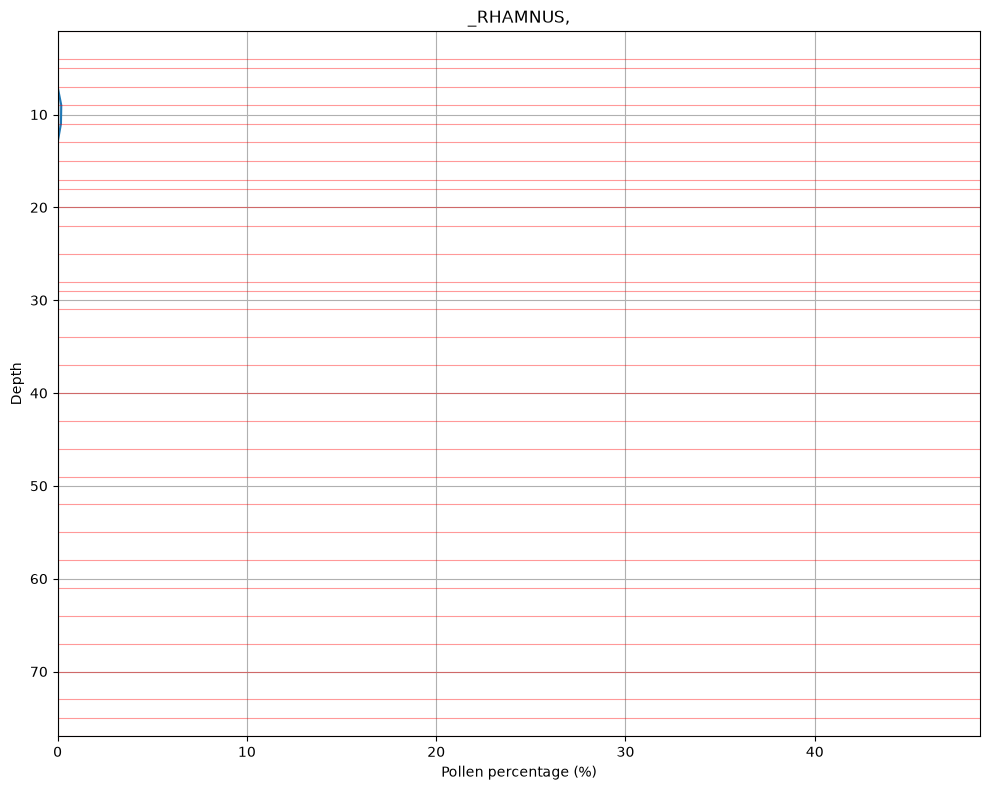

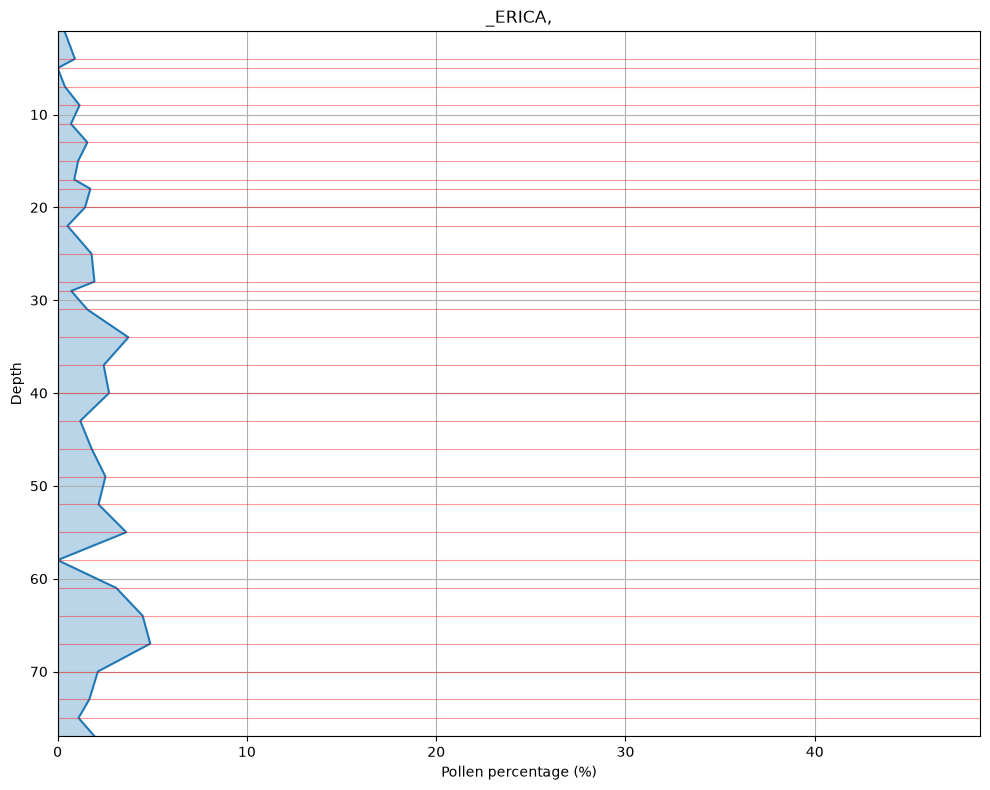

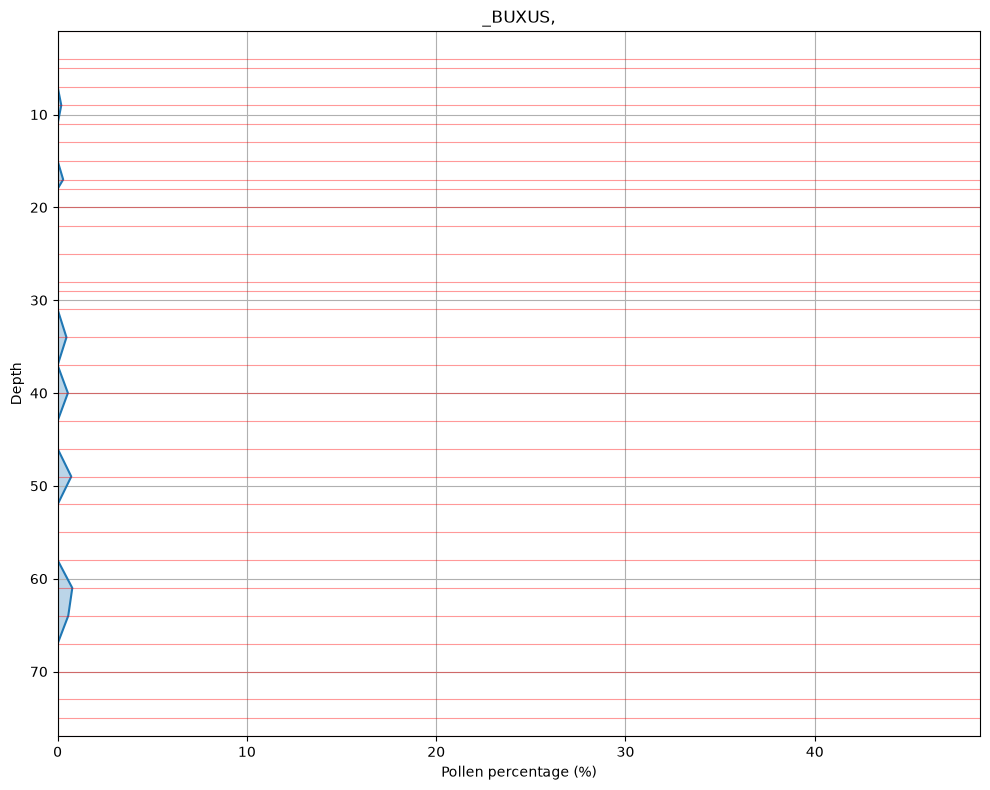

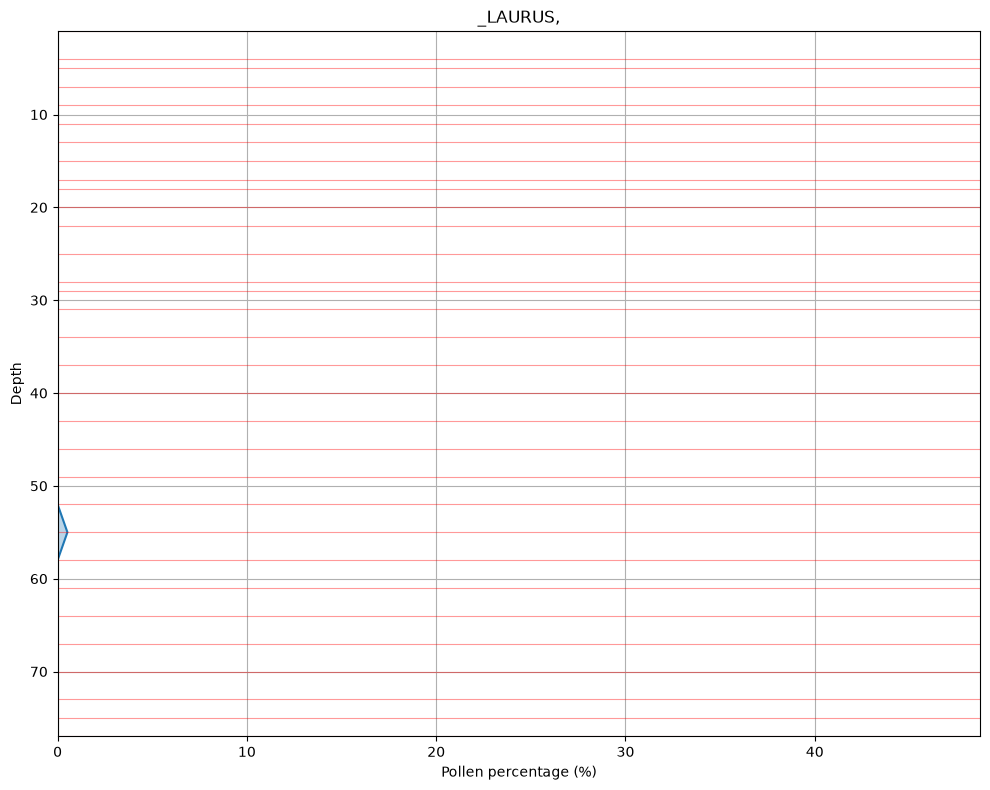

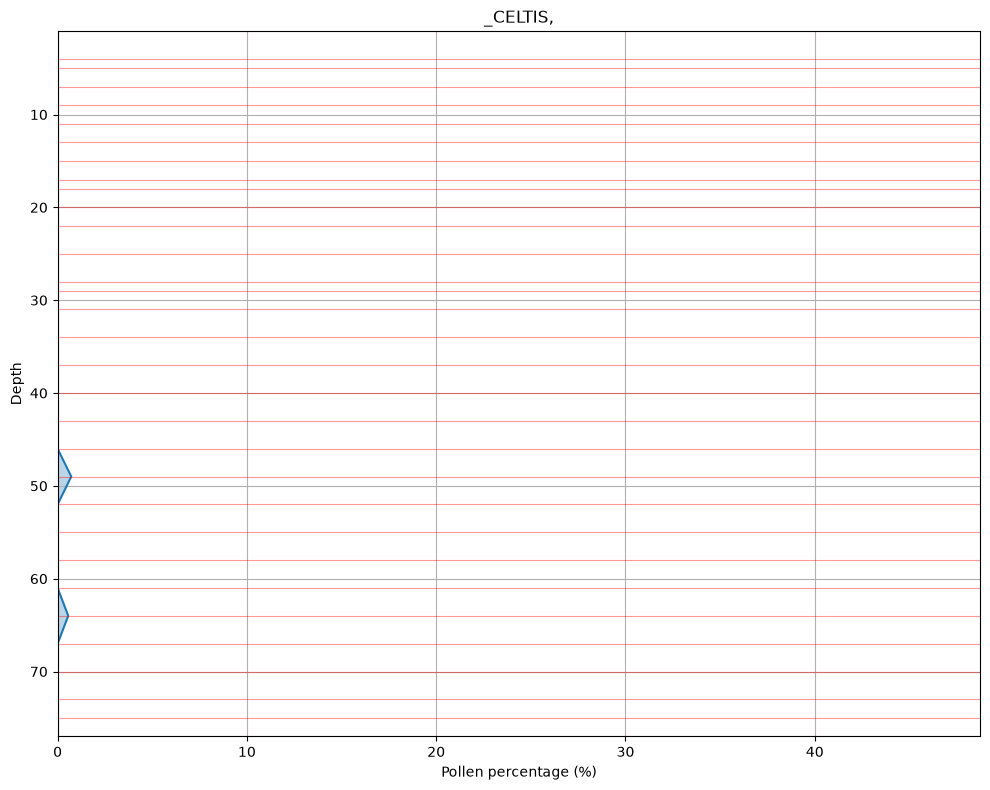

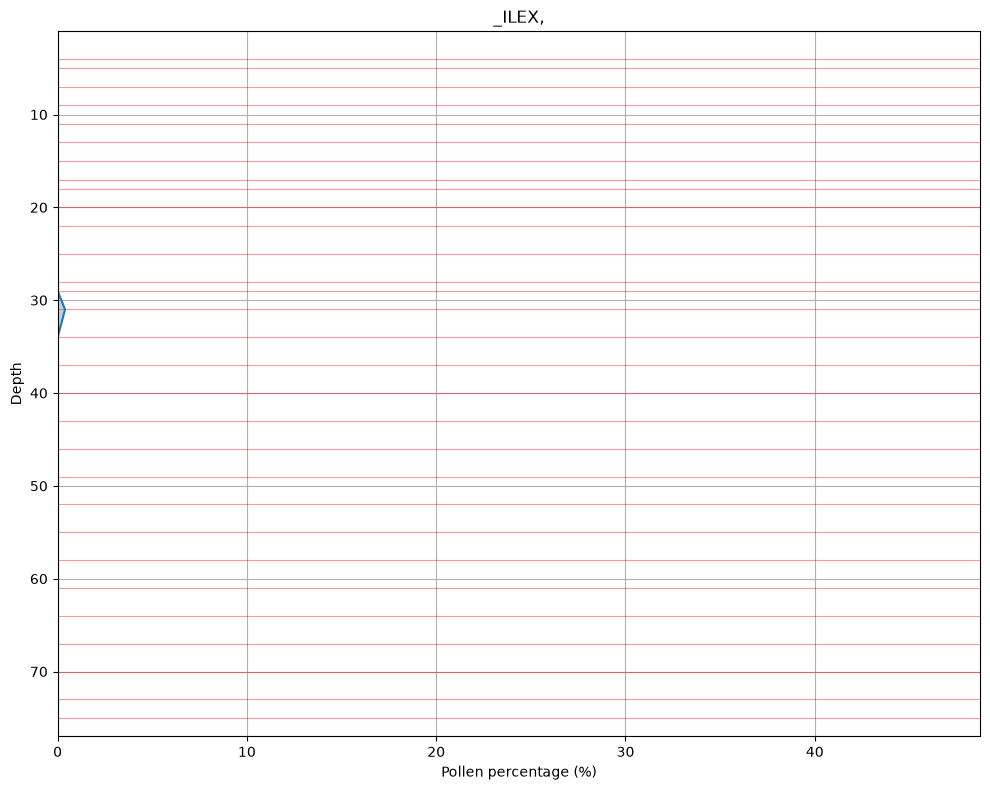

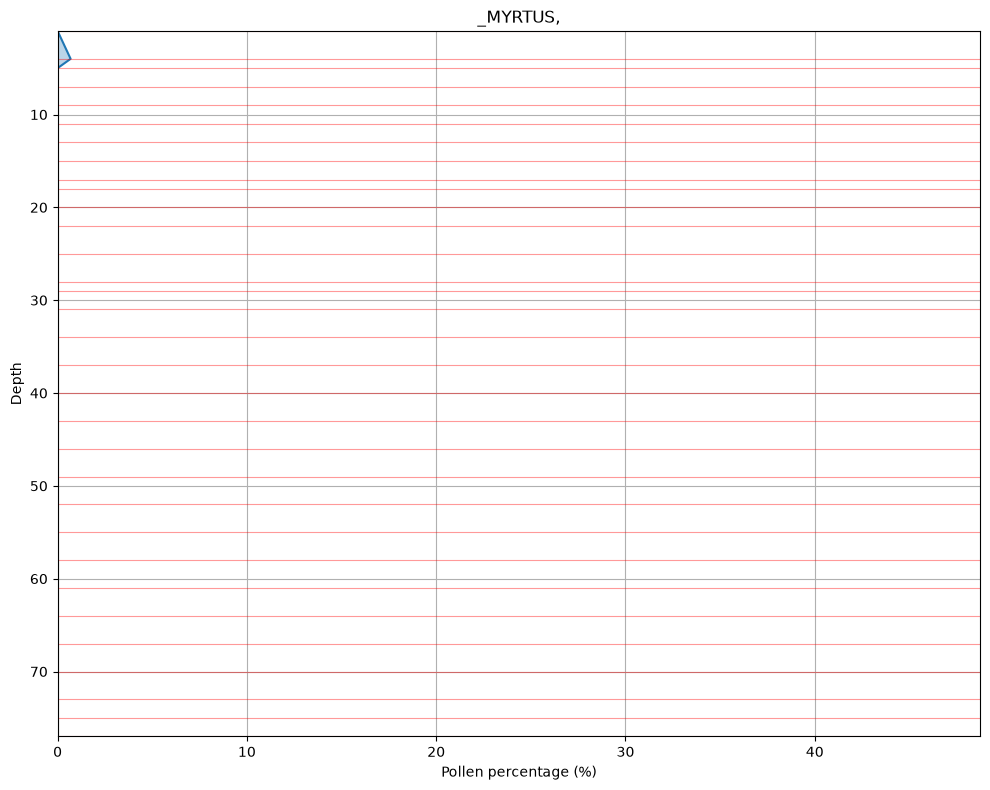

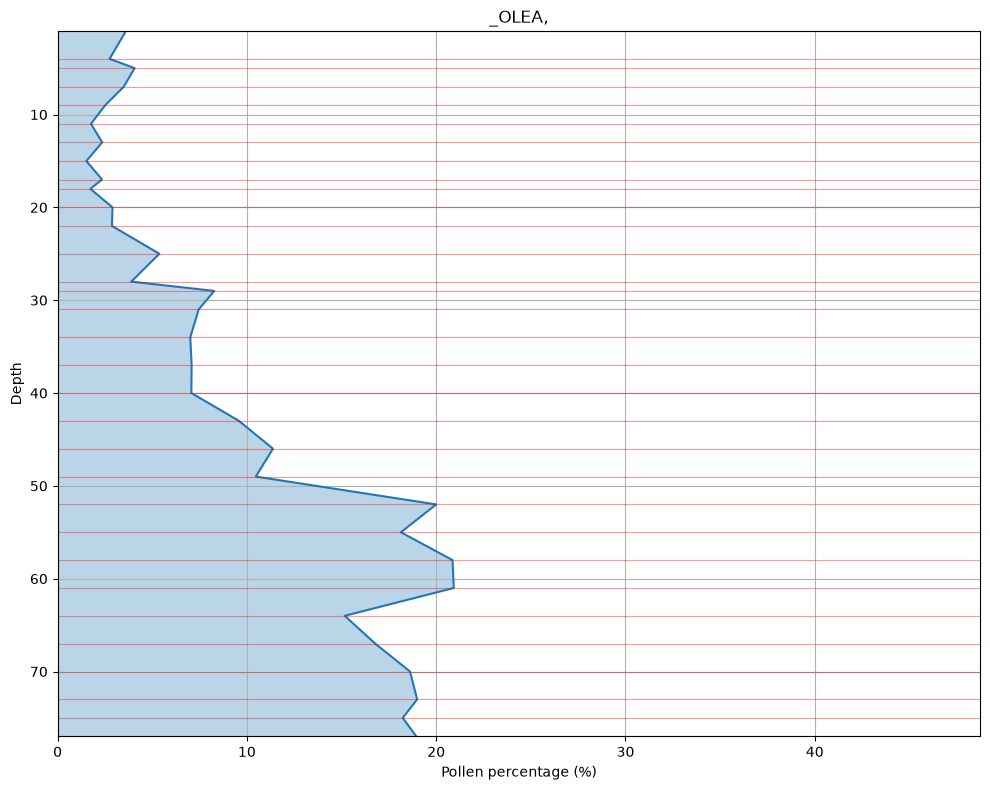

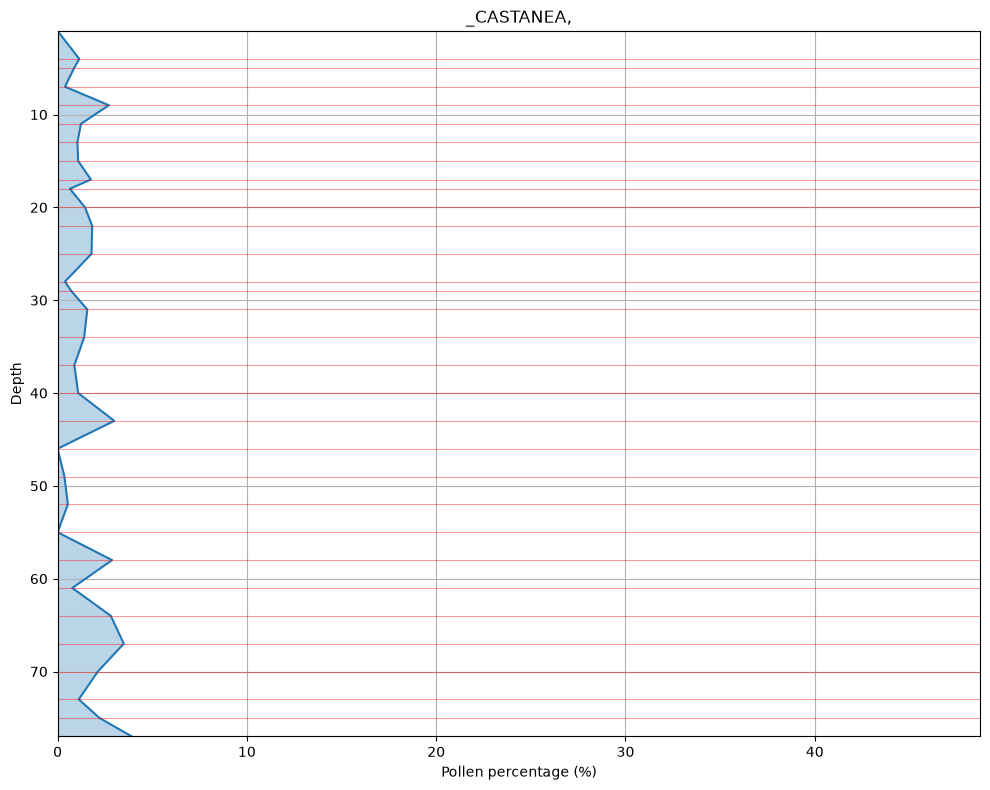

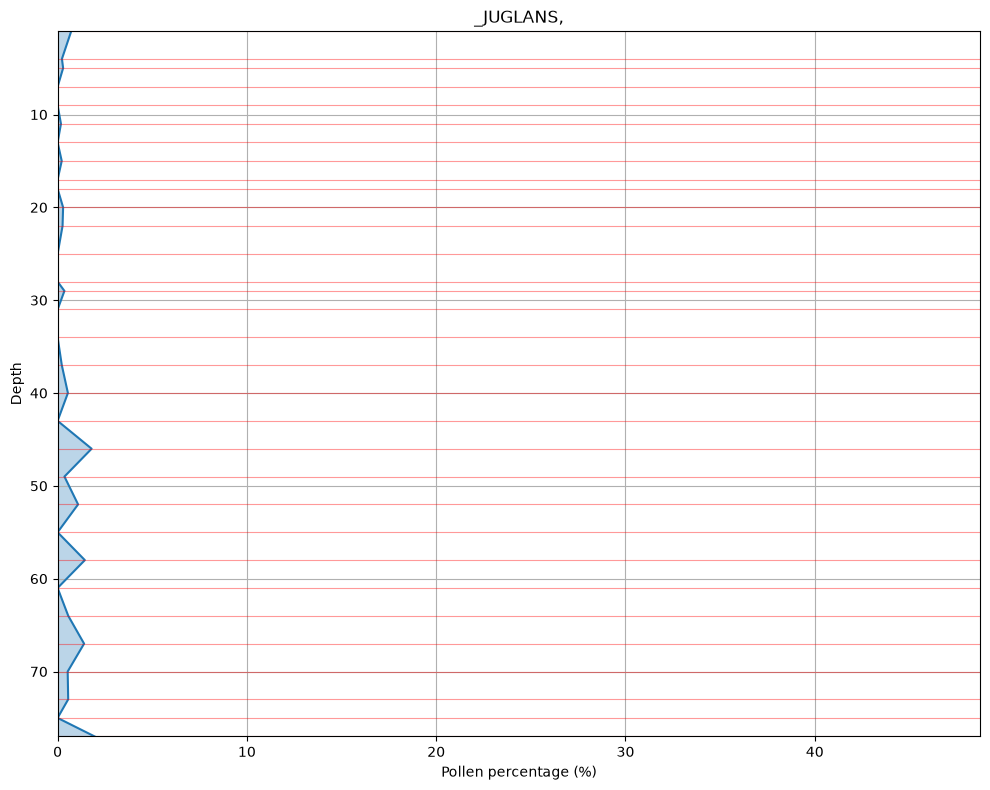

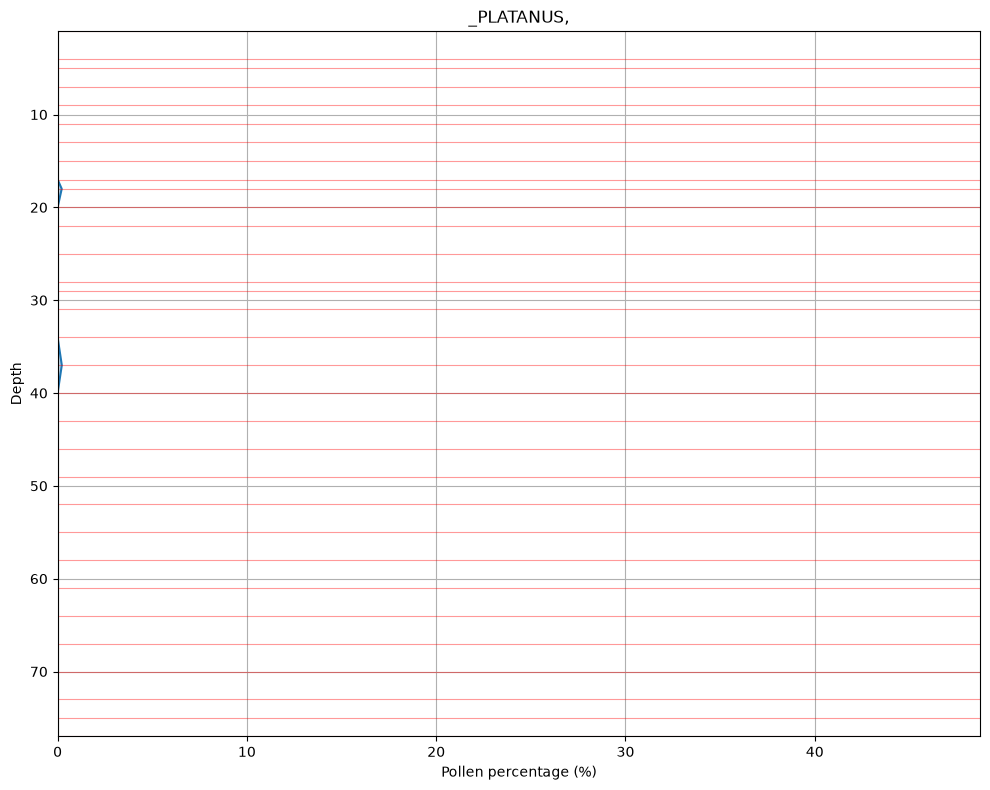

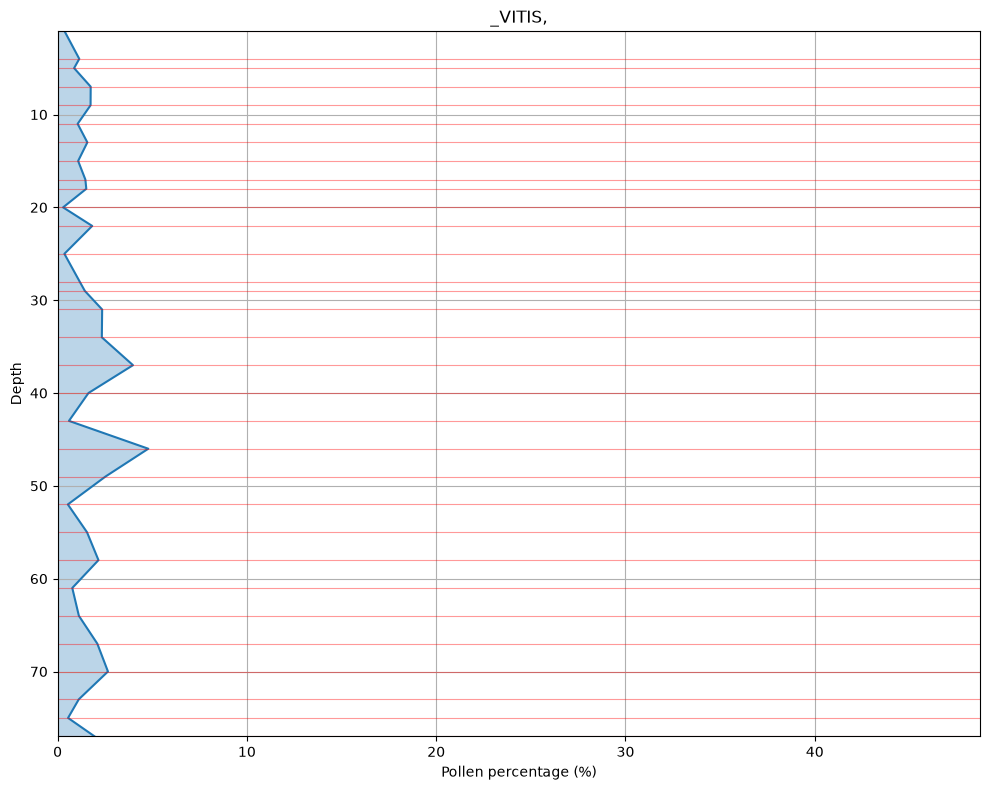

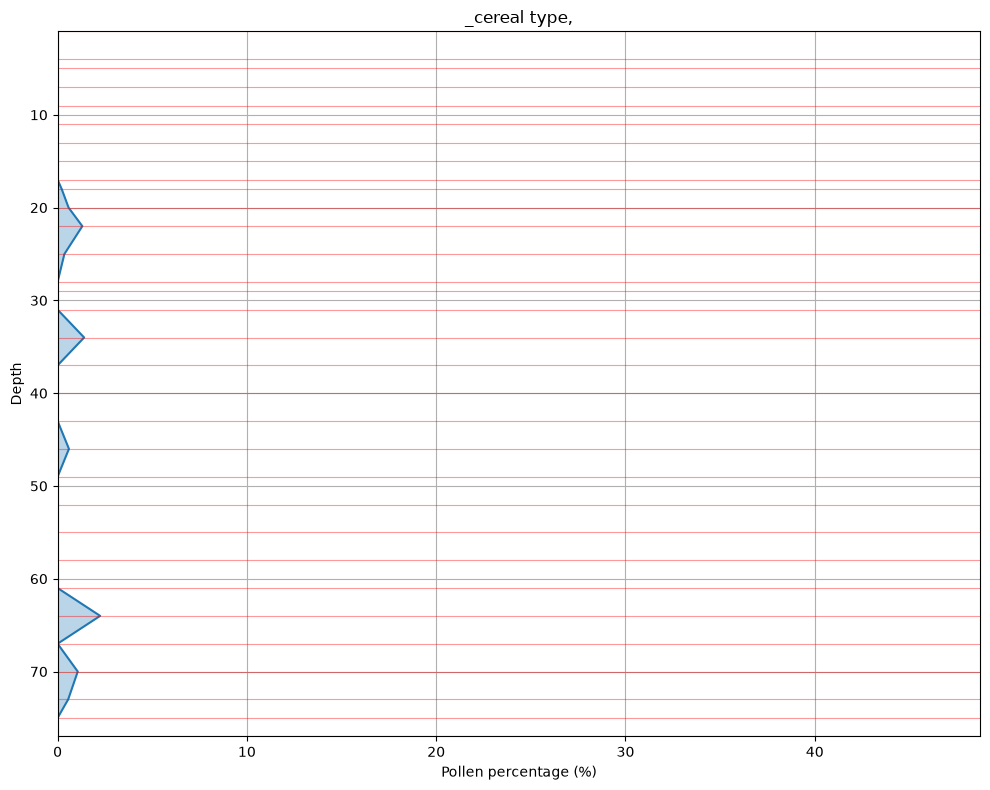

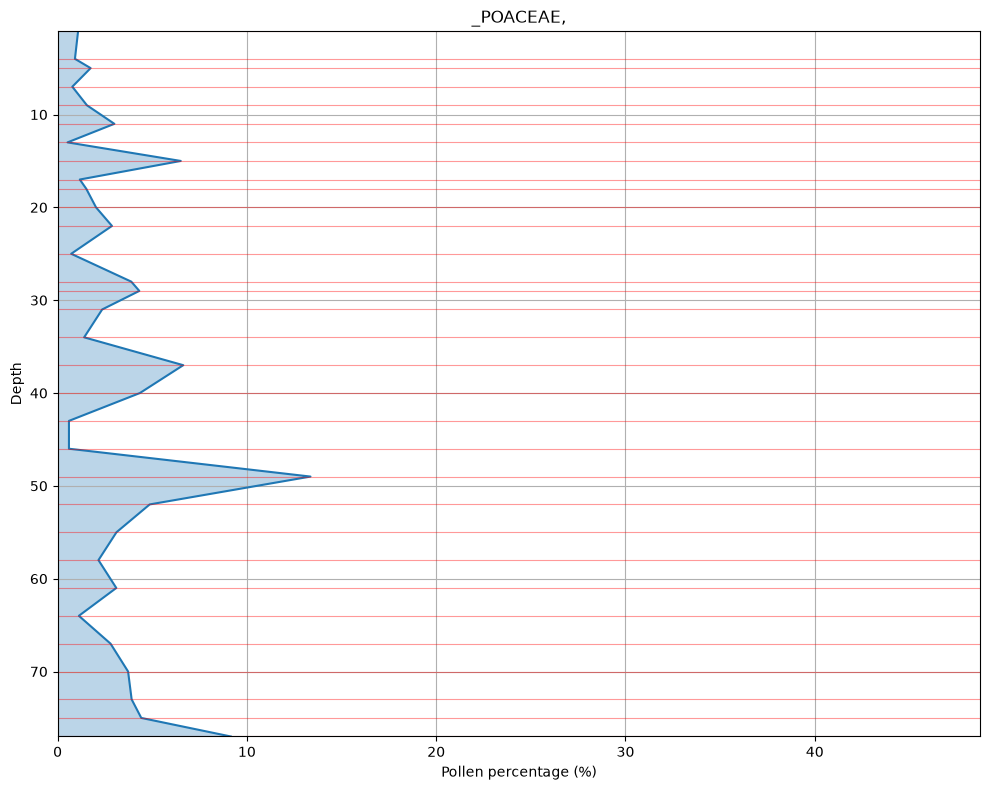

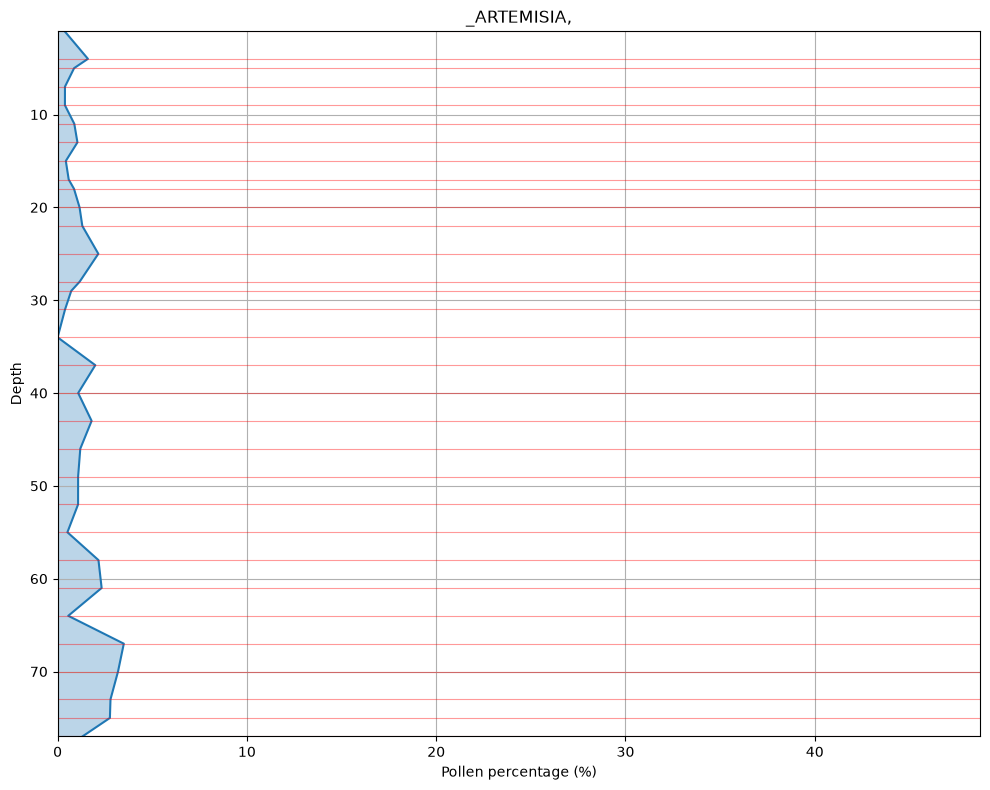

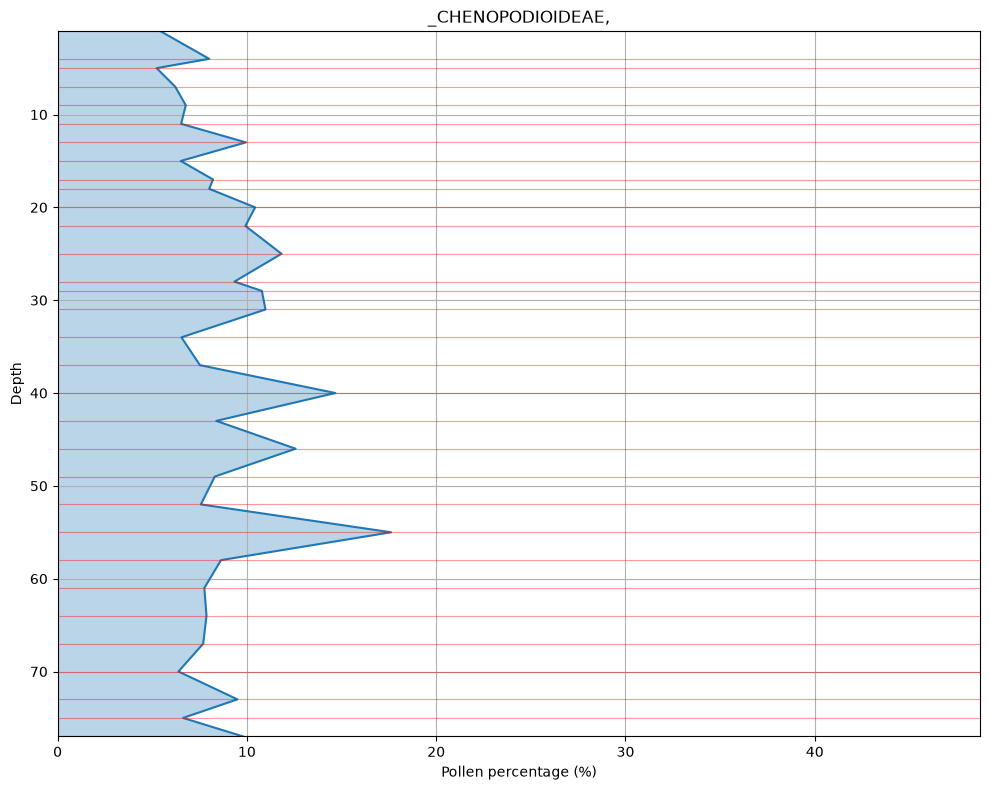

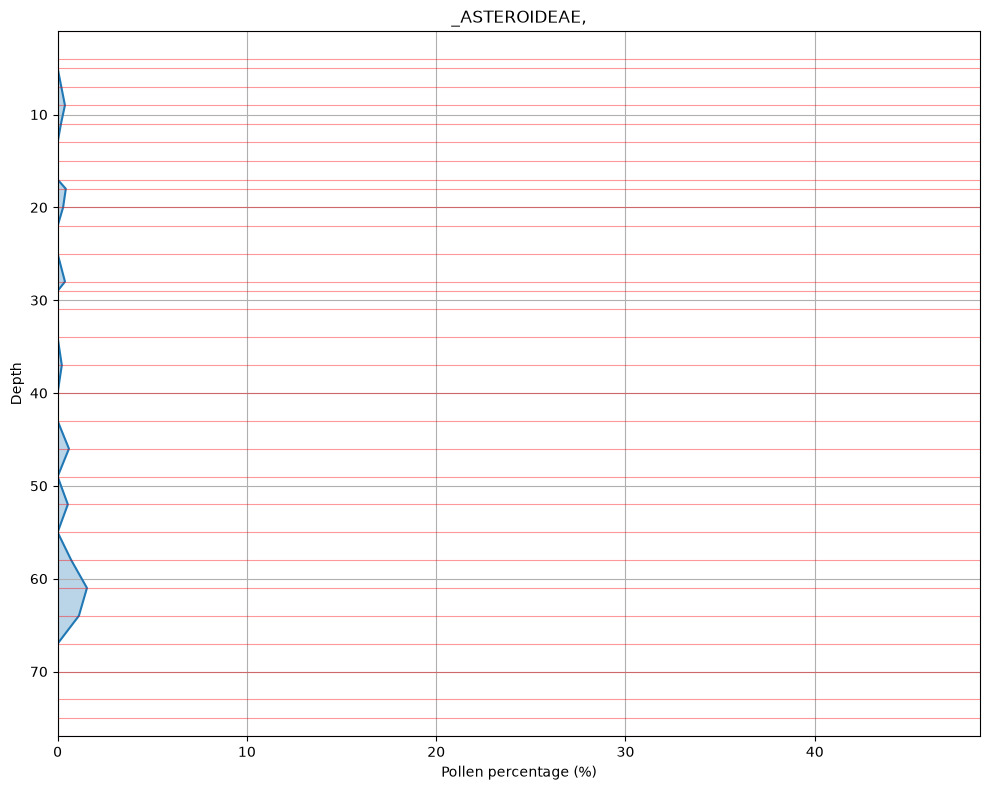

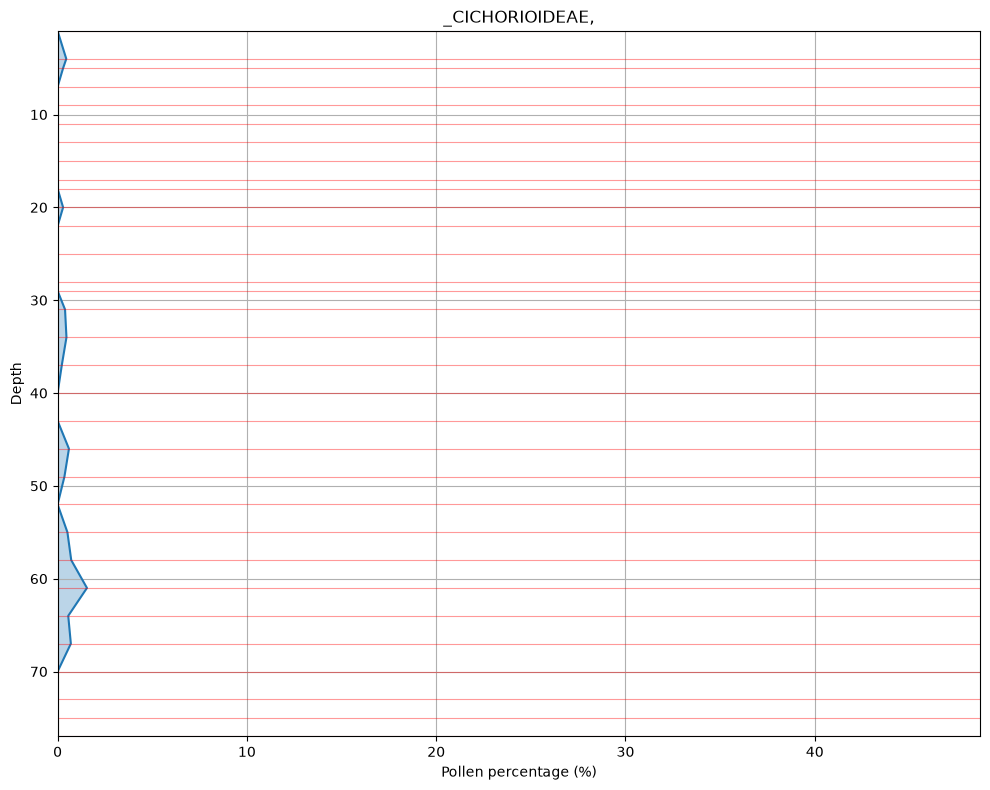

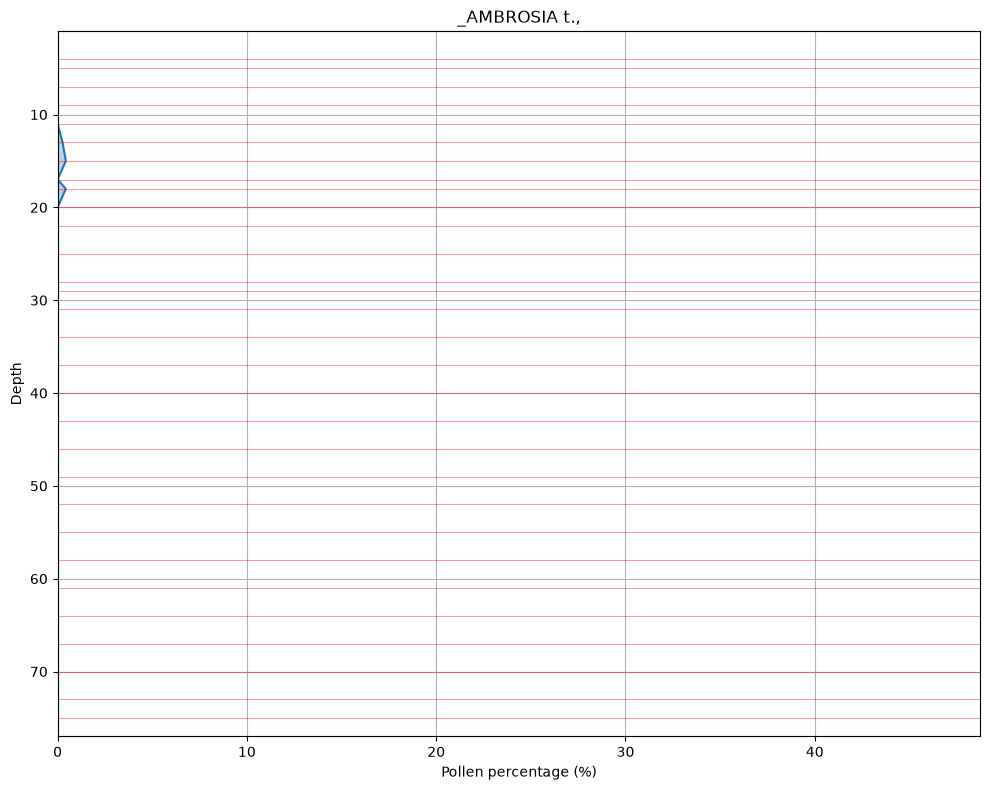

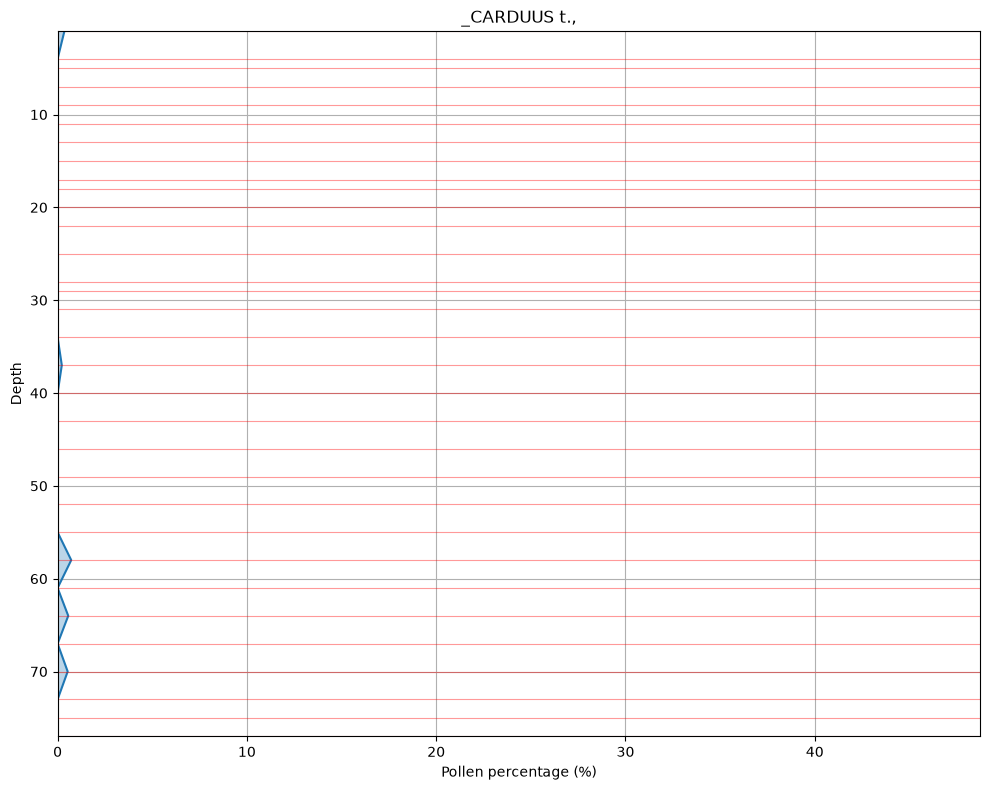

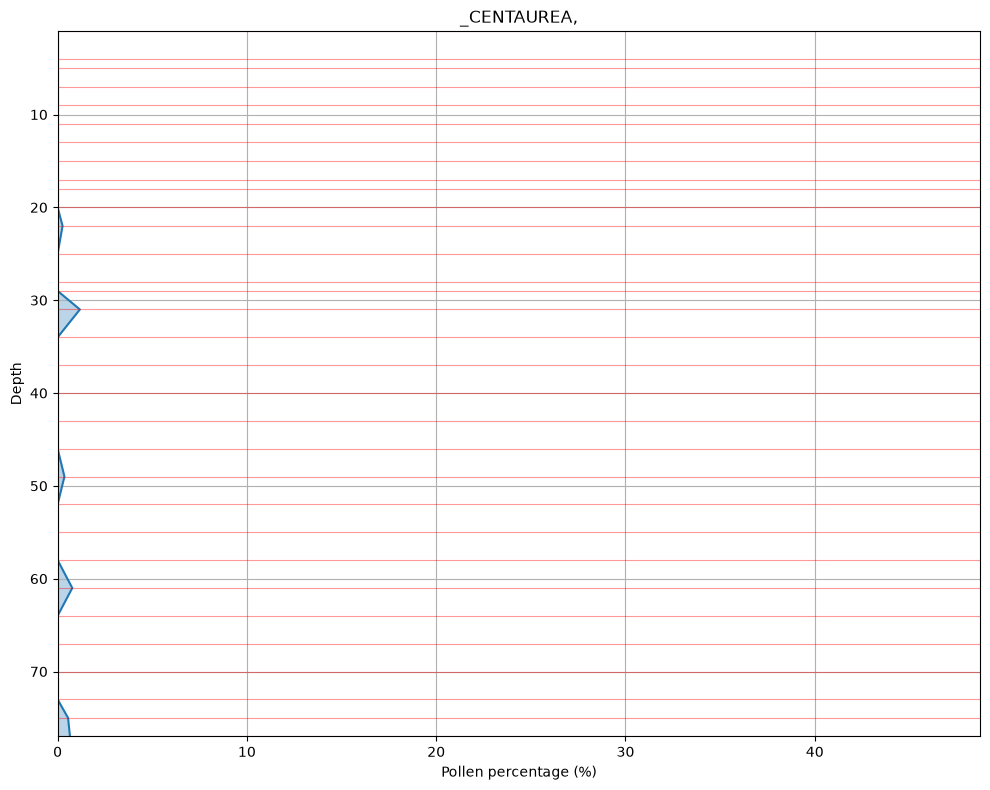

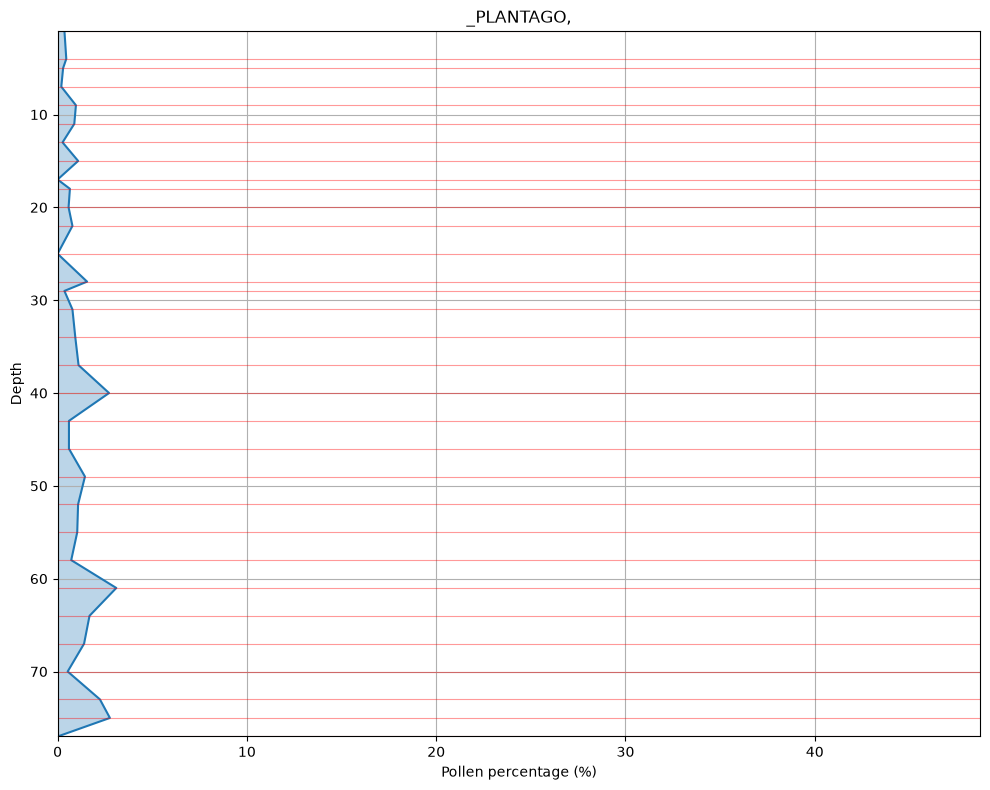

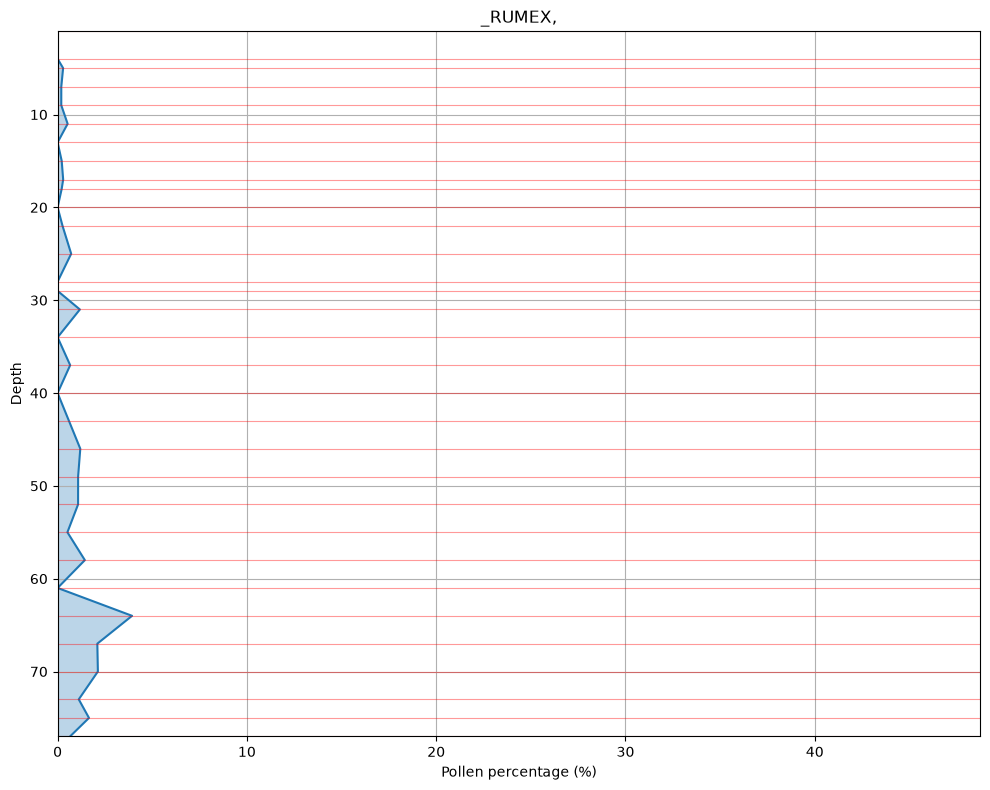

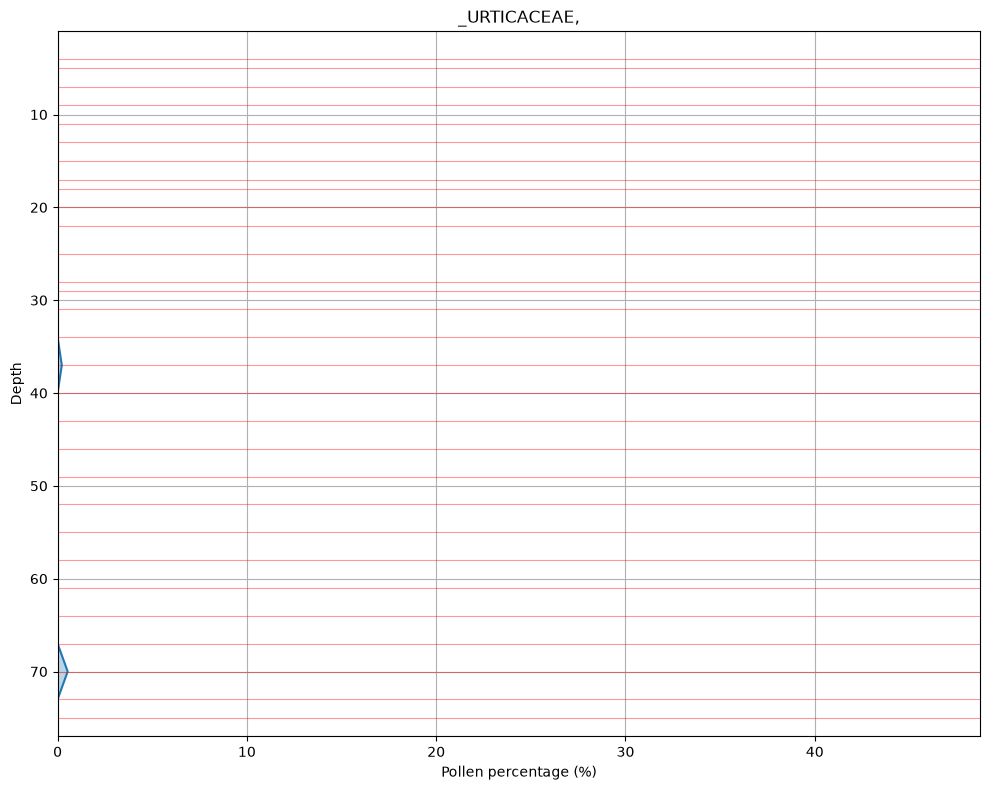

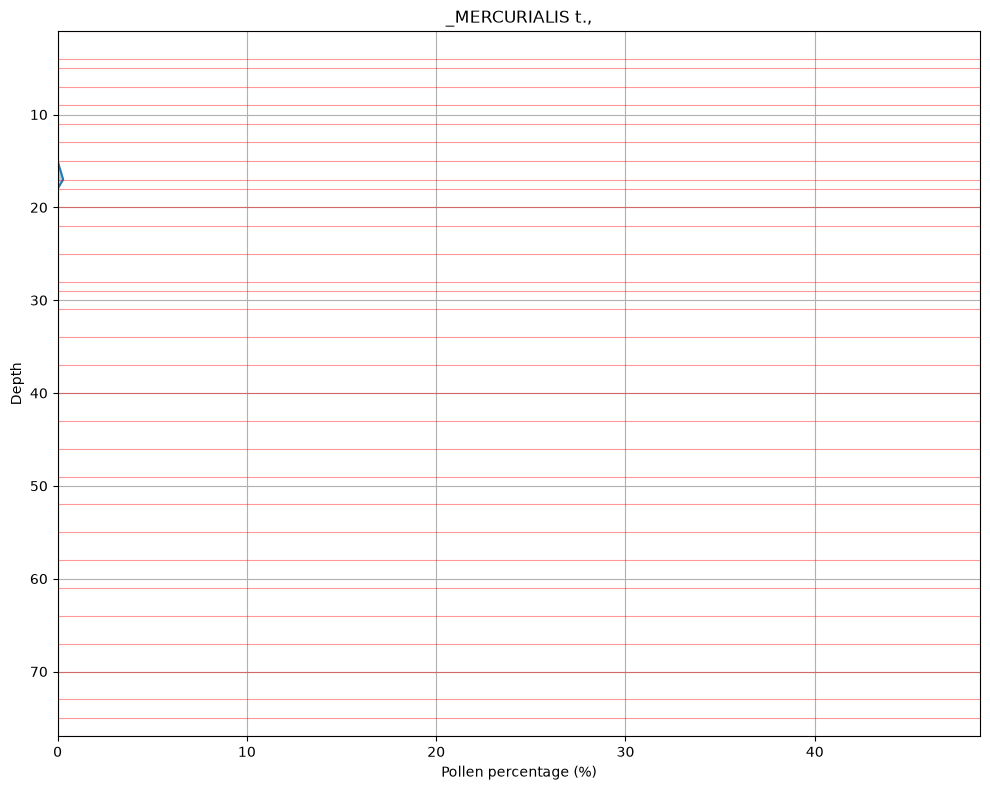

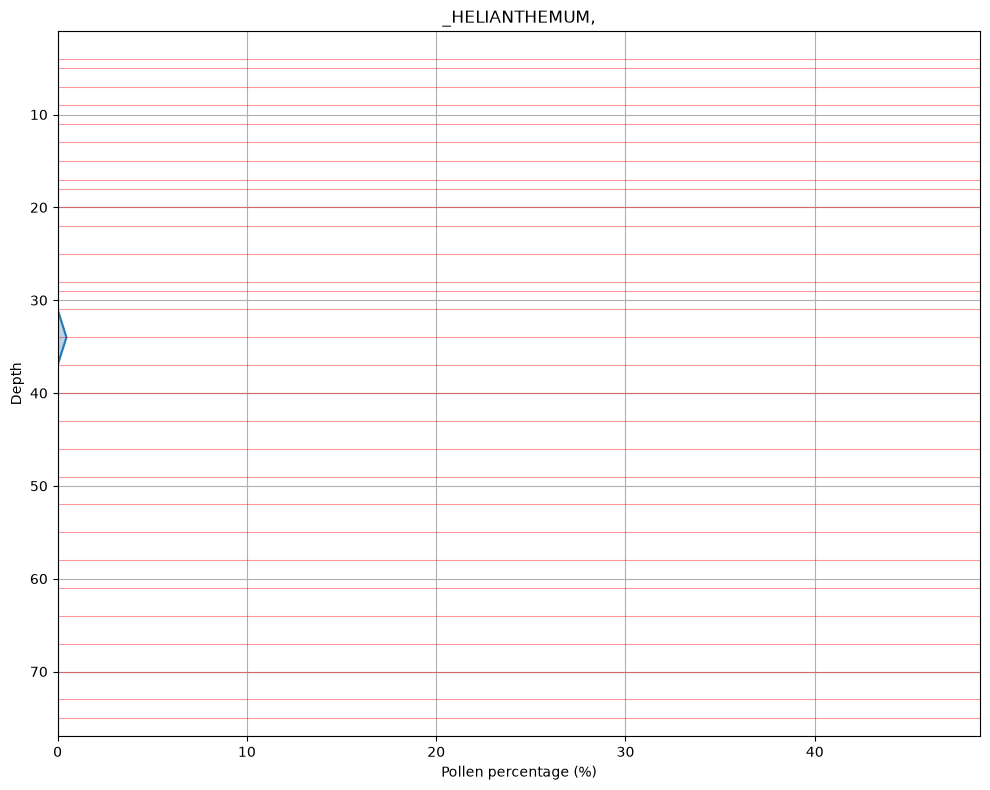

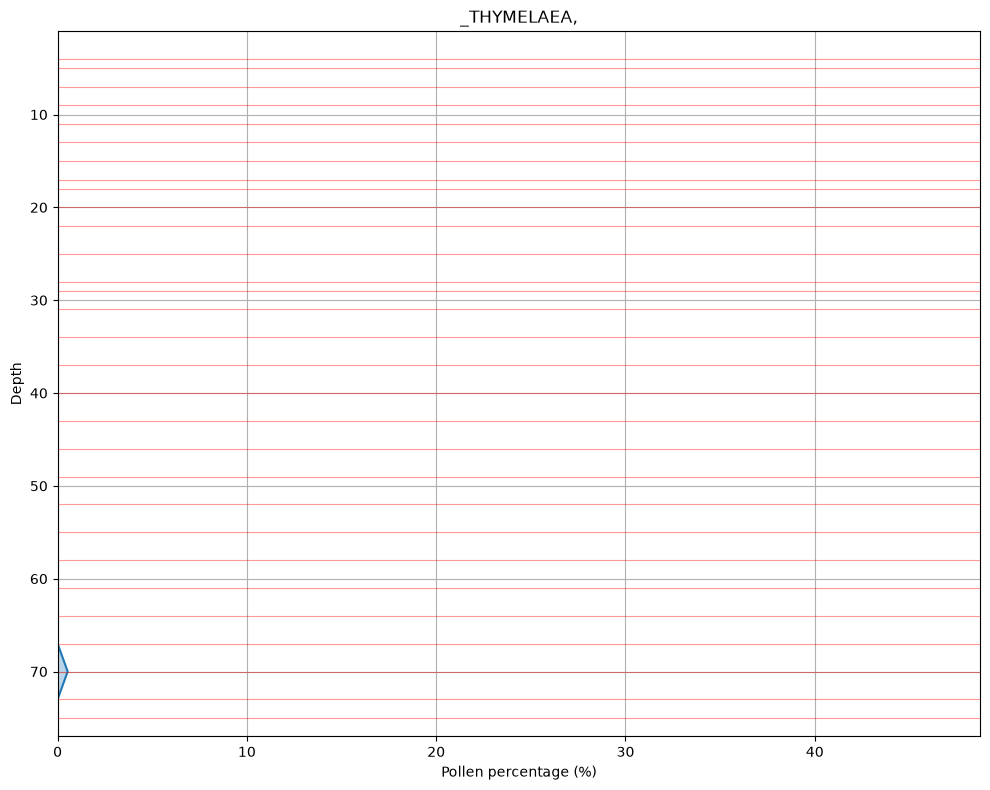

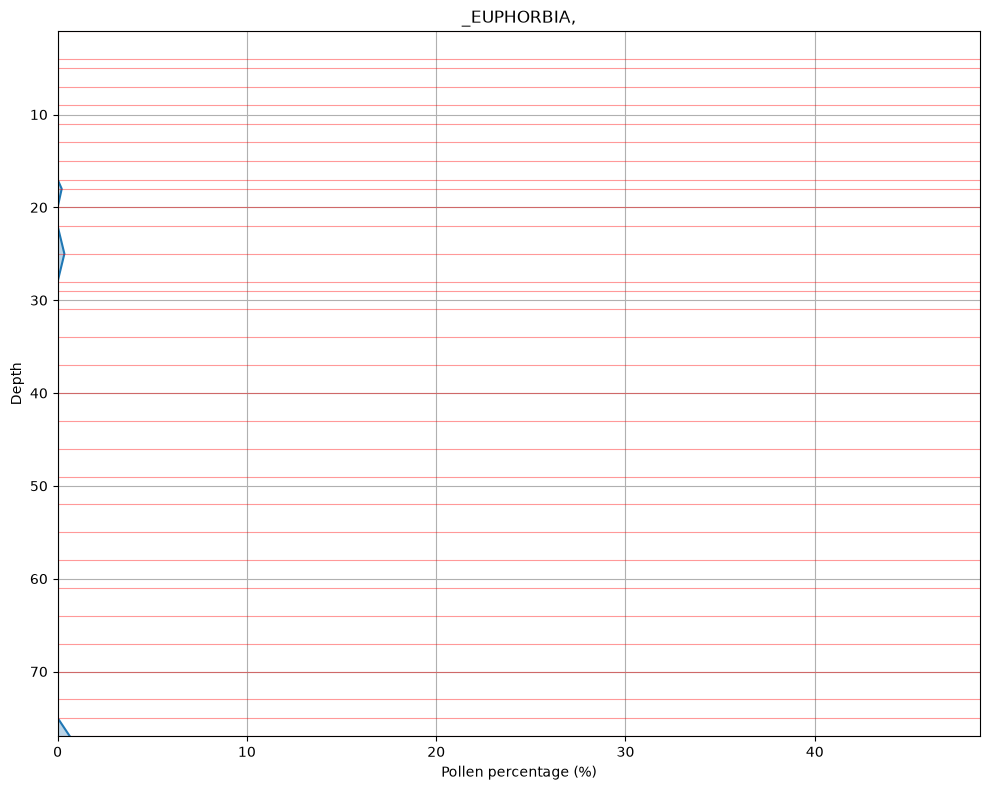

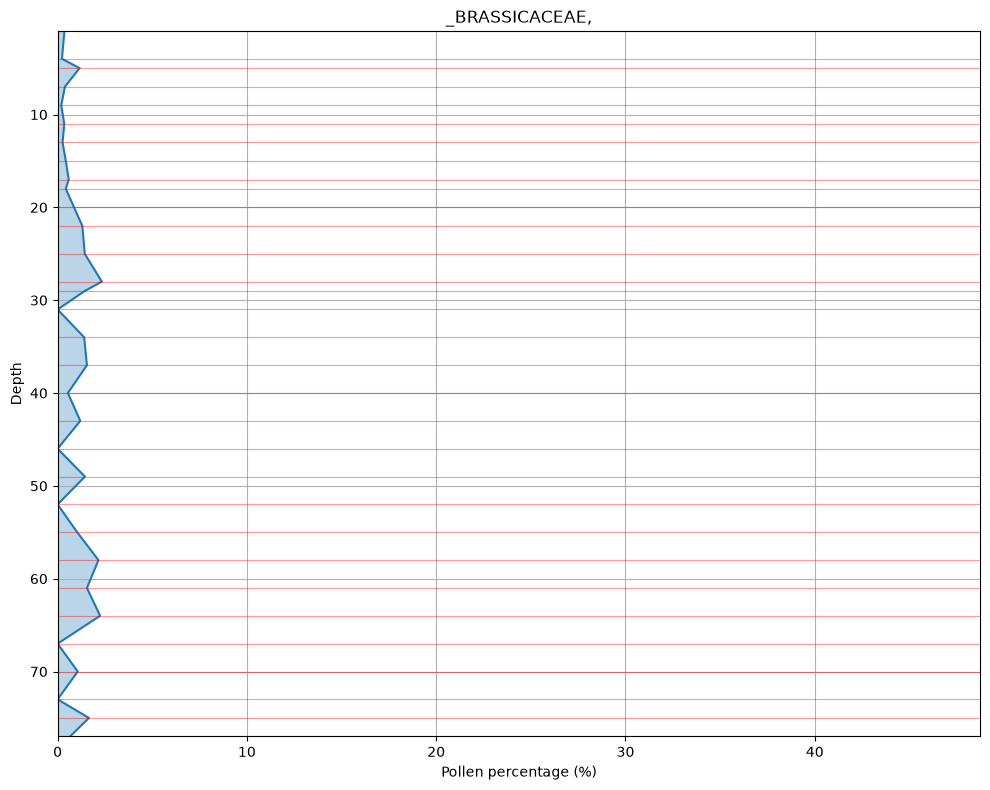

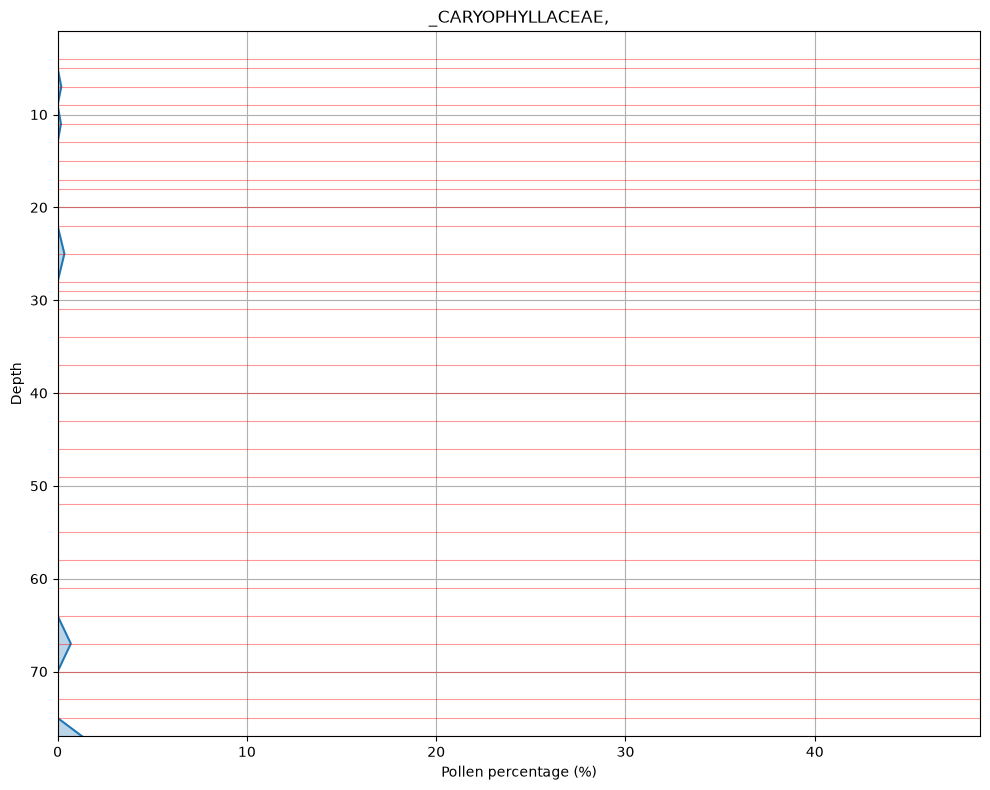

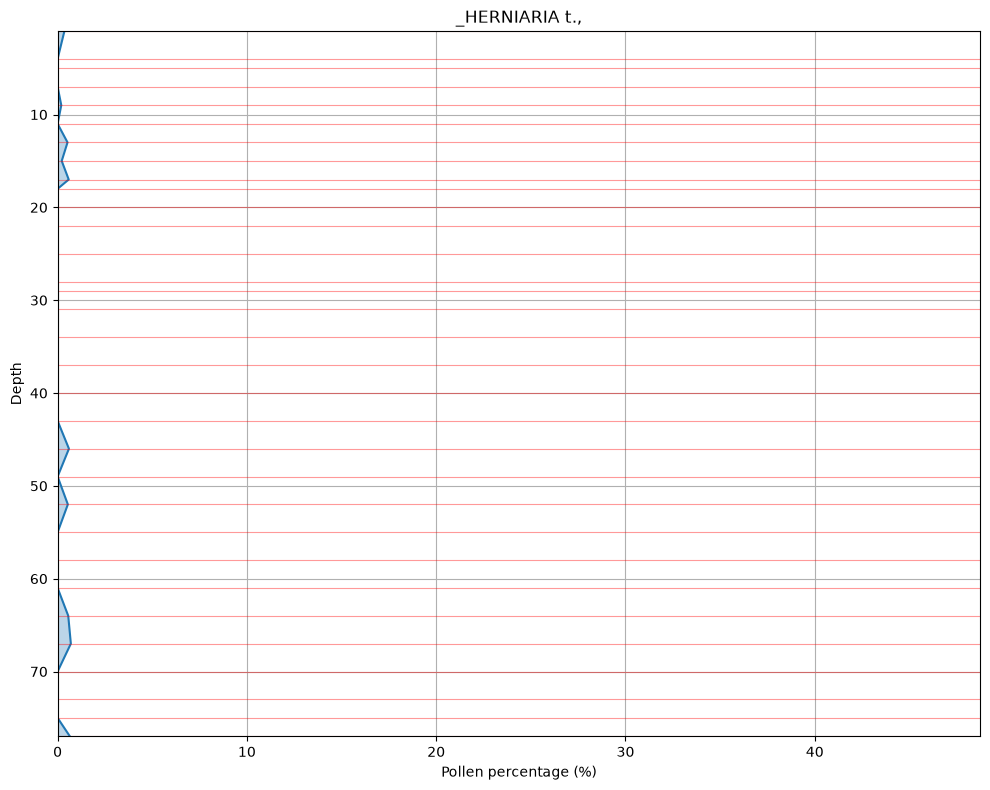

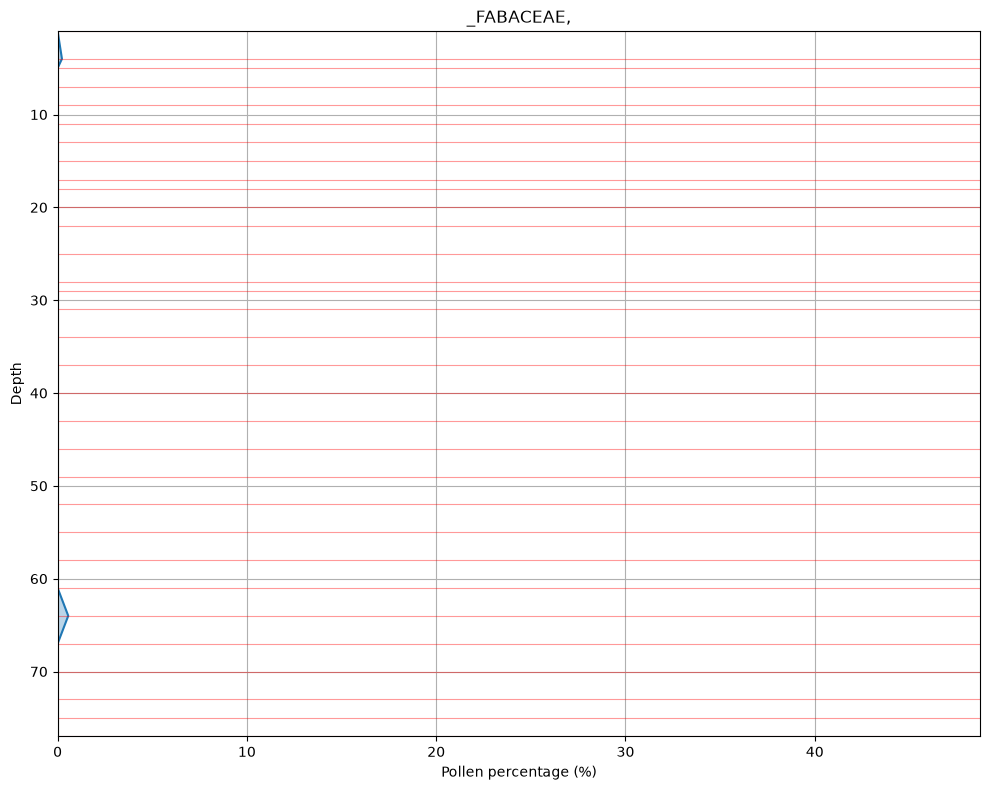

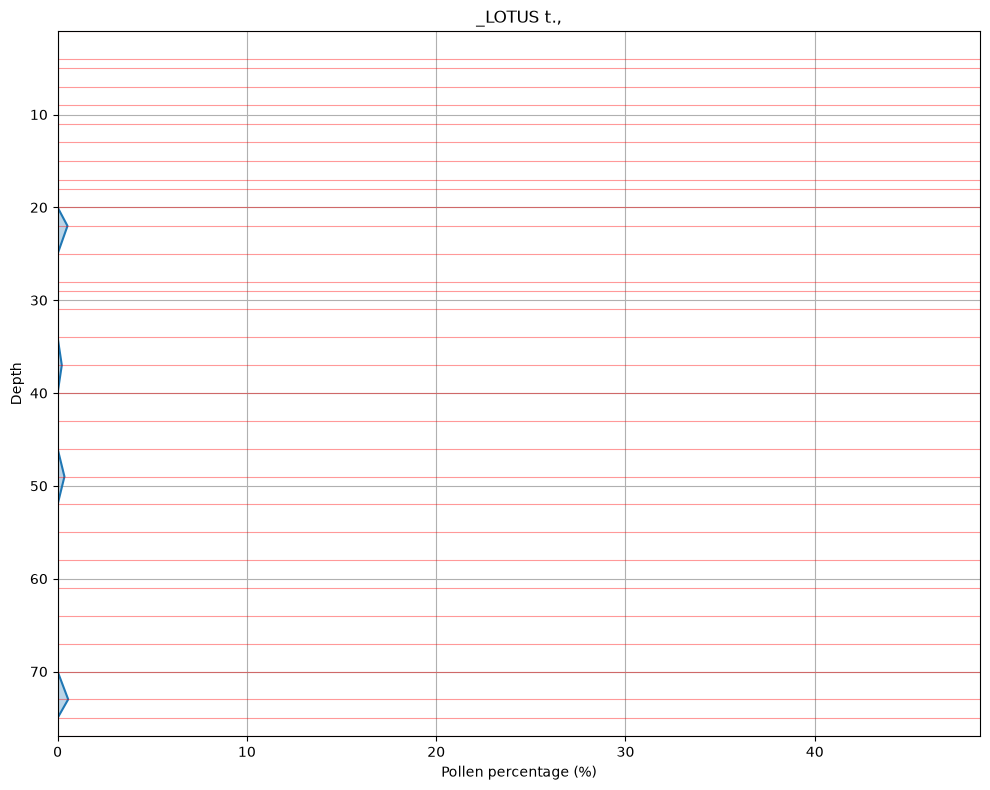

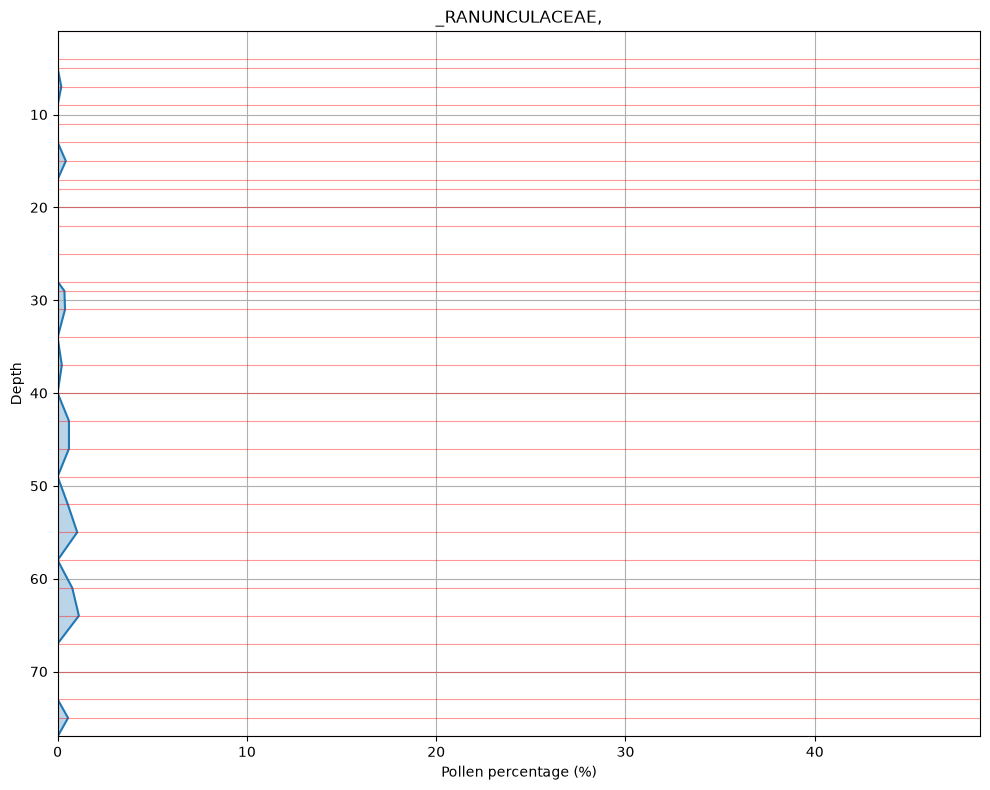

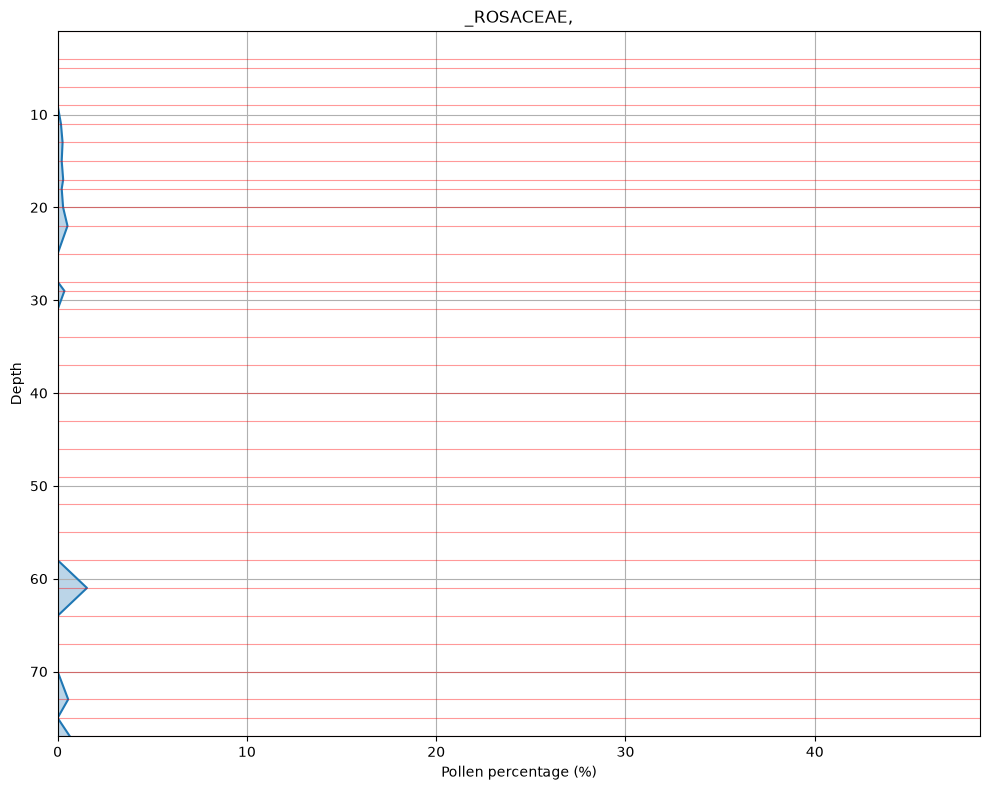

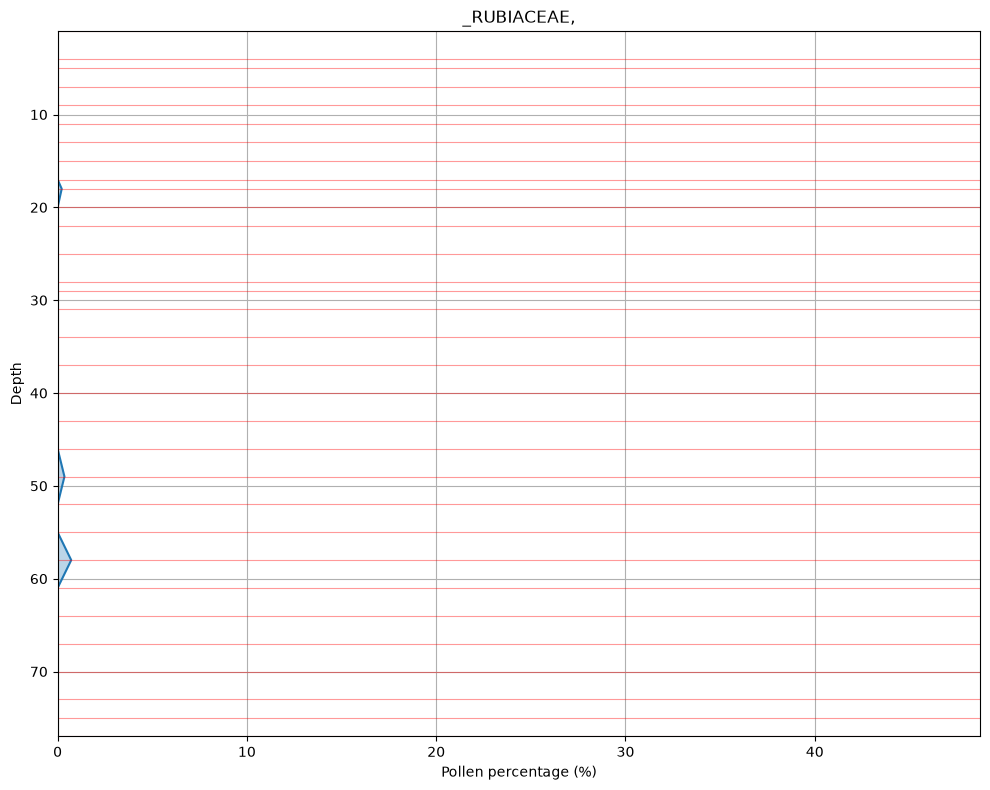

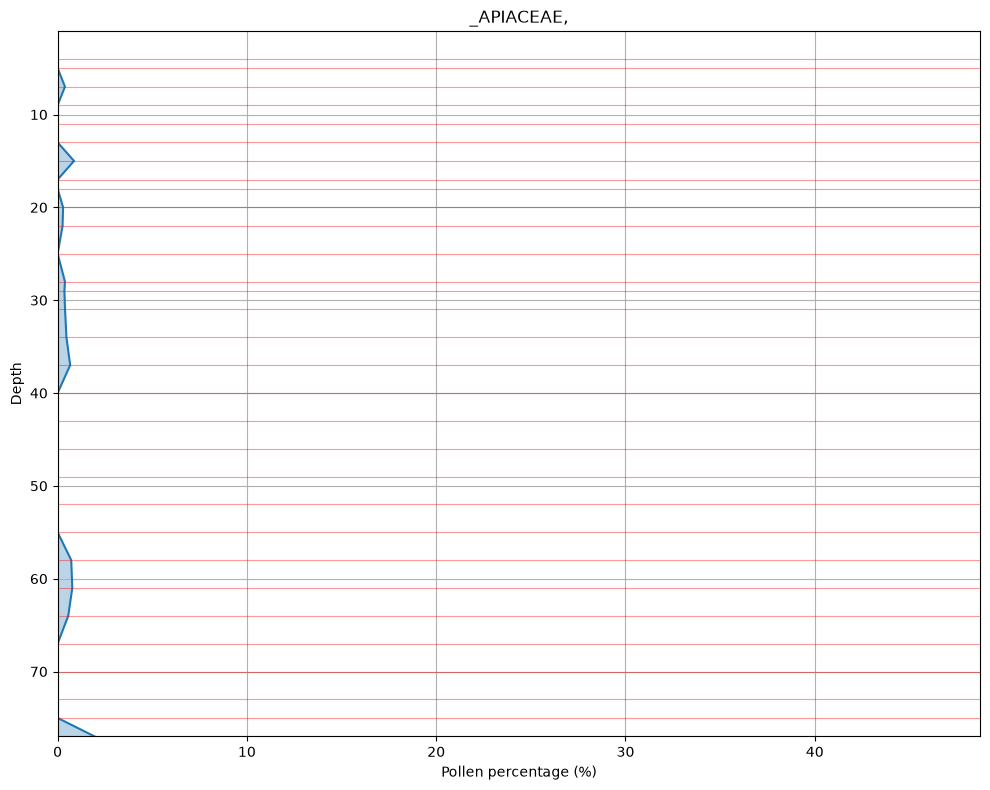

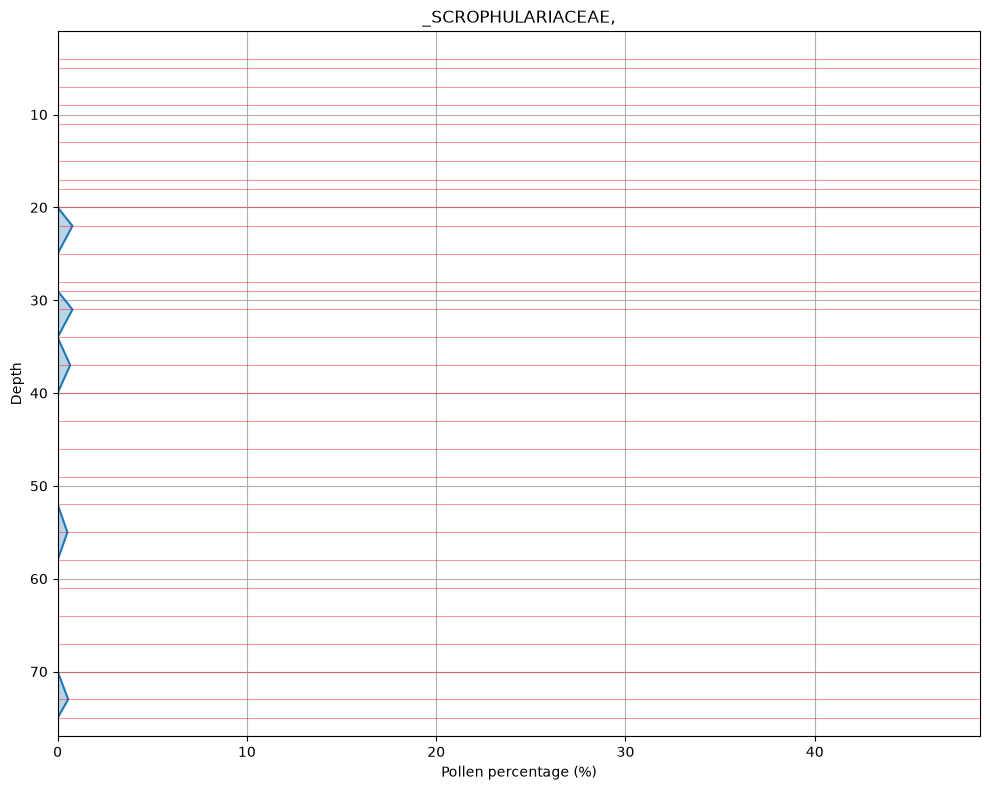

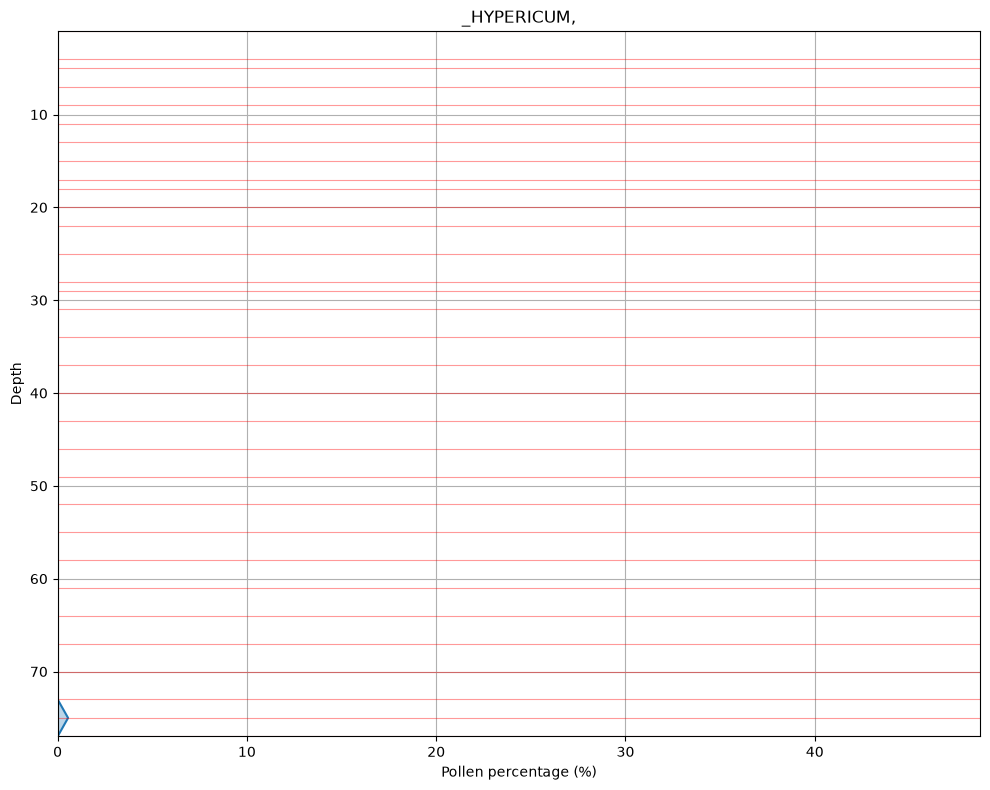

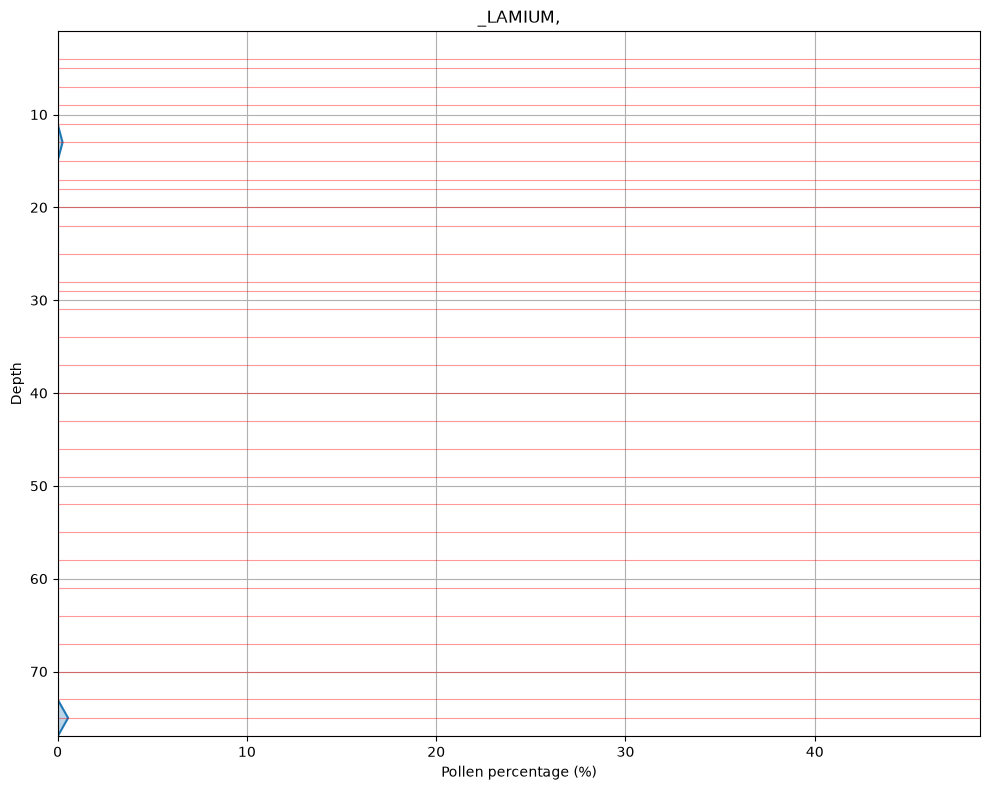

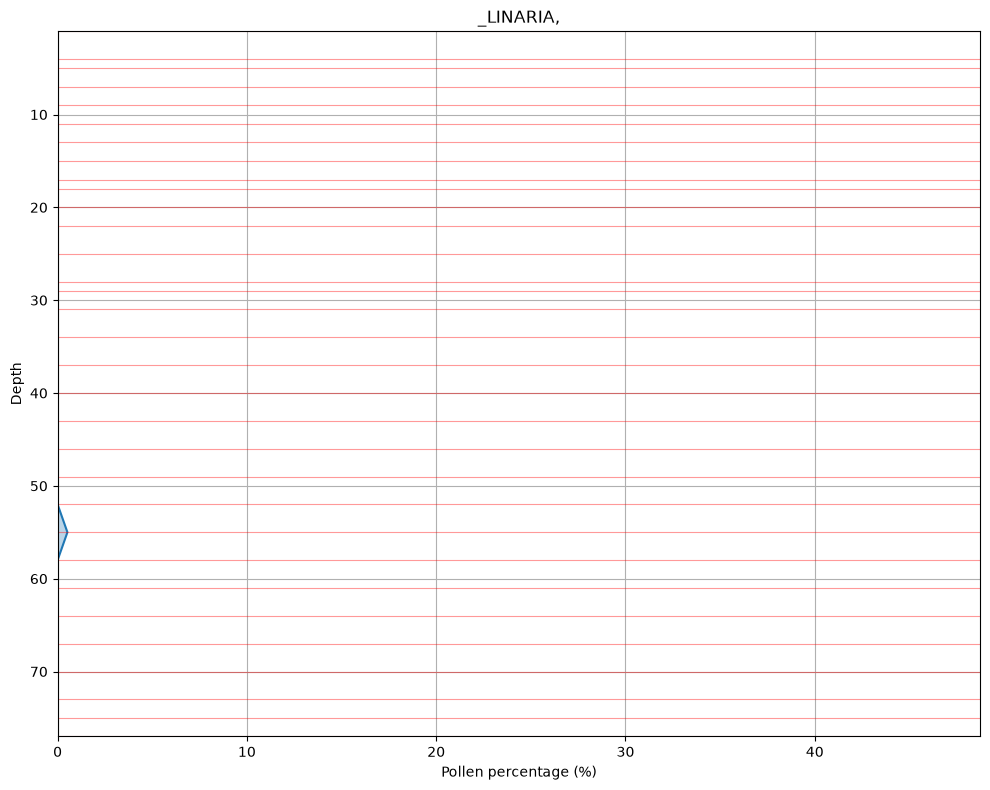

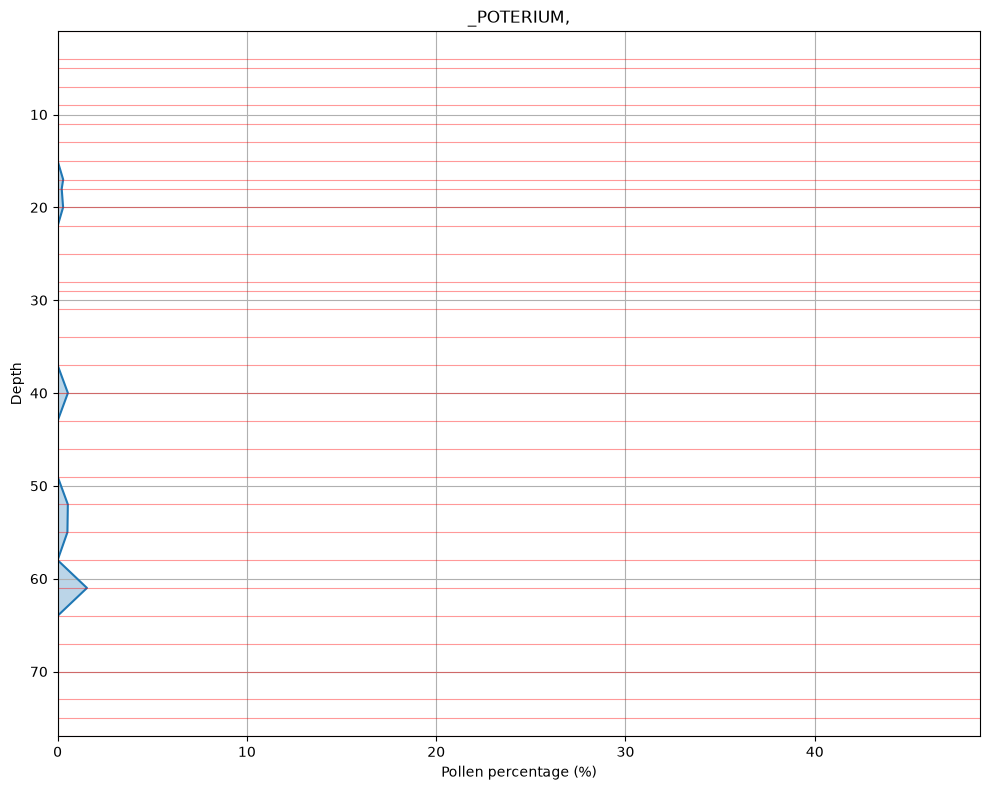

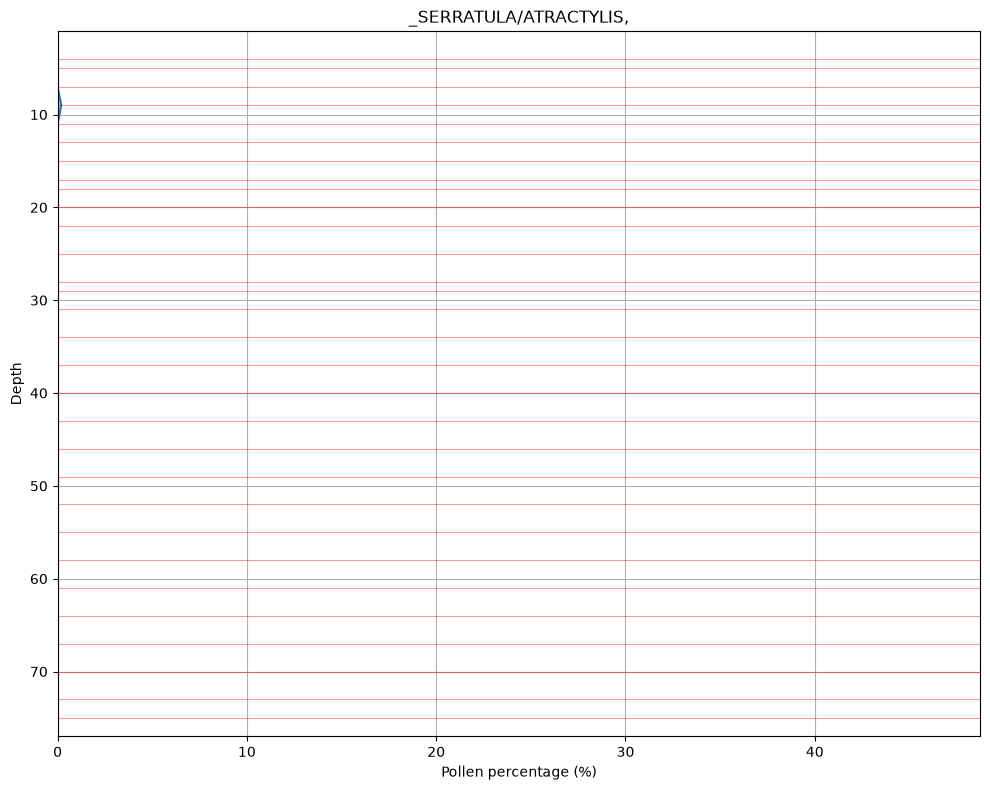

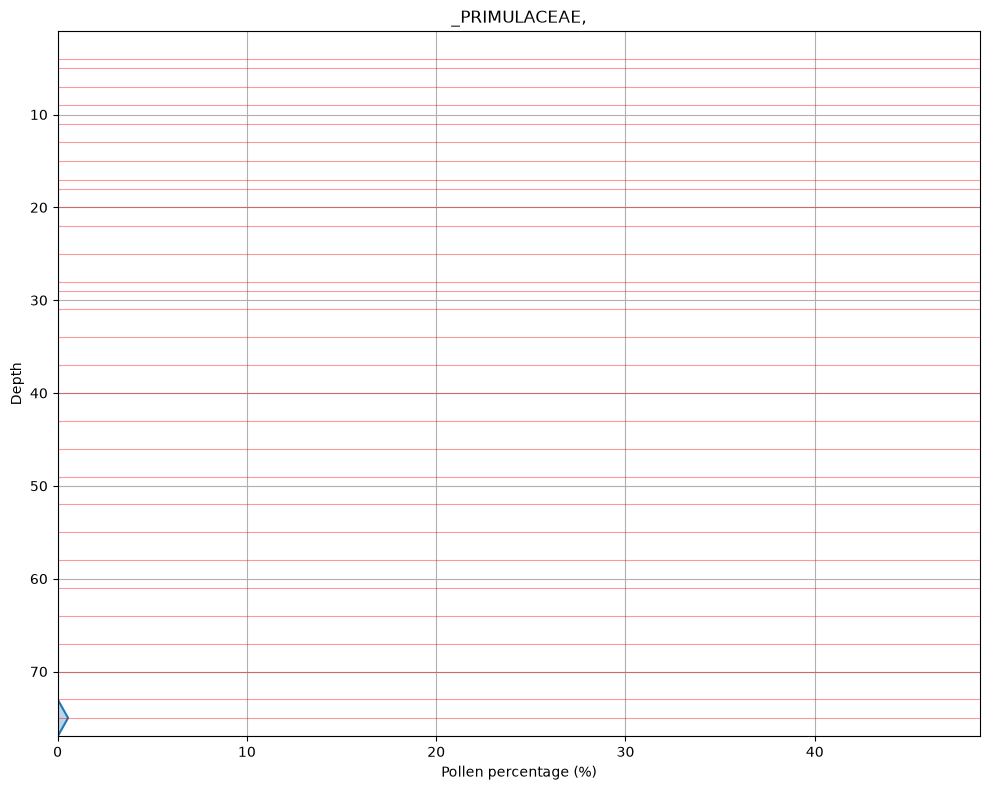

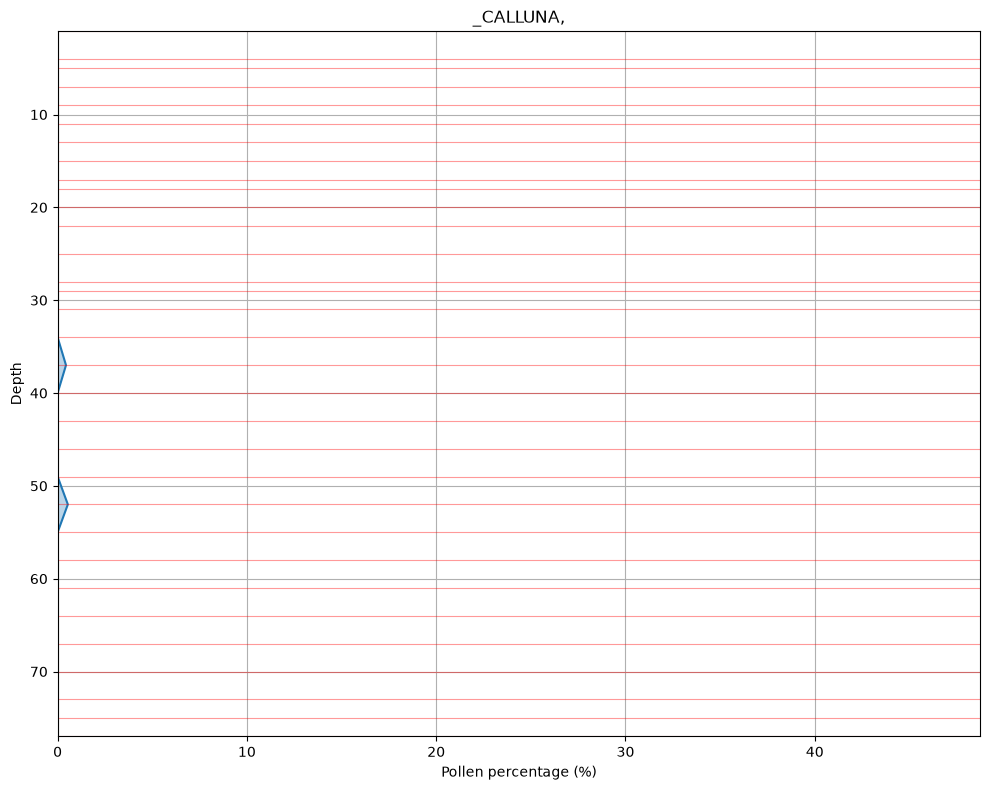

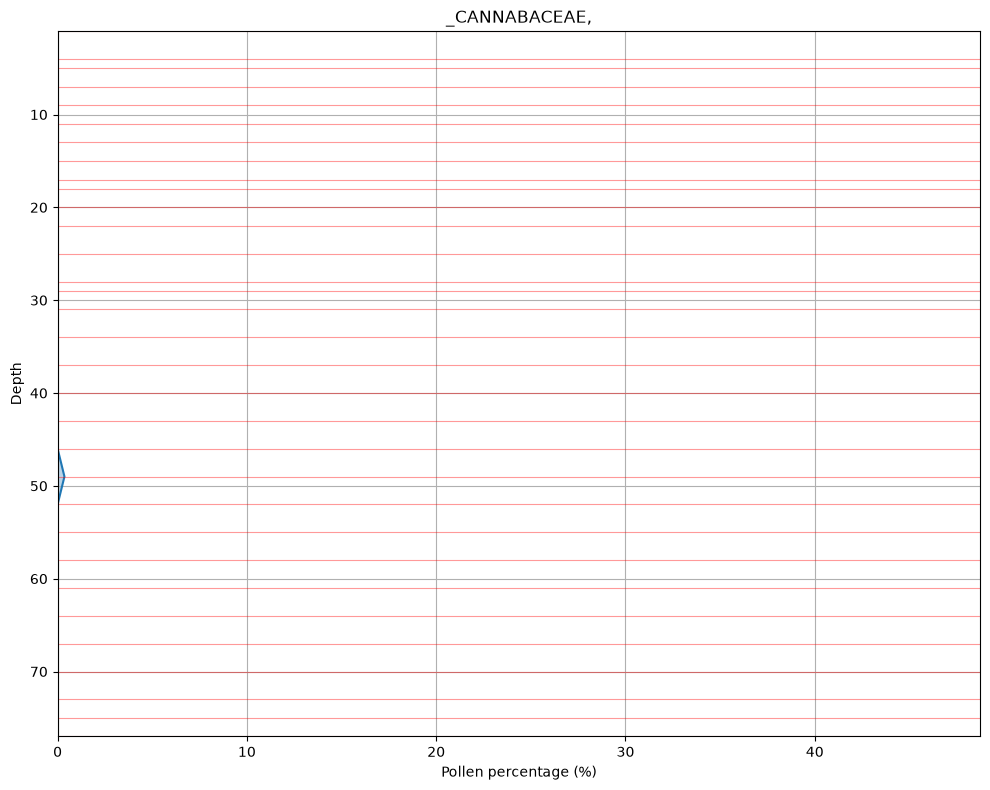

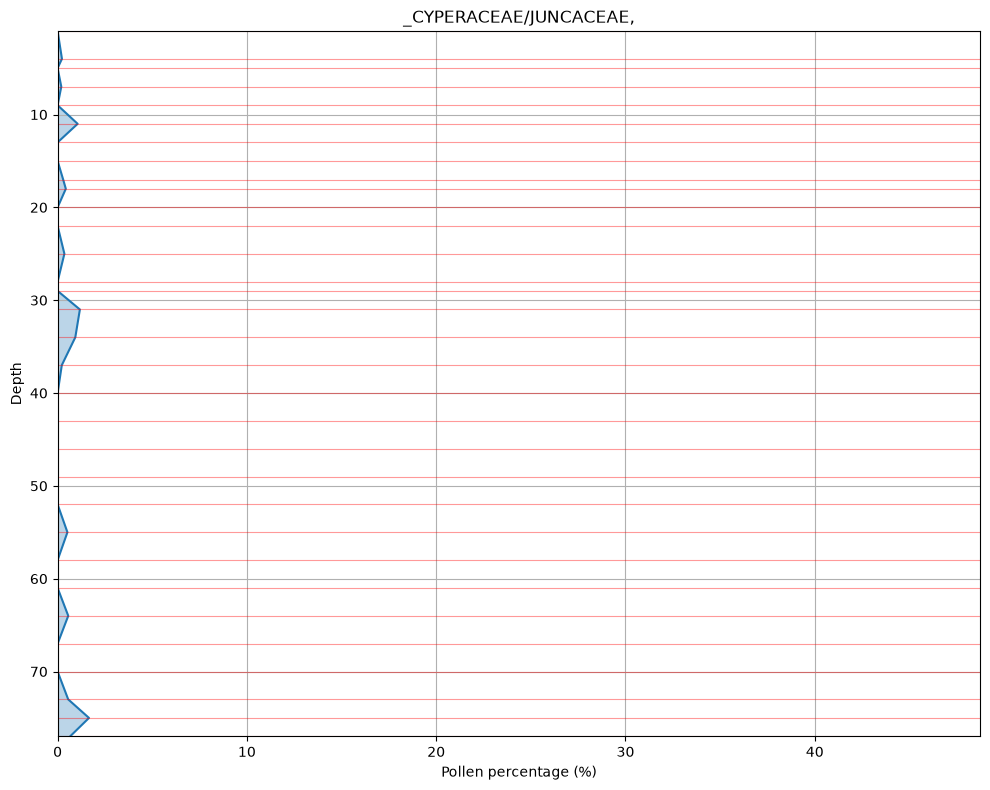

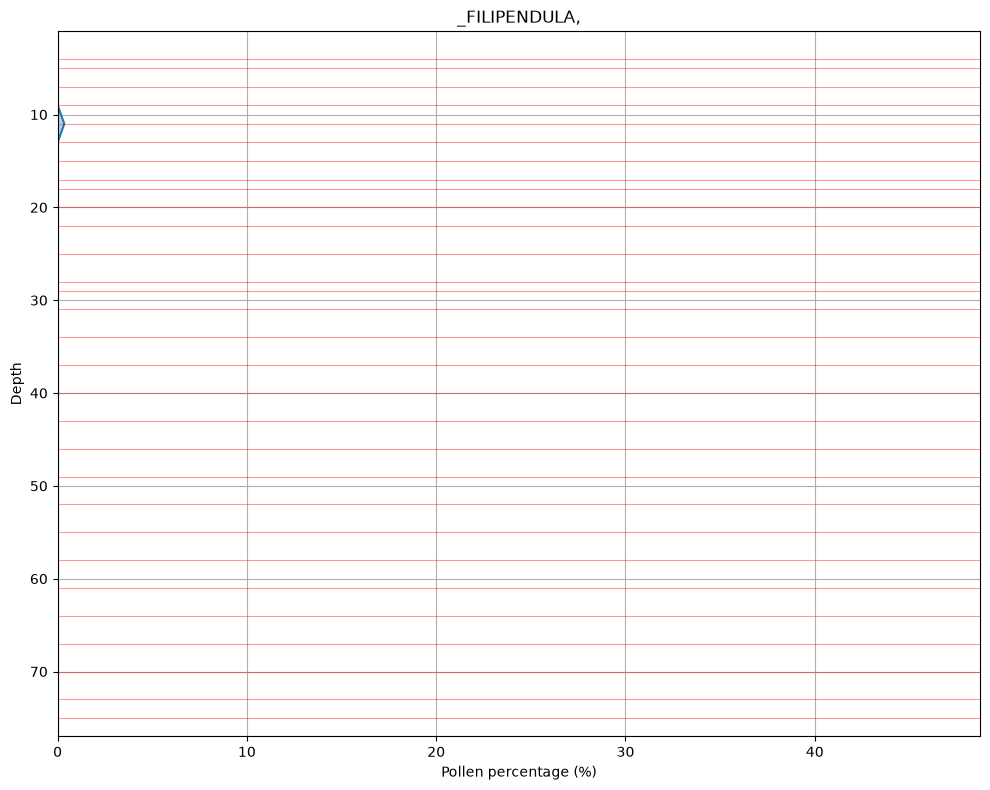

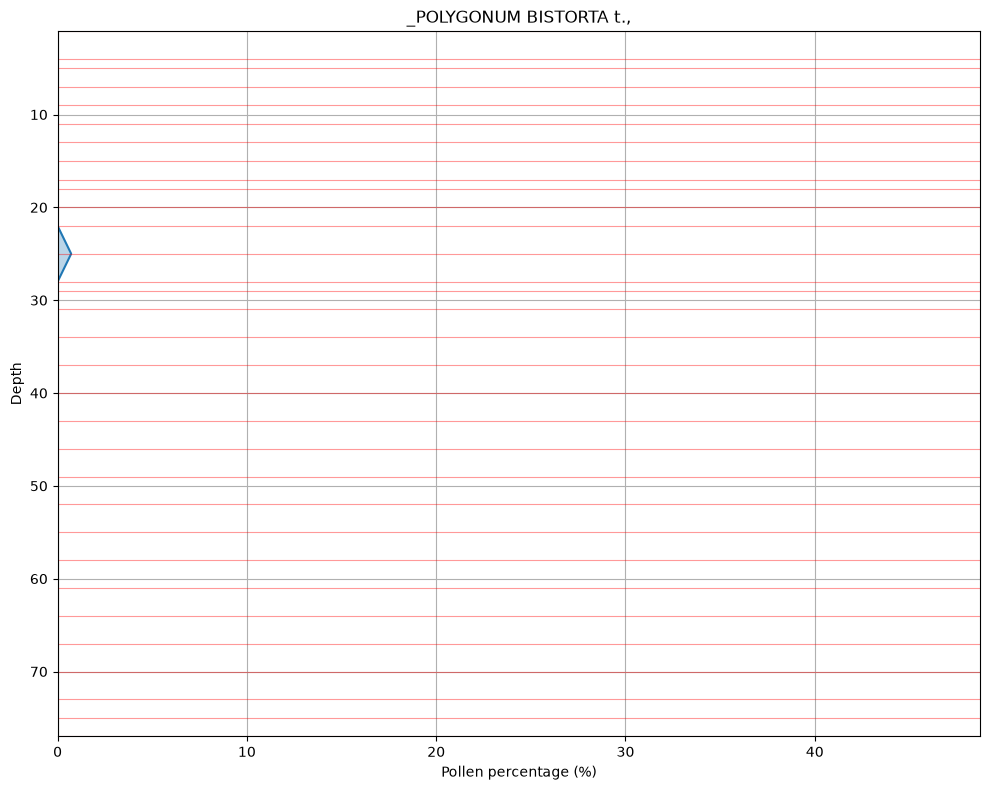

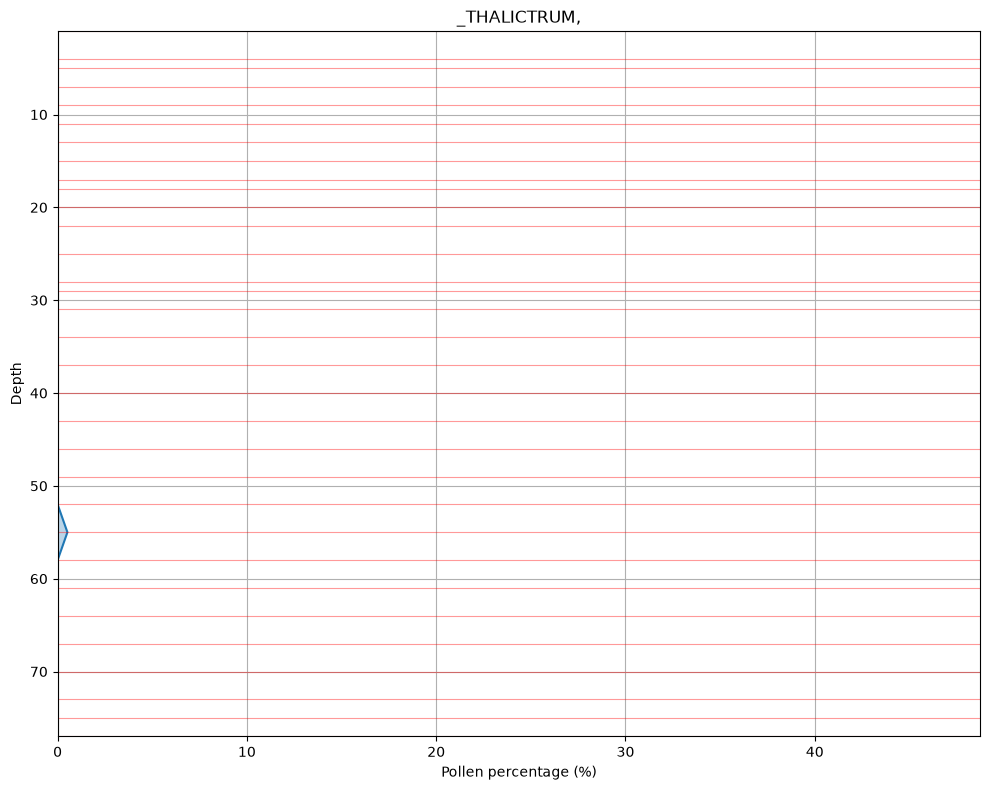

In [13]:
data_real_brut =  extract("./excel/Data_Thau_Lagoon_plant.xlsx")
data_real, depth_real = gen_data(data_real_brut)
percent_data_real = percentage(data_real, depth_real)

print(percent_data_real['_PINUS,'])

single_pollinic_diag(percent_data_real, depth_real, configuration)

# general_pollinic_diag(percent_data_real, depth_real, configuration)